# Dataset E-Commerce Terbesar Pakistan
### Aditya Wahyu Wijanarko — JCDS 0410 2024 — Kampus Yogyakarta

Dataset ini merekam setengah juta transaksi e-commerce di Pakistan dari Maret 2016 hingga Agustus 2018, mencakup detail produk, metode pembayaran, informasi pelanggan, dan status pesanan.

# 1. Latar Belakang & Rumusan Masalah

### 1.1. Pernyataan Masalah
Platform e-commerce Pakistan menghadapi tantangan nyata berupa tingginya angka pembatalan dan pengembalian pesanan (*refund*), yang berdampak langsung pada pendapatan dan loyalitas pelanggan. Analisis ini dirancang untuk menjawab dua pertanyaan besar: *faktor apa yang paling memengaruhi status akhir sebuah pesanan (selesai, dibatalkan, atau dikembalikan)?* dan *bisakah status tersebut diprediksi secara otomatis menggunakan Machine Learning?*

### 1.2. Tujuan Analisis
1. Menganalisis proporsi pesanan berdasarkan status (selesai, dibatalkan, dikembalikan) dan tren waktunya.
2. Mengukur dampak diskon terhadap nilai median pesanan (*Median Order Value*/MOV) dan kontribusi pendapatan.
3. Mengidentifikasi preferensi metode pembayaran pelanggan dan kaitannya dengan tingkat penyelesaian pesanan.
4. Memetakan performa kategori produk selama periode penjualan puncak (*peak season*) vs. keseluruhan.
5. Membangun model klasifikasi multikelas untuk memprediksi status pesanan (`complete` / `canceled` / `order_refunded`) berdasarkan fitur-fitur transaksi.
6. Mengidentifikasi fitur paling deterministik dari model terbaik sebagai landasan rekomendasi bisnis.

### 1.3. Pertanyaan Kunci
1. Seberapa besar proporsi pesanan yang selesai, dibatalkan, dan dikembalikan?
2. Bagaimana diskon memengaruhi nilai median pesanan dan total pendapatan?
3. Metode pembayaran mana yang paling populer, dan bagaimana pengaruhnya terhadap penyelesaian pesanan?
4. Kategori produk apa yang menghasilkan pendapatan dan volume penjualan tertinggi, baik secara keseluruhan maupun saat *peak season*?
5. Apakah model Machine Learning dapat memprediksi status pesanan secara akurat dari data transaksi?
6. Fitur transaksi apa yang paling berpengaruh terhadap status akhir pesanan?

### 1.4. Ruang Lingkup
- **Rentang Waktu:** Maret 2016 — Agustus 2018.
- **Metrik Utama:** Volume penjualan, pendapatan, diskon, metode pembayaran, dan status pesanan.
- **Segmentasi:** Berdasarkan kategori produk, metode pembayaran, dan status pesanan.
- **Pemodelan:** Klasifikasi multikelas dengan 4 algoritma (Logistic Regression, Naive Bayes, Random Forest, SVM) dalam 4 skenario *preprocessing* (*Ablation Study*).

### 1.5. Kriteria Keberhasilan
- Analisis deskriptif menghasilkan *actionable insights* terkait faktor pendorong pembatalan dan *refund* pesanan.
- Model Machine Learning mampu mengklasifikasikan status pesanan dengan akurasi bermakna dan F1-Score yang seimbang antar kelas.
- Rekomendasi bisnis yang diusulkan berpijak langsung pada temuan EDA dan hasil *feature importance* model terbaik.


---

# 2. Persiapan Data

Tahap ini mencakup seluruh proses dari pemuatan data mentah hingga dataset siap analisis: pemeriksaan duplikasi, penanganan nilai hilang, koreksi anomali, penyesuaian tipe data, penggantian nama kolom, dan identifikasi *outlier*.

Unduh dataset yang digunakan dalam proyek ini melalui tautan berikut:
[Data Asli](https://www.kaggle.com/datasets/sajkazmi/cleaned-pakistan-biggest-ecommerce-dataset?select=Pakistan+Biggest+Ecommerce+Analysis-Ready+Dataset.csv)

### 2.1. Daftar Kolom

Dataset memiliki 21 kolom dengan penjelasan masing-masing sebagai berikut.

Terdapat 21 kolom dalam dataset beserta penjelasan dan deskripsi uniknya.

| **No** | **Nama Kolom** | **Deskripsi Kolom** |
|:----:|:---------------:|:-------------------------------------------------------------:|
| 1    | item_id          | Pengenal unik untuk setiap item. |
| 2    | status           | Status pesanan (mis. complete, canceled, refunded). |
| 3    | created_at       | Tanggal pembuatan pesanan. |
| 4    | sku              | *Stock Keeping Unit*, pengenal unik setiap produk. |
| 5    | price            | Harga satuan item. |
| 6    | qty_ordered      | Jumlah item yang dipesan. |
| 7    | grand_total      | Total nilai pesanan. |
| 8    | increment_id     | Pengenal tambahan untuk pesanan. |
| 9    | category_name_1  | Kategori produk (mis. Women's Fashion, Beauty & Grooming). |
| 10   | sales_commission_code | Kode komisi penjualan. |
| 11   | discount_amount  | Jumlah diskon yang diterapkan pada pesanan. |
| 12   | payment_method   | Metode pembayaran yang digunakan (mis. cod). |
| 13   | Working Date     | Tanggal pesanan diproses. |
| 14   | BI Status        | Status Business Intelligence (mis. Gross, Net). |
| 15   | MV               | Metrik terkait pesanan (kemungkinan nilai pendapatan atau margin). |
| 16   | Year             | Tahun pesanan. |
| 17   | Month            | Bulan pesanan. |
| 18   | Customer Since   | Tanggal sejak pelanggan bergabung dengan platform. |
| 19   | M-Y              | Bulan-Tahun pesanan. |
| 20   | FY               | Tahun Fiskal. |
| 21   | Customer ID      | Pengenal unik pelanggan. |

### 2.2. Import Library

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import mplcursors
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats
from scipy.stats import shapiro, kstest, normaltest, chi2_contingency, mannwhitneyu, ttest_ind, anderson, kruskal, spearmanr, kendalltau
import unicodedata
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 500)

### 2.3. Muat Data

In [2]:
data = pd.read_csv('Pakistan Ecommerce Dataset.csv')
# Strip spasi dari nama kolom (beberapa kolom di CSV memiliki spasi tersembunyi)
data.columns = data.columns.str.strip()
data.sample(10)

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
129920,373795,complete,12/22/2016,RS_Sohan Halwa Tin,320.0,1,320.0,100251873,Soghaat,C-RWP-31924,...,cod,12/22/2016,Net,320,2016,12,2016-7,16-Dec,FY17,33
256047,527266,complete,7/4/2017,igeek_GoldenGSM-Smart-Watch-DZ09-2,1056.0,1,1056.0,100332357,Mobiles & Tablets,\N,...,cod,7/4/2017,Net,"1,056",2017,7,2017-7,17-Jul,FY18,53092
290951,566863,canceled,8/15/2017,BD_BIG DEAL_10,850.0,1,1000.0,100350417,Mobiles & Tablets,\N,...,Payaxis,8/15/2017,Gross,850,2017,8,2017-7,17-Aug,FY18,55208
422257,721136,complete,12/23/2017,WOFALK5A12AD1BC47CE,1875.0,1,0.0,100439981,Women's Fashion,\N,...,customercredit,12/23/2017,Net,"1,875",2017,12,2017-8,17-Dec,FY18,57853
60033,286203,complete,11/19/2016,RB_Mortein Killer Sale-bf,700.0,2,1540.0,100198161,Superstore,\N,...,Payaxis,11/19/2016,Net,"1,400",2016,11,2016-9,16-Nov,FY17,8687
357788,645296,canceled,11/19/2017,MATINF59BB98E9CB27B,8432.0,1,6745.6,100396623,Mobiles & Tablets,\N,...,Easypay,11/19/2017,Gross,"8,432",2017,11,2017-8,17-Nov,FY18,58608
20271,236342,canceled,8/31/2016,dawlance_70A,35800.0,1,35800.0,100164579,Appliances,C-LHC-104304,...,cod,8/31/2016,Gross,"35,800",2016,8,2016-7,16-Aug,FY17,163
180687,439091,complete,4/6/2017,KureshiC_122-kemei,1099.0,1,2659.0,100289163,Beauty & Grooming,\N,...,cod,4/6/2017,Net,"1,099",2017,4,2016-11,17-Apr,FY17,27026
476068,782119,canceled,3/14/2018,MATSAM5A7DBC5FB549C,17160.0,1,13929.2,100477941,Mobiles & Tablets,\N,...,Easypay,3/14/2018,Gross,"17,160",2018,3,2018-2,18-Mar,FY18,91674
45220,266783,complete,10/22/2016,RB_Household Bundle,999.0,1,999.0,100185537,Superstore,C-MUX-51359,...,cod,10/22/2016,Net,999,2016,10,2016-8,16-Oct,FY17,3205


2.3.1. Berikut adalah format tipe data awal dari dataset:

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584524 entries, 0 to 584523
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  int64  
 1   status                 584524 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584524 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  int64  
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  int64  
 8   category_name_1        584524 non-null  object 
 9   sales_commission_code  584524 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14  MV                     584524 non-nu

In [4]:
data.describe()

,item_id,price,qty_ordered,grand_total,increment_id,discount_amount,Year,Month,Customer ID
count,584524.000000,5.845240e+05,584524.000000,5.845240e+05,5.845240e+05,584524.000000,584524.000000,584524.000000,584524.000000
mean,565667.074218,6.348748e+03,1.296388,8.530619e+03,1.003570e+08,499.492775,2017.044115,7.167654,45791.264422
std,200121.173648,1.494927e+04,3.996061,6.132081e+04,1.152815e+05,1506.943046,0.707355,3.486305,34415.075674
min,211131.000000,0.000000e+00,1.000000,-1.594000e+03,1.000013e+08,-599.500000,2016.000000,1.000000,1.000000
25%,395000.750000,3.600000e+02,1.000000,9.450000e+02,1.002646e+08,0.000000,2017.000000,4.000000,13516.000000
50%,568424.500000,8.990000e+02,1.000000,1.960400e+03,1.003512e+08,0.000000,2017.000000,7.000000,42856.000000
75%,739106.250000,4.070000e+03,1.000000,6.999000e+03,1.004502e+08,160.500000,2018.000000,11.000000,73538.000000
max,905208.000000,1.012626e+06,1000.000000,1.788800e+07,1.005624e+08,90300.000000,2018.000000,12.000000,115326.000000


### 2.4. Pemeriksaan Duplikasi

Memeriksa apakah terdapat baris duplikat dalam dataset yang dapat memengaruhi akurasi analisis.

In [5]:
data.duplicated().sum()

0

In [6]:
data[data.duplicated(keep=False)]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID


### 2.5. Pemeriksaan Nilai Hilang (*Missing Values*)

Mengidentifikasi kolom yang memiliki nilai kosong dan memutuskan penanganannya.

In [7]:
print('Missing values status:', data.isnull().values.any())
missing_values = pd.DataFrame(data.isnull().sum(), columns=['Total Null Values'])
missing_values['Percentage'] = (missing_values['Total Null Values'] / data.shape[0]) * 100
missing_values.sort_values(by='Percentage', ascending=False).reset_index()

Missing values status: False


,index,Total Null Values,Percentage
0,item_id,0,0.0
1,payment_method,0,0.0
2,FY,0,0.0
3,M-Y,0,0.0
4,Customer Since,0,0.0
5,Month,0,0.0
6,Year,0,0.0
7,MV,0,0.0
8,BI Status,0,0.0
9,Working Date,0,0.0


### 2.6. Pemeriksaan Jumlah dan Nilai Unik

Meninjau jumlah nilai unik setiap kolom untuk memahami kardinalitas data.

In [8]:
# Periksa jumlah unik dan nilai tiap kolom
unique_info = pd.DataFrame({
    'Columns': data.columns,
    'Unique Count': [data[col].nunique() for col in data.columns],
    'Unique Values': [data[col].unique()[:100].tolist() for col in data.columns]
})
unique_info

,Columns,Unique Count,Unique Values
0,item_id,584524,"[211131, 211133, 211134, 211135, 211136, 211137, 211138, 211139, 211140, 211141, 211142, 211143, 211144, 211145, 211146, 211147, 211149, 211150, 211151, 211152, 211153, 211154, 211155, 211156, 211157, 211158, 211160, 211162, 211163, 211164, 211166, 211168, 211169, 211170, 211171, 211172, 211173, 211174, 211175, 211176, 211177, 211179, 211180, 211182, 211184, 211185, 211186, 211187, 211188, 211189, 211190, 211191, 211192, 211193, 211194, 211196, 211197, 211198, 211199, 211200, 211202, 211201, 211203, 211204, 211205, 211206, 211207, 211208, 211209, 211211, 211212, 211213, 211214, 211215, 211217, 211218, 211219, 211220, 211221, 211222, 211223, 211225, 211224, 211226, 211227, 211228, 211229, 211230, 211231, 211232, 211233, 211234, 211235, 211236, 211237, 211238, 211239, 211240, 211241, 211242]"
1,status,16,"[complete, canceled, order_refunded, received, refund, closed, fraud, holded, exchange, pending_paypal, paid, \N, cod, pending, processing, payment_review]"
2,created_at,789,"[7/1/2016, 7/2/2016, 7/3/2016, 7/4/2016, 7/5/2016, 7/6/2016, 7/7/2016, 7/8/2016, 7/9/2016, 7/10/2016, 7/11/2016, 7/12/2016, 7/13/2016, 7/14/2016, 7/15/2016, 7/16/2016, 7/17/2016, 7/18/2016, 7/19/2016, 7/20/2016, 7/21/2016, 7/22/2016, 7/23/2016, 7/24/2016, 7/25/2016, 7/26/2016, 7/27/2016, 7/28/2016, 7/29/2016, 7/30/2016, 7/31/2016, 8/1/2016, 8/2/2016, 8/3/2016, 8/4/2016, 8/5/2016, 8/6/2016, 8/7/2016, 8/8/2016, 8/9/2016, 8/10/2016, 8/11/2016, 8/12/2016, 8/13/2016, 8/14/2016, 8/15/2016, 8/16/2016, 8/17/2016, 8/18/2016, 8/19/2016, 8/20/2016, 8/21/2016, 8/22/2016, 8/23/2016, 8/24/2016, 8/25/2016, 8/26/2016, 8/27/2016, 8/28/2016, 8/29/2016, 8/30/2016, 8/31/2016, 9/1/2016, 9/2/2016, 9/3/2016, 9/4/2016, 9/5/2016, 9/6/2016, 9/7/2016, 9/8/2016, 9/9/2016, 9/10/2016, 9/11/2016, 9/12/2016, 9/13/2016, 9/14/2016, 9/15/2016, 9/16/2016, 9/17/2016, 9/18/2016, 9/19/2016, 9/20/2016, 9/21/2016, 9/22/2016, 9/23/2016, 9/24/2016, 9/25/2016, 9/26/2016, 9/27/2016, 9/28/2016, 9/29/2016, 9/30/2016, 10/1/2016, 10/2/2016, 10/3/2016, 10/4/2016, 10/5/2016, 10/6/2016, 10/7/2016, 10/8/2016]"
3,sku,84889,"[kreations_YI 06-L, kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Body Spray Free, Ego_UP0017-999-MR0, kcc_krone deal, BK7010400AG, UK_Namkino All In One 200 Gms, UK_Namkino Mix Nimco 400 Gms, Apple iPhone 6S 64GB, GFC_Pedestal Myga Cross Base (Special Guard) 24"", BK1070200PL, BK1130200CF, kcc_Sultanat, kcc_glamour deal, Assetmen_MD-346-M, cr_DATES WITH CASHEW-400 GM, UK_Gift Box Mix Dry Fruit Sweets 500 Gms, itter_AB 1199, RL_B005, bed&rest_S7, L&L_LLHLE8224S, J&J_JJR-4, J&J_JJR-20, D Lend a Helping Hand, Mochika_M0001112-12, Mochika_M0001112-8, SKMT_Blood Test, SKMT_Medicine, sputnik_701/5-11, Ctees-Black Zip- Up Hoodie-XL, Samsung Galaxy J5, Veet_4, RS_Gulab jaman Tin, cr_PEANUT SALTY-200 GM, Oriflame_21557, JBS_TAT-128, Ajmery_BRR-590-M, HOS_GUCFW75, Lexon_LL116B-Blue, kcc_Fantasy Perfumed Talcum Powder-200gm, 2Zee_SC6, Q MOBILE Noir X20, rehaab_RJ160047, Farah_3-B, RS_Sohan Halwa Tin, UK_Soan Papdi Original 250 Gms, UK_Gift Box Soghaat 500 Gms, RS_Double Delight, Al Muhafiz Sohan Halwa Almond, UK_Gift Box Baklawa 500 Gms, sputnik_2146/6-8, kkc_Kingtox 450ml Classic Green All Insect Killer Spray, Al Muhafiz Sohan Halwa Walnut, RS_Honey Dry Fruit Halwa, itter_AB 1214, Eco Star_40U557, Orient_OR-6057 GX LGFD LV, HOS_JPGCW100, kkc_Jasmine King Air Freshener, asimjofaeanew_5A, ajmery_F9-981, hijabh_JILBAB-C (1)-52x, noritake_NTM163M, RS_Habshi Halwa Tin, sentiments_WRK1612, bata_comfit-8613714-43-9, UK_Namkino Mix Nimco 8 Pcs Gift Pack, Inoxy_Inoxy Hair Miracle Elixir, RS_Chum Chum Tin, Dany_AUK-650 , urban_ PT004-L, jackpot_JP-7999, UK_Gift Box Pistachio Delight 500 Gms, test_tcsconnect, sst_Lyquin-Regular fit-Large, Fcafe_11777-L, LC_359547105042, LC_3349668508587, RS_pheni Desi Ghee 1 kg , UK_Gulab Jamun Tin Pack 500 Gms, UK_Chum Chum Tin Pack 500 Gms, UK_Namkino Mix Nimco 200 Gms, sentiments_Ferrero Rocher Gift Box, EGO_E02377-SML-BG

### 2.7. Pengaturan Indeks Baru

Kolom `item_id` ditetapkan sebagai indeks karena memiliki nilai unik sebanyak jumlah baris, sehingga lebih tepat difungsikan sebagai pengenal baris daripada kolom analisis.

In [9]:
# Tetapkan 'item_id' sebagai indeks jika kolom tersebut masih ada
if 'item_id' in data.columns:
    data = data.set_index('item_id')
print(data.shape)
print('Indeks saat ini:', data.index.name)

(584524, 20)
Indeks saat ini: item_id


In [10]:
data.sample(10)

,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
item_id,,,,,,,,,,,,,,,,,,,,
469460,canceled,5/17/2017,xiaomi_mi-c3-32gb-Grey,14500.0,1,14500.00,100303963,Mobiles & Tablets,\N,0.00,Payaxis,5/17/2017,Gross,"14,500",2017,5,2017-5,17-May,FY17,44328
637384,canceled,11/18/2017,MATSAM59D74470AD085,94792.0,1,85792.00,100392158,Mobiles & Tablets,\N,9000.00,easypay_voucher,11/18/2017,Gross,"94,792",2017,11,2017-11,17-Nov,FY18,66109
816961,canceled,3/29/2018,OTHPCB5ABB207785584,2000.0,1,2000.00,100508094,Others,\N,0.00,Easypay,3/29/2018,Gross,"2,000",2018,3,2018-3,18-Mar,FY18,103226
268027,complete,10/25/2016,RS_Plain Rusk,55.0,1,55.00,100186351,Soghaat,R-LHW-104132,0.00,cod,10/25/2016,Net,55,2016,10,2016-8,16-Oct,FY17,2974
590819,order_refunded,10/9/2017,APPMOU59ACAC0C1784D,3008.0,1,0.00,100364121,Appliances,GRS - 3042806-6,0.00,customercredit,10/9/2017,Valid,"3,008",2017,10,2017-5,17-Oct,FY18,43229
428733,canceled,3/23/2017,HAS_NIA-X3-White,1539.0,1,1308.15,100283338,Mobiles & Tablets,\N,230.85,Easypay,3/23/2017,Gross,"1,539",2017,3,2017-3,17-Mar,FY17,38726
586211,canceled,9/30/2017,ENTSAM59C11BE16502E,34999.0,1,34999.00,100361332,Entertainment,\N,0.00,Easypay,9/30/2017,Gross,"34,999",2017,9,2017-9,17-Sep,FY18,61906
345294,complete,11/26/2016,KureshiC_060-pols,599.0,1,599.00,100235381,Men's Fashion,\N,0.00,cod,11/26/2016,Net,599,2016,11,2016-11,16-Nov,FY17,25246
872587,received,6/17/2018,HASONC59AC64DFADA78,625.0,1,775.00,100542765,Health & Sports,\N,0.00,cod,6/17/2018,Valid,625,2018,6,2018-6,18-Jun,FY18,111142


**Alasan:** Kolom `item_id` memiliki nilai unik sebanyak jumlah baris, sehingga lebih tepat difungsikan sebagai pengenal baris (indeks) daripada kolom analisis.

### 2.8. Penghapusan Kolom

Beberapa kolom yang kurang relevan untuk analisis dan pemodelan dihapus untuk menyederhanakan dataset.

In [11]:
# Hapus kolom yang kurang relevan
cols_to_drop = ['sku', 'increment_id', 'sales_commission_code', 'Working Date',
                'BI Status', 'MV', 'M-Y', 'FY', 'Customer Since']
# errors='ignore' memastikan tidak crash jika kolom sudah tidak ada
data = data.drop(columns=cols_to_drop, errors='ignore')
print('Kolom tersisa:', data.columns.tolist())

Kolom tersisa: ['status', 'created_at', 'price', 'qty_ordered', 'grand_total', 'category_name_1', 'discount_amount', 'payment_method', 'Year', 'Month', 'Customer ID']


| **Alasan** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| `sku` | Kode unik produk yang terlalu granular dan tidak relevan untuk analisis perilaku pelanggan atau pemodelan. |
| `increment_id` | Pengenal pesanan redundan karena `item_id` sudah digunakan sebagai indeks. |
| `sales_commission_code` | Mayoritas nilainya kosong (`\N`), tidak memberikan informasi yang berguna. |
| `Working Date` | Merupakan duplikasi dari `created_at` dengan format berbeda. |
| `BI Status` | Merupakan klasifikasi BI internal yang tidak relevan untuk analisis perilaku pelanggan. |
| `MV` | Kolom ambigu dengan nilai campuran string dan angka, tidak konsisten untuk dianalisis. |
| `M-Y` | Dapat diturunkan dari kolom `Year` dan `Month` yang sudah ada. |
| `FY` | Dapat diturunkan dari `Year`, sehingga tidak perlu kolom terpisah. |
| `Customer Since` | Format tidak konsisten dan dapat diturunkan dari `created_at`. |

### 2.9. Pemeriksaan Anomali

Mengidentifikasi dan memperbaiki inkonsistensi dalam data: nilai status yang duplikatif, tipe data yang tidak sesuai, dan nama kolom yang perlu distandarkan.

2.9.1. Penggabungan Kategori Status yang Sama

In [12]:
# Gabungkan 'order_refunded' dan 'refund' menjadi satu status
data['status'] = data['status'].replace('refund', 'order_refunded')
print('Nilai unik status:', sorted(data['status'].unique()))

Nilai unik status: ['\\N', 'canceled', 'closed', 'cod', 'complete', 'exchange', 'fraud', 'holded', 'order_refunded', 'paid', 'payment_review', 'pending', 'pending_paypal', 'processing', 'received']


---

2.9.2. Penyesuaian Tipe Data

In [13]:
# Konversi tipe data (gunakan nama kolom ASLI, rename dilakukan setelahnya)
data['created_at'] = pd.to_datetime(data['created_at'])
data['Customer ID'] = data['Customer ID'].astype(str)
print(data.dtypes)

status                     object
created_at         datetime64[ns]
price                     float64
qty_ordered                 int64
grand_total               float64
category_name_1            object
discount_amount           float64
payment_method             object
Year                        int64
Month                       int64
Customer ID                object
dtype: object


---

2.9.3. Penggantian Nama Kolom

In [14]:
# Kamus nama kolom lama ke nama kolom baru
rename_dict = {
    'created_at':       'Tanggal_Dibuat',
    'price':            'Harga',
    'qty_ordered':      'Jumlah_Dipesan',
    'grand_total':      'Total_Pesanan',
    'category_name_1':  'Kategori_Produk',
    'discount_amount':  'Jumlah_Diskon',
    'payment_method':   'Metode_Pembayaran',
    'Year':             'Tahun',
    'Month':            'Bulan',
    'Customer ID':      'ID_Pelanggan'
}

# Terapkan penggantian nama (hanya kolom yang ada, lainnya dilewati)
data = data.rename(columns={k: v for k, v in rename_dict.items() if k in data.columns})

# Tampilkan kolom hasil
print('Kolom setelah rename:', data.columns.tolist())

Kolom setelah rename: ['status', 'Tanggal_Dibuat', 'Harga', 'Jumlah_Dipesan', 'Total_Pesanan', 'Kategori_Produk', 'Jumlah_Diskon', 'Metode_Pembayaran', 'Tahun', 'Bulan', 'ID_Pelanggan']


In [15]:
data.sample(10)

,status,Tanggal_Dibuat,Harga,Jumlah_Dipesan,Total_Pesanan,Kategori_Produk,Jumlah_Diskon,Metode_Pembayaran,Tahun,Bulan,ID_Pelanggan
item_id,,,,,,,,,,,
704162,canceled,2017-11-29,734.0,1,884.0,Computing,0.0,Easypay,2017,11,81842
834257,canceled,2018-05-03,900.0,1,12489.0,Women's Fashion,0.0,easypay_voucher,2018,5,59158
832480,received,2018-04-29,3990.0,1,4589.0,Mobiles & Tablets,0.0,cod,2018,4,105967
522832,complete,2017-06-22,340.0,1,340.0,Soghaat,0.0,mcblite,2017,6,7122
518660,complete,2017-06-18,899.0,1,1049.0,Men's Fashion,0.0,cod,2017,6,51650
556274,complete,2017-08-10,360.0,1,1520.8,Superstore,72.0,Payaxis,2017,8,44830
568391,canceled,2017-08-17,799.0,3,7251.0,Kids & Baby,0.0,Payaxis,2017,8,56449
289757,complete,2016-11-19,388.0,1,388.0,Soghaat,0.0,cod,2016,11,15384
660066,complete,2017-11-21,5200.0,1,4500.0,Appliances,700.0,easypay_voucher,2017,11,18445


**Alasan penggantian nama kolom:**
- *Kejelasan:* Nama kolom yang lebih deskriptif memudahkan pembacaan kode.
- *Konsistensi:* Menggunakan format yang seragam di seluruh dataset.
- *Kemudahan Akses:* Nama kolom yang intuitif mempercepat proses eksplorasi dan pemodelan.

### 2.10. Pemeriksaan *Outlier*

Mengidentifikasi *outlier* pada kolom numerik menggunakan *box plot* dan perhitungan batas IQR.

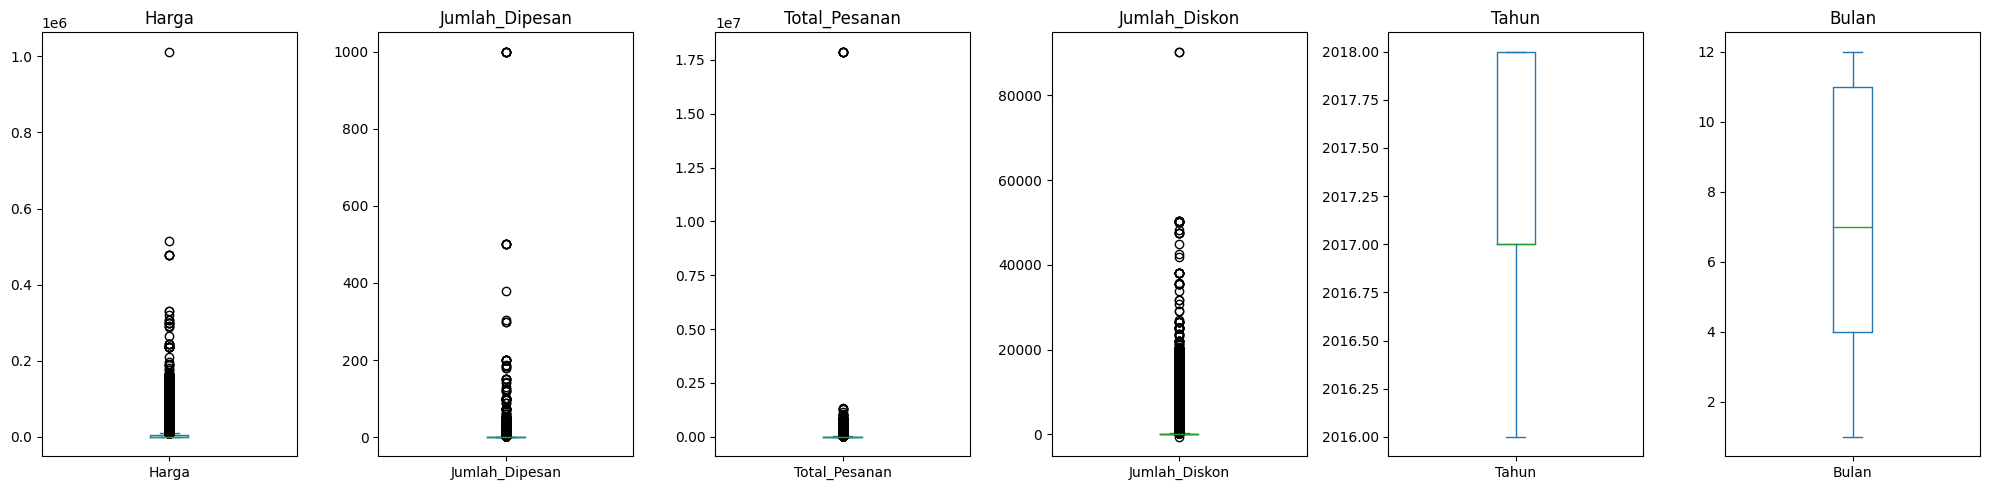

In [16]:
# Box plot untuk mengidentifikasi outlier
numerical_cols = data.select_dtypes(include='number').columns.tolist()

# Visualisasi box plot untuk outlier
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(20, 5))
for ax, col in zip(axes, numerical_cols):
    data[col].dropna().plot(kind='box', ax=ax, title=col)
plt.tight_layout()
plt.show()

In [17]:
# Fungsi menghitung jumlah outlier per kolom menggunakan metode IQR
def hitung_outlier(df):
    result = []
    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        result.append({'Kolom': col, 'Jumlah Outlier': n_outlier})
    return pd.DataFrame(result)

# Hitung outlier untuk setiap kolom numerik
outlier_df = hitung_outlier(data)

# Tampilkan hasilnya
outlier_df

,Kolom,Jumlah Outlier
0,Harga,105687
1,Jumlah_Dipesan,79310
2,Total_Pesanan,77090
3,Jumlah_Diskon,108986
4,Tahun,0
5,Bulan,0


**Temuan Outlier:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Distribusi Nilai Pesanan | Kolom `Harga`, `Total_Pesanan`, dan `Jumlah_Diskon` memiliki distribusi yang sangat miring ke kanan (*right-skewed*), mencerminkan adanya produk bernilai sangat tinggi (mis. elektronik dan *gadget*) yang menjadi *outlier* atas. |
| Penanganan Outlier | *Outlier* tidak dihapus karena merepresentasikan transaksi nyata. Penggunaan median (bukan mean) dan uji statistik non-parametrik (*Mann-Whitney U*) dipilih justru untuk mengantisipasi distorsi akibat nilai ekstrem ini. |
| Dampak pada Pemodelan | Pada tahap Machine Learning, data akan distandarisasi menggunakan `StandardScaler` untuk meminimalkan dampak *outlier* terhadap algoritma berbasis skala seperti Logistic Regression dan SVM. |

---

**Ringkasan Persiapan Data:**
Dataset awal berisi 584.524 baris dan 21 kolom. Setelah pembersihan, 9 kolom yang redundan atau ambigu dihapus, status *refund* yang duplikatif digabung, tipe data disesuaikan, dan kolom-kolom diubah namanya agar lebih mudah dibaca. Dataset yang tersisa siap untuk tahap analisis eksplorasi dan pemodelan.

# 3. Analisis Data

Seksi ini menjadi fondasi analitik sebelum masuk ke pemodelan. Seluruh variabel yang digunakan sebagai fitur pada model Machine Learning di Seksi 4—6 — yakni `Metode_Pembayaran`, `Total_Pesanan`, `Harga`, `Jumlah_Dipesan`, dan `Kategori_Produk` — dieksplorasi secara mendalam di sini untuk memahami distribusi, pola, dan korelasinya dengan status pesanan.

### 3.1. Proporsi Pesanan Berdasarkan Diskon

Langkah pertama adalah memahami seberapa umum penggunaan diskon dalam dataset. Proporsi ini penting karena diskon berpotensi memengaruhi status akhir pesanan.

In [18]:
# Hitung jumlah pesanan yang mendapatkan diskon
jumlah_pesanan_diskon = data[data['Jumlah_Diskon'] > 0].shape[0]
jumlah_pesanan_diskon

208215

In [19]:
# Hitung total seluruh pesanan
total_pesanan = data.shape[0]

# Hitung rasio pesanan berDiskon terhadap total pesanan
rasio_diskon = jumlah_pesanan_diskon / total_pesanan
rasio_diskon

0.3562129185456885

**Ringkasan 3.1:**
Dari total seluruh pesanan, sekitar **35,62%** mendapatkan diskon. Angka ini menunjukkan bahwa lebih dari sepertiga transaksi melibatkan insentif harga — cukup signifikan untuk ditelisik lebih lanjut pengaruhnya terhadap nilai pesanan dan kecenderungan pembatalan.

---

### 3.2. Analisis Pesanan Berdasarkan Diskon vs. Tanpa Diskon

Membandingkan karakteristik pesanan yang mendapatkan diskon dengan yang tidak — mencakup nilai median pesanan (MOV) dan kontribusi pendapatan masing-masing kelompok.

In [20]:
# Pisahkan data pesanan berDiskon dan tidak berDiskon
pesanan_diskon = data[data['Jumlah_Diskon'] > 0]
pesanan_tanpa_diskon = data[data['Jumlah_Diskon'] == 0]

In [21]:
pesanan_diskon

,status,Tanggal_Dibuat,Harga,Jumlah_Dipesan,Total_Pesanan,Kategori_Produk,Jumlah_Diskon,Metode_Pembayaran,Tahun,Bulan,ID_Pelanggan
item_id,,,,,,,,,,,
211135,complete,2016-07-01,360.0,1,60.00,Beauty & Grooming,300.00,cod,2016,7,4
211138,complete,2016-07-01,360.0,1,60.00,Beauty & Grooming,300.00,cod,2016,7,7
211170,order_refunded,2016-07-01,165.0,1,300.00,Beauty & Grooming,82.50,cod,2016,7,21
211171,order_refunded,2016-07-01,435.0,1,300.00,Soghaat,217.50,cod,2016,7,21
211175,complete,2016-07-01,90.0,1,740.00,Soghaat,19.15,cod,2016,7,22
...,...,...,...,...,...,...,...,...,...,...,...
905091,order_refunded,2018-08-27,145.0,1,326.01,Mobiles & Tablets,299.99,cod,2018,8,69407
905092,order_refunded,2018-08-27,275.0,1,326.01,Men's Fashion,299.99,cod,2018,8,69407
905093,order_refunded,2018-08-27,189.0,1,326.01,Health & Sports,299.99,cod,2018,8,69407


In [22]:
pesanan_tanpa_diskon

,status,Tanggal_Dibuat,Harga,Jumlah_Dipesan,Total_Pesanan,Kategori_Produk,Jumlah_Diskon,Metode_Pembayaran,Tahun,Bulan,ID_Pelanggan
item_id,,,,,,,,,,,
211131,complete,2016-07-01,1950.0,1,1950.0,Women's Fashion,0.0,cod,2016,7,1
211133,canceled,2016-07-01,240.0,1,240.0,Beauty & Grooming,0.0,cod,2016,7,2
211134,canceled,2016-07-01,2450.0,1,2450.0,Women's Fashion,0.0,cod,2016,7,3
211136,order_refunded,2016-07-01,555.0,2,1110.0,Soghaat,0.0,cod,2016,7,5
211137,canceled,2016-07-01,80.0,1,80.0,Soghaat,0.0,cod,2016,7,6
...,...,...,...,...,...,...,...,...,...,...,...
905204,cod,2018-08-28,699.0,1,849.0,Women's Fashion,0.0,cod,2018,8,115320
905205,processing,2018-08-28,35599.0,1,35899.0,Mobiles & Tablets,0.0,bankalfalah,2018,8,115326
905206,processing,2018-08-28,129999.0,2,652178.0,Mobiles & Tablets,0.0,bankalfalah,2018,8,113474


---

3.2.1. MOV (*Median Order Value*)

Mengingat distribusi nilai pesanan yang condong ke kanan (*right-skewed*) seperti terlihat pada *box plot*, median digunakan sebagai representasi nilai tipikal pesanan — lebih tahan terhadap distorsi dari transaksi bernilai ekstrem dibandingkan mean.

---

3.2.2. MOV Pesanan Berdasarkan Diskon vs. Tanpa Diskon

In [23]:
# Hitung Median Order Value (MOV)
MOV_diskon = pesanan_diskon['Total_Pesanan'].median()
MOV_tanpa_diskon = pesanan_tanpa_diskon['Total_Pesanan'].median()
print(f'MOV Pesanan Berdasarkan Diskon: ₹{MOV_diskon:,.2f}')
print(f'MOV Pesanan Tanpa Diskon: ₹{MOV_tanpa_diskon:,.2f}')

MOV Pesanan Berdasarkan Diskon: ₹3,063.64
MOV Pesanan Tanpa Diskon: ₹1,590.00


In [24]:
print(f"MOV Pesanan Berdasarkan Diskon: ₹ {MOV_diskon:,.2f}")
print(f"MOV Pesanan Tanpa Diskon: ₹ {MOV_tanpa_diskon:,.2f}")

MOV Pesanan Berdasarkan Diskon: ₹ 3,063.64
MOV Pesanan Tanpa Diskon: ₹ 1,590.00


**Temuan 3.2.2:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| MOV Lebih Tinggi pada Pesanan Berdasarkan Diskon | Pesanan yang mendapatkan diskon memiliki nilai median yang jauh lebih tinggi — mendekati dua kali lipat dibandingkan pesanan tanpa diskon. Ini mengindikasikan bahwa diskon cenderung diberikan pada produk atau keranjang belanja bernilai besar. |
| Strategi Diskon | Temuan ini menunjukkan bahwa diskon efektif mendorong pelanggan untuk membeli produk yang lebih mahal, yang berpotensi meningkatkan pendapatan per transaksi. |

---

3.2.3. Kontribusi Pendapatan: Pesanan Berdasarkan Diskon vs. Tanpa Diskon

In [25]:
# Hitung kontribusi pendapatan
pendapatan_diskon = pesanan_diskon['Total_Pesanan'].sum()
pendapatan_tanpa_diskon = pesanan_tanpa_diskon['Total_Pesanan'].sum()
total_pendapatan = pendapatan_diskon + pendapatan_tanpa_diskon
print(f'Pendapatan dari Pesanan Berdasarkan Diskon: ₹{pendapatan_diskon:,.2f}')
print(f'Pendapatan dari Pesanan Tanpa Diskon: ₹{pendapatan_tanpa_diskon:,.2f}')
print(f'Total Pendapatan: ₹{total_pendapatan:,.2f}')

Pendapatan dari Pesanan Berdasarkan Diskon: ₹1,951,345,687.64
Pendapatan dari Pesanan Tanpa Diskon: ₹3,034,995,052.43
Total Pendapatan: ₹4,986,340,740.07


In [26]:
print(f"Pendapatan Pesanan Berdasarkan Diskon: ₹ {pendapatan_diskon:,.2f}")
print(f"Pendapatan Pesanan Tanpa Diskon: ₹ {pendapatan_tanpa_diskon:,.2f}")

Pendapatan Pesanan Berdasarkan Diskon: ₹ 1,951,345,687.64
Pendapatan Pesanan Tanpa Diskon: ₹ 3,034,995,052.43


**Temuan 3.2.3:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Kontribusi Pendapatan | Meskipun MOV pesanan berDiskon lebih tinggi, pesanan tanpa diskon secara agregat menghasilkan total pendapatan yang lebih besar karena volume transaksinya yang lebih banyak (sekitar 64% dari total pesanan). |
| Efektivitas Diskon | Diskon efektif meningkatkan nilai per transaksi, namun bukan sumber pendapatan terbesar secara absolut. Strategi diskon yang tepat sasaran — bukan masif — lebih berpotensi mengoptimalkan profitabilitas. |

---

3.2.4. Visualisasi Data

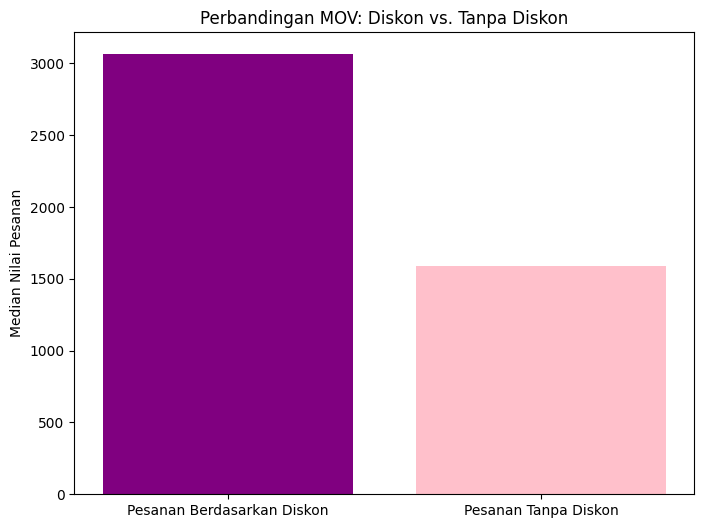

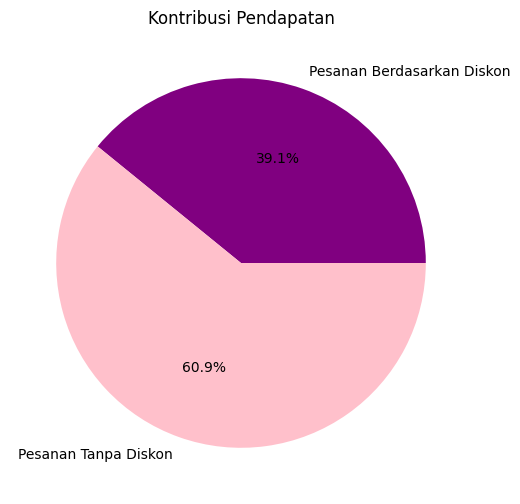

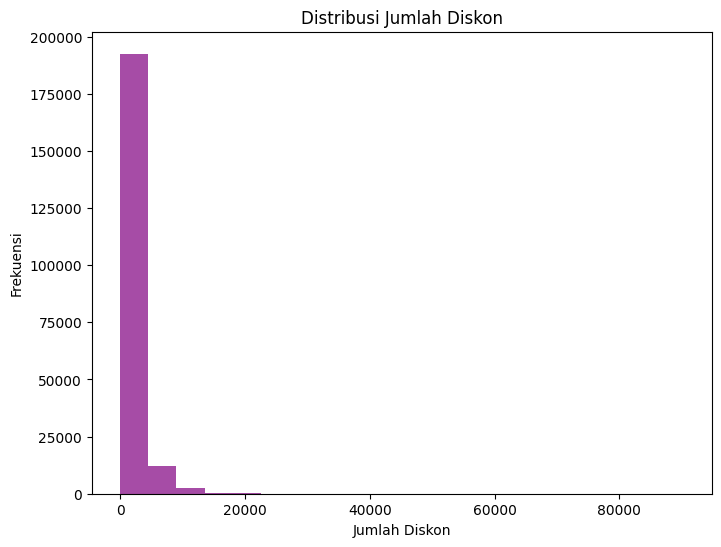

In [27]:
# Bar Chart for MOV
plt.figure(figsize=(8, 6))
plt.bar(['Pesanan Berdasarkan Diskon', 'Pesanan Tanpa Diskon'], [MOV_diskon, MOV_tanpa_diskon], color=['purple', 'pink'])
plt.title('Perbandingan MOV: Diskon vs. Tanpa Diskon')
plt.ylabel('Median Nilai Pesanan')
plt.show()

# Pie Chart for Revenue Contribution
plt.figure(figsize=(8, 6))
plt.pie([pendapatan_diskon, pendapatan_tanpa_diskon], labels=['Pesanan Berdasarkan Diskon', 'Pesanan Tanpa Diskon'], autopct='%1.1f%%', colors=['purple', 'pink'])
plt.title('Kontribusi Pendapatan')
plt.show()

# Histogram for Discount Levels
plt.figure(figsize=(8, 6))
plt.hist(pesanan_diskon['Jumlah_Diskon'], bins=20, color='purple', alpha=0.7)
plt.title('Distribusi Jumlah Diskon')
plt.xlabel('Jumlah Diskon')
plt.ylabel('Frekuensi')
plt.show()

---

### 3.3. Distribusi Besaran Diskon

Mendalami distribusi nilai diskon yang diberikan: seberapa besar diskon yang umum, apakah ada konsentrasi pada kisaran tertentu, dan seberapa ekstrem nilai tertingginya.

3.3.1. Statistik Deskriptif Distribusi Diskon

In [28]:
# Hitung statistik deskriptif besaran diskon
distribusi_diskon = pesanan_diskon['Jumlah_Diskon'].describe().round(2)

# Ubah tipe data menjadi object agar bisa diformat sebagai string
distribusi_diskon = distribusi_diskon.astype(object)

# Baris 'count' cukup ditampilkan sebagai integer
distribusi_diskon['count'] = int(distribusi_diskon['count'])

# Format baris lainnya dengan simbol Rupee dan 2 desimal
distribusi_diskon.iloc[1:] = distribusi_diskon.iloc[1:].apply(lambda x: f'₹ {x:,.2f}')

print(distribusi_diskon)

count         208215
mean      ₹ 1,402.23
std       ₹ 2,260.36
min           ₹ 0.08
25%         ₹ 123.00
50%         ₹ 480.00
75%       ₹ 1,995.00
max      ₹ 90,300.00
Name: Jumlah_Diskon, dtype: object


**Temuan 3.3:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Distribusi Tidak Simetris | Median diskon (₹480) jauh lebih rendah dari rata-rata (₹1.402), mengindikasikan distribusi yang condong ke kanan: sebagian besar diskon bernilai kecil, namun ada sejumlah kecil diskon yang sangat besar. |
| Diskon Ekstrem | Nilai diskon tertinggi mencapai ₹90.300 — kemungkinan terkait dengan promosi khusus pada produk elektronik atau *flash sale* berskala besar. |
| Implikasi Strategi | Diskon besar kemungkinan diterapkan secara selektif pada produk atau segmen tertentu, bukan secara merata. Pemahaman ini dapat membantu tim pemasaran merancang program diskon yang lebih efisien dan terarah. |

---

### 3.4. Analisis Metode Pembayaran

Metode pembayaran adalah salah satu fitur paling deterministik dalam model Machine Learning (akan terbukti di Seksi 6). Di sini, kita melihat distribusi penggunaannya — membandingkan preferensi antara pelanggan yang mendapatkan diskon dan yang tidak.

3.4.1. Distribusi Metode Pembayaran: Pesanan Berdasarkan Diskon vs. Tanpa Diskon

In [29]:
# Distribusi metode pembayaran
distribusi_mp_diskon = pesanan_diskon['Metode_Pembayaran'].value_counts()
distribusi_mp_tanpa_diskon = pesanan_tanpa_diskon['Metode_Pembayaran'].value_counts()

In [30]:
# Buat DataFrame distribusi metode pembayaran: diskon vs. tanpa diskon
distribusi_mp = pd.DataFrame({
    'Pesanan_Diskon': distribusi_mp_diskon,
    'Pesanan_Tanpa_Diskon': distribusi_mp_tanpa_diskon
})
distribusi_mp.fillna(0, inplace=True)

# Hitung persentase masing-masing metode pembayaran
total_diskon = distribusi_mp['Pesanan_Diskon'].sum()
total_tanpa_diskon = distribusi_mp['Pesanan_Tanpa_Diskon'].sum()
distribusi_mp['Persen_Diskon'] = (distribusi_mp['Pesanan_Diskon'] / total_diskon * 100).map('{:.2f}%'.format)
distribusi_mp['Persen_Tanpa_Diskon'] = (distribusi_mp['Pesanan_Tanpa_Diskon'] / total_tanpa_diskon * 100).map('{:.2f}%'.format)
distribusi_mp

,Pesanan_Diskon,Pesanan_Tanpa_Diskon,Persen_Diskon,Persen_Tanpa_Diskon
Metode_Pembayaran,,,,
Easypay,44606.0,38294,21.42%,10.18%
Easypay_MA,8376.0,5652,4.02%,1.50%
Payaxis,60280.0,37358,28.95%,9.93%
apg,608.0,1150,0.29%,0.31%
bankalfalah,6736.0,16329,3.24%,4.34%
cashatdoorstep,1.0,731,0.00%,0.19%
cod,23792.0,248168,11.43%,65.95%
customercredit,987.0,6568,0.47%,1.75%
easypay_voucher,25496.0,5680,12.25%,1.51%


---

3.4.2. Visualisasi Distribusi Metode Pembayaran

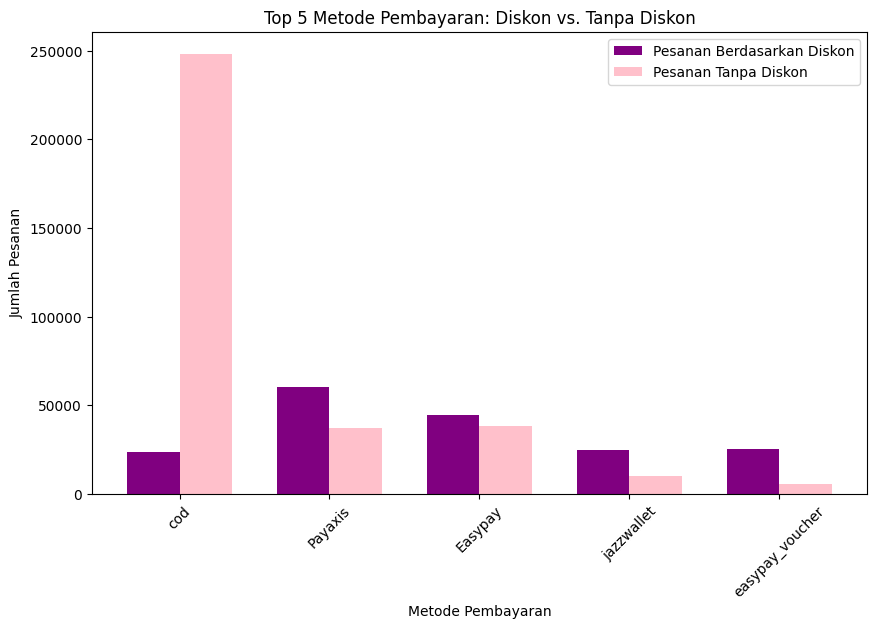

In [31]:

# Select the top 5 payment methods by total orders (Discounted + Non-Discounted)
distribusi_mp['Total_Pesanan'] = distribusi_mp['Pesanan_Diskon'] + distribusi_mp['Pesanan_Tanpa_Diskon']
distribusi_mp_top5 = distribusi_mp.sort_values(by='Total_Pesanan', ascending=False).head(5)

# Plotting Payment Method Distribution (Top 5) - Side by Side Bar Chart
bar_width = 0.35
index = np.arange(len(distribusi_mp_top5))

plt.figure(figsize=(10, 6))
plt.bar(index, distribusi_mp_top5['Pesanan_Diskon'], bar_width, color='purple', label='Pesanan Berdasarkan Diskon')
plt.bar(index + bar_width, distribusi_mp_top5['Pesanan_Tanpa_Diskon'], bar_width, color='pink', label='Pesanan Tanpa Diskon')

plt.title('Top 5 Metode Pembayaran: Diskon vs. Tanpa Diskon')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Pesanan')
plt.xticks(index + bar_width / 2, distribusi_mp_top5.index, rotation=45)
plt.legend()

plt.show()

**Temuan 3.4:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Dominasi COD | *Cash on Delivery* (COD) adalah metode pembayaran yang paling dominan — baik pada pesanan berDiskon maupun tidak. Ini mencerminkan tingkat kepercayaan rendah terhadap pembayaran digital pada pasar e-commerce Pakistan saat itu. |
| COD dan Risiko Pembatalan | COD memiliki risiko penolakan pengiriman (*delivery rejection*) yang lebih tinggi, yang secara langsung berkontribusi pada angka pembatalan pesanan. Hal ini menjadi salah satu alasan mengapa `Payment_Method_cod` menjadi fitur terpenting dalam model prediksi. |
| Pembayaran Digital | Metode seperti *Payaxis* dan *Easypay Voucher* memiliki volume lebih rendah, namun cenderung menghasilkan nilai transaksi yang lebih tinggi dan risiko pembatalan yang lebih rendah. |

**Implikasi Strategis:**

| **Implikasi** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Edukasi Pembayaran Digital | Mendorong migrasi dari COD ke metode pembayaran digital melalui insentif khusus dapat mengurangi risiko pembatalan dan meningkatkan prediktabilitas pendapatan. |
| Segmentasi Promosi | Diskon dapat dirancang secara berbeda berdasarkan metode pembayaran — misalnya, memberikan diskon lebih besar untuk pengguna pembayaran digital guna mendorong adopsi. |

### 3.5. MOV Berdasarkan Metode Pembayaran

Menganalisis bagaimana metode pembayaran memengaruhi nilai median pesanan — membandingkan antara pesanan berDiskon dan tanpa diskon untuk setiap metode pembayaran.

Tabel ini membantu memahami bagaimana berbagai metode pembayaran memengaruhi nilai pesanan ketika ada atau tidaknya diskon.

3.5.1. MOV Pesanan Berdasarkan Metode Pembayaran (Diskon vs. Tanpa Diskon)

In [32]:
# Hitung MOV berdasarkan metode pembayaran
MOV_mp_diskon = pesanan_diskon.groupby('Metode_Pembayaran')['Total_Pesanan'].median()
MOV_mp_tanpa_diskon = pesanan_tanpa_diskon.groupby('Metode_Pembayaran')['Total_Pesanan'].median()

In [33]:
# Create a DataFrame to compare MOV by payment method between discounted and non-discounted orders
mov_by_payment = pd.DataFrame({
    'MOV_Diskon': MOV_mp_diskon,
    'MOV_Tanpa_Diskon': MOV_mp_tanpa_diskon
})

# Fill NaN values with 0 to handle any missing payment methods in either category
mov_by_payment.fillna(0, inplace=True)

# Format the MOV columns with Rupee symbol
mov_by_payment['MOV_Diskon'] = mov_by_payment['MOV_Diskon'].apply(lambda x: f"₹ {x:,.2f}")
mov_by_payment['MOV_Tanpa_Diskon'] = mov_by_payment['MOV_Tanpa_Diskon'].apply(lambda x: f"₹ {x:,.2f}")

# Calculate the total MOV for each category (without formatting for accurate calculation)
total_mov_discounted = MOV_mp_diskon.sum()
total_mov_non_discounted = MOV_mp_tanpa_diskon.sum()

# Add percentage columns
mov_by_payment['Persen_Diskon'] = (MOV_mp_diskon / total_mov_discounted) * 100
mov_by_payment['Persen_Tanpa_Diskon'] = (MOV_mp_tanpa_diskon / total_mov_non_discounted) * 100

# Format the percentage columns as strings with a percentage sign
mov_by_payment['Persen_Diskon'] = mov_by_payment['Persen_Diskon'].map('{:.2f}%'.format)
mov_by_payment['Persen_Tanpa_Diskon'] = mov_by_payment['Persen_Tanpa_Diskon'].map('{:.2f}%'.format)

# Display the DataFrame
mov_by_payment

,MOV_Diskon,MOV_Tanpa_Diskon,Persen_Diskon,Persen_Tanpa_Diskon
Metode_Pembayaran,,,,
Easypay,"₹ 4,229.60","₹ 3,520.00",8.61%,2.46%
Easypay_MA,"₹ 3,518.10","₹ 2,061.00",7.16%,1.44%
Payaxis,"₹ 3,008.00","₹ 6,319.00",6.13%,4.41%
apg,"₹ 5,849.48","₹ 1,825.00",11.91%,1.27%
bankalfalah,"₹ 4,483.00","₹ 7,800.00",9.13%,5.44%
cashatdoorstep,₹ 210.00,₹ 950.00,0.43%,0.66%
cod,₹ 999.00,"₹ 1,260.00",2.03%,0.88%
customercredit,₹ 0.00,₹ 0.00,0.00%,0.00%
easypay_voucher,"₹ 11,970.00","₹ 4,000.00",24.37%,2.79%


---

3.5.2. Visualisasi MOV Berdasarkan Metode Pembayaran

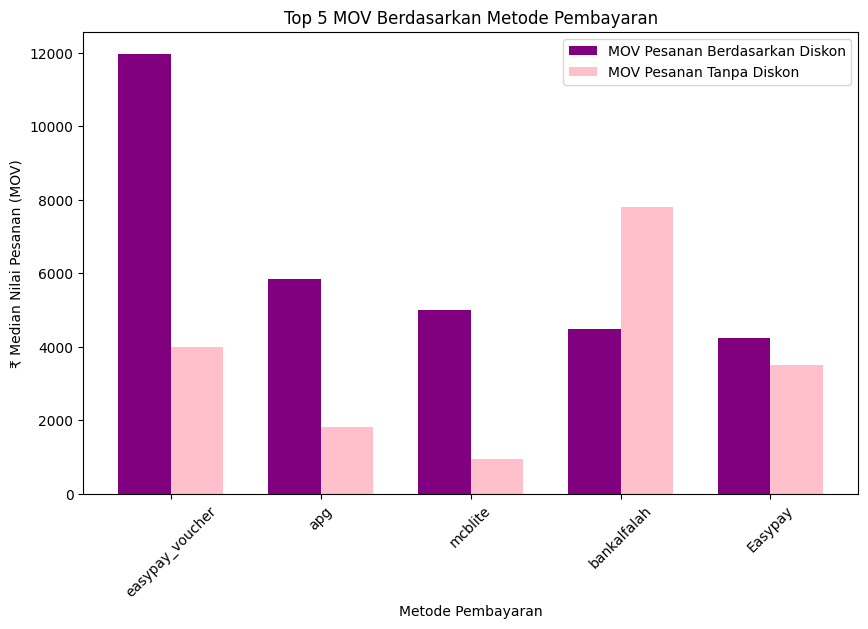

In [34]:
# Convert MOV columns back to numerical values for sorting
mov_by_payment['MOV_Diskon'] = mov_by_payment['MOV_Diskon'].apply(lambda x: float(x.replace('₹', '').replace(',', '')))
mov_by_payment['MOV_Tanpa_Diskon'] = mov_by_payment['MOV_Tanpa_Diskon'].apply(lambda x: float(x.replace('₹', '').replace(',', '')))

# Select the top 5 payment methods by discounted orders MOV
mov_by_payment_top5 = mov_by_payment.sort_values(by='MOV_Diskon', ascending=False).head(5)

# Plotting MOV by Payment (Top 5) - Side by Side Bar Chart
bar_width = 0.35
index = np.arange(len(mov_by_payment_top5))

plt.figure(figsize=(10, 6))
plt.bar(index, mov_by_payment_top5['MOV_Diskon'], bar_width, color='purple', label='MOV Pesanan Berdasarkan Diskon')
plt.bar(index + bar_width, mov_by_payment_top5['MOV_Tanpa_Diskon'], bar_width, color='pink', label='MOV Pesanan Tanpa Diskon')

plt.title('Top 5 MOV Berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('₹ Median Nilai Pesanan (MOV)')
plt.xticks(index + bar_width / 2, mov_by_payment_top5.index, rotation=45)
plt.legend()

plt.show()

**Temuan 3.5.2:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Variasi MOV Antar Metode Pembayaran | Terdapat perbedaan signifikan nilai median pesanan antar metode pembayaran — metode digital cenderung memiliki MOV lebih tinggi dibandingkan COD. |
| Pengaruh Diskon | Pada hampir semua metode pembayaran, pesanan berDiskon memiliki MOV lebih tinggi, konsisten dengan temuan di Subbab 3.2. |

---

3.5.3. Perbandingan Distribusi Metode Pembayaran dan MOV

Membandingkan dua dimensi sekaligus: volume pesanan (popularitas) dan nilai median pesanan untuk setiap metode pembayaran.

**Temuan 3.5.3:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| COD: Volume Tinggi, Nilai Lebih Rendah | COD mendominasi dari sisi volume transaksi, namun nilai median pesanannya lebih rendah dibandingkan metode digital — menunjukkan segmen pelanggan yang berbeda. |
| Metode Digital: Volume Rendah, Nilai Lebih Tinggi | Meski jarang digunakan, transaksi via metode digital cenderung bernilai lebih besar — mengindikasikan pelanggan yang lebih siap secara finansial dan digital. |

---

### 3.6. Uji Statistik: Perbandingan MOV

Untuk memvalidasi perbedaan yang terlihat pada visualisasi, dilakukan dua uji statistik: *Mann-Whitney U Test* untuk membandingkan MOV, dan *Chi-Square Test* untuk distribusi metode pembayaran — keduanya dipilih karena distribusi data tidak normal.

3.6.1. *Mann-Whitney U Test* untuk Perbandingan MOV

Uji Mann-Whitney U dipilih karena distribusi `Total_Pesanan` tidak memenuhi asumsi normalitas. Uji ini membandingkan apakah MOV pesanan berDiskon dan tanpa diskon berbeda secara statistik.

In [35]:
stat, p_value = mannwhitneyu(pesanan_diskon['Total_Pesanan'], pesanan_tanpa_diskon['Total_Pesanan'])
stat, p_value

(46596889178.5, 0.0)

**Interpretasi 3.6.1:**

| **Interpretasi** |
|:-------------------------------------------------------------:|
| Nilai *p-value* yang sangat kecil (< 0,05) mengkonfirmasi bahwa perbedaan MOV antara pesanan berDiskon dan tanpa diskon adalah **signifikan secara statistik**, bukan sekadar kebetulan. Diskon terbukti meningkatkan nilai median pesanan secara nyata. |

3.6.2. *Chi-Square Test* untuk Distribusi Metode Pembayaran

Uji Chi-Square digunakan untuk menguji apakah distribusi metode pembayaran berbeda secara signifikan antara kelompok pesanan berDiskon dan tanpa diskon.

In [36]:
# Uji Chi-Square untuk distribusi metode pembayaran
tabel_kontingensi = pd.crosstab(data['Metode_Pembayaran'],
                                  data['Jumlah_Diskon'].apply(lambda x: 'Diskon' if x > 0 else 'Tanpa Diskon'))
chi2, p, dof, expected = chi2_contingency(tabel_kontingensi)
print(f'Chi-Square: {chi2:.4f}, p-value: {p:.6f}, derajat kebebasan: {dof}')

Chi-Square: 195419.8017, p-value: 0.000000, derajat kebebasan: 17


**Interpretasi 3.6.2:**

| **Interpretasi** |
|:-------------------------------------------------------------:|
| *P-value* yang sangat kecil menunjukkan bahwa distribusi metode pembayaran **berbeda secara signifikan** antara pesanan berDiskon dan tanpa diskon. Dengan kata lain, ada hubungan nyata antara jenis diskon yang diterima dan pilihan metode pembayaran pelanggan. |

3.6.3. Ringkasan Uji Statistik

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| *Mann-Whitney U Test* | Perbedaan MOV antara pesanan berDiskon dan tanpa diskon terbukti signifikan secara statistik (*p* < 0,05). Diskon secara nyata meningkatkan nilai median pesanan. |
| *Chi-Square Test* | Distribusi metode pembayaran berbeda secara signifikan antar kelompok diskon (*p* < 0,05), mengindikasikan adanya korelasi antara pemberian diskon dan pilihan metode pembayaran pelanggan. |
| Implikasi untuk Pemodelan | Temuan ini mengonfirmasi bahwa `Jumlah_Diskon` dan `Metode_Pembayaran` layak digunakan sebagai fitur prediktor dalam model klasifikasi status pesanan. |

### 3.7. Peta Korelasi (*Heatmap*)

Melihat korelasi antar variabel numerik dan variabel kategorikal yang telah di-*encode* untuk mengidentifikasi hubungan yang mungkin relevan untuk pemodelan.

3.7.1. Peta Korelasi: Kolom Numerik dan Kategorikal Ter-*encode*

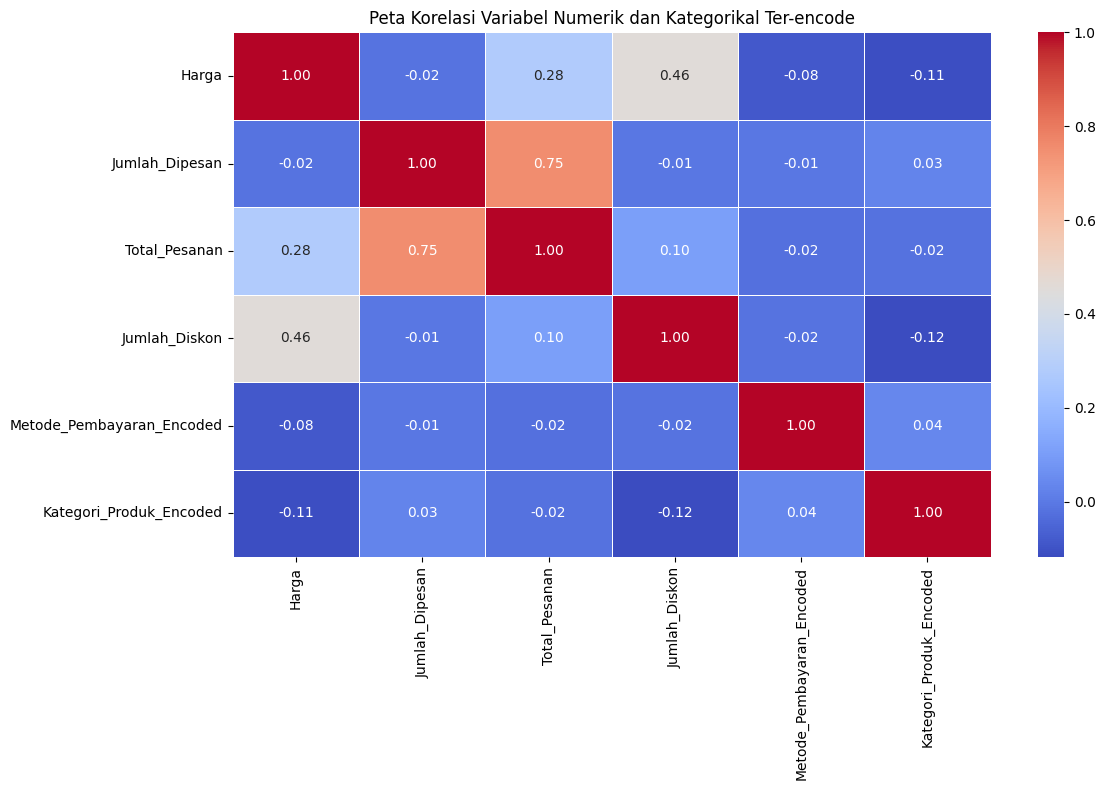

In [37]:
# Encode kolom 'Metode_Pembayaran' dan 'Kategori_Produk' menggunakan LabelEncoder
le = LabelEncoder()
data_encoded = data.copy()
data_encoded['Metode_Pembayaran_Encoded'] = le.fit_transform(data_encoded['Metode_Pembayaran'].astype(str))
data_encoded['Kategori_Produk_Encoded'] = le.fit_transform(data_encoded['Kategori_Produk'].astype(str))

# Hapus kolom tahun, bulan, dan ID pelanggan
kolom_drop = ['Tahun', 'Bulan', 'ID_Pelanggan']
data_encoded = data_encoded.drop(columns=[c for c in kolom_drop if c in data_encoded.columns])

# Pilih kolom numerik untuk heatmap
kolom_numerik = data_encoded.select_dtypes(include='number').columns.tolist()

# Hitung matriks korelasi
matriks_korelasi = data_encoded[kolom_numerik].corr()

# Visualisasi heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriks_korelasi, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Peta Korelasi Variabel Numerik dan Kategorikal Ter-encode')
plt.tight_layout()
plt.show()

**Temuan 3.7:**

| **Peta Korelasi** | **Insight** | **Interpretasi** |
|:---------------:|:---------------:|:-------------------------------------------------------------:|
| `Harga` & `Total_Pesanan` | Korelasi positif kuat | Wajar: semakin tinggi harga satuan, semakin besar total pesanan. |
| `Jumlah_Diskon` & `Total_Pesanan` | Korelasi positif sedang | Diskon yang lebih besar cenderung diberikan pada pesanan bernilai tinggi — konsisten dengan temuan MOV. |
| `Metode_Pembayaran_Encoded` | Korelasi rendah dengan fitur lain | Meskipun lemah secara korelasi linier, metode pembayaran terbukti memiliki pengaruh non-linier yang kuat terhadap status pesanan — hal ini divalidasi oleh uji Chi-Square dan hasil *feature importance* model. |

---

3.7.2. Diskrepansi antara Heatmap dan Uji Statistik

Penting untuk memahami mengapa korelasi Pearson pada heatmap bisa menunjukkan angka kecil, namun uji Chi-Square mendeteksi hubungan yang signifikan.

| **Diskrepansi** | **Analisis** | **Interpretasi** |
|:---------------:|:---------------:|:-------------------------------------------------------------:|
| Korelasi Pearson vs. Chi-Square | Korelasi Pearson mengukur hubungan **linier** antar variabel numerik. Chi-Square menguji hubungan antara variabel **kategorikal**, tanpa asumsi linearitas. |
| Hasil yang Berbeda | Metode pembayaran memiliki hubungan non-linier dan tidak terprediksi secara sederhana oleh heatmap, namun sangat signifikan secara statistik dan deterministik bagi model ML. | Kedua pendekatan saling melengkapi — heatmap untuk eksplorasi awal, uji statistik untuk konfirmasi. |

### 3.8. Analisis *Time-Series*

Mengevaluasi tren penjualan, diskon, dan volume produk yang terjual dari waktu ke waktu. Identifikasi *peak season* di sini langsung digunakan untuk menentukan bulan-bulan puncak yang menjadi konteks analisis kategori produk.

3.8.1. Tren Penjualan, Diskon, dan Kuantitas Terjual

In [38]:
# Agregasi penjualan per Tahun dan Bulan
tren_bulanan = data.groupby(['Tahun', 'Bulan']).agg(
    Total_Penjualan=('Total_Pesanan', 'sum'),
    Total_Diskon=('Jumlah_Diskon', 'sum'),
    Kuantitas_Terjual=('Jumlah_Dipesan', 'sum')
).reset_index()

# Konversi ke format datetime untuk plotting
tren_bulanan['TahunBulan'] = pd.to_datetime(
    tren_bulanan['Tahun'].astype(str) + '-' + tren_bulanan['Bulan'].astype(str) + '-01'
)

# Urutkan berdasarkan TahunBulan
tren_bulanan = tren_bulanan.sort_values('TahunBulan').reset_index(drop=True)

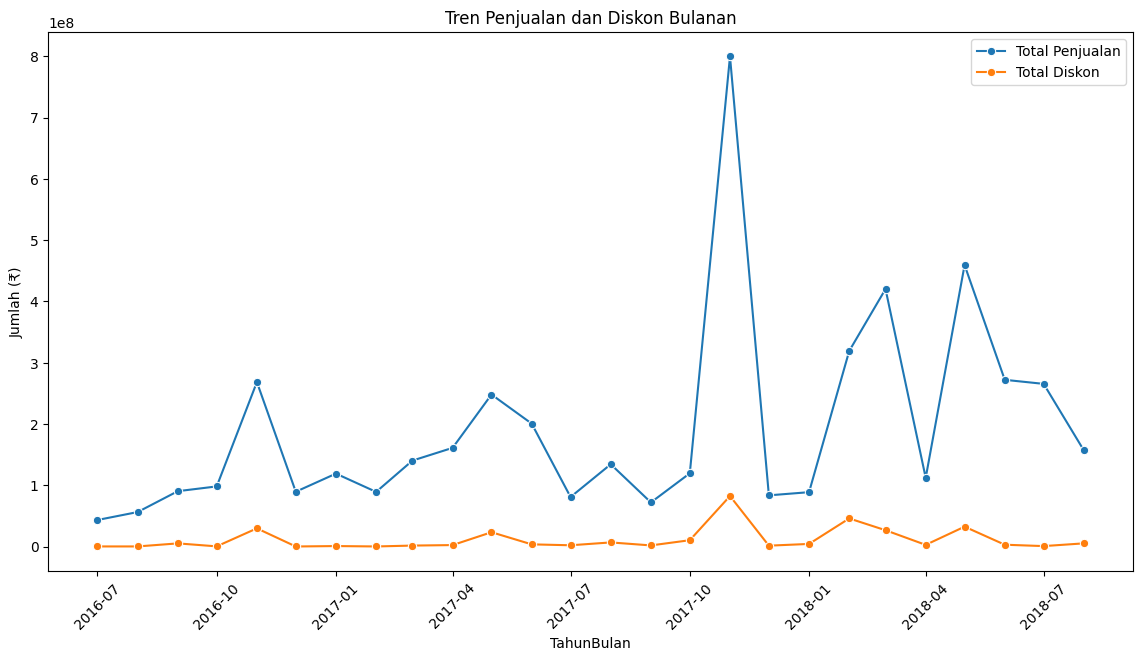

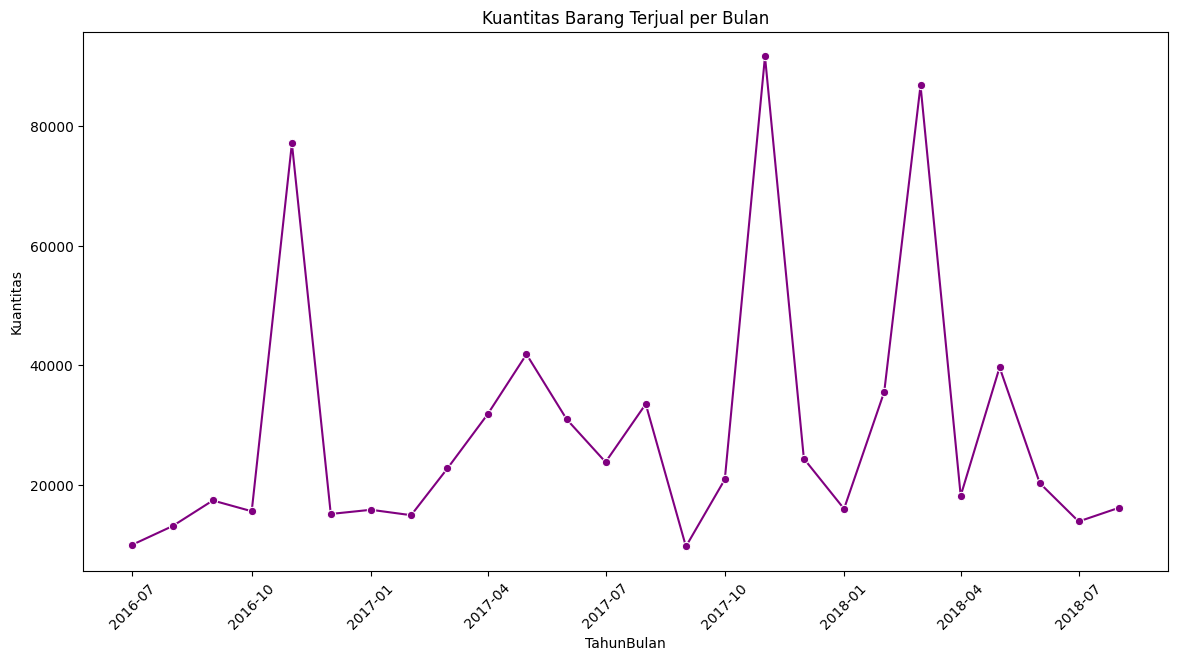

In [39]:
# Plotting monthly sales trends
plt.figure(figsize=(14, 7))
sns.lineplot(x='TahunBulan', y='Total_Penjualan', data=tren_bulanan, marker='o', label='Total Penjualan')
sns.lineplot(x='TahunBulan', y='Total_Diskon', data=tren_bulanan, marker='o', label='Total Diskon')
plt.title('Tren Penjualan dan Diskon Bulanan')
plt.ylabel('Jumlah (₹)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plotting quantity of items sold each month
plt.figure(figsize=(14, 7))
sns.lineplot(x='TahunBulan', y='Kuantitas_Terjual', data=tren_bulanan, marker='o', color='purple')
plt.title('Kuantitas Barang Terjual per Bulan')
plt.ylabel('Kuantitas')
plt.xticks(rotation=45)
plt.show()

**Temuan 3.8.1:**

| **Tren** | **Analisis** | **Interpretasi** |
|:---------------:|:---------------:|:-------------------------------------------------------------:|
| Tren Penjualan | Terdapat lonjakan penjualan yang konsisten pada bulan-bulan tertentu setiap tahunnya | Menandakan adanya musim penjualan puncak yang dapat diprediksi dan dimanfaatkan untuk perencanaan stok. |
| Korelasi Diskon-Penjualan | Lonjakan diskon cenderung beriringan dengan lonjakan penjualan | Diskon adalah salah satu penggerak utama *peak season*, namun juga berpotensi memicu peningkatan pembatalan. |
| Tren Kuantitas | Volume produk yang terjual mengikuti pola yang serupa dengan tren penjualan | Mengindikasikan bahwa lonjakan pendapatan lebih didorong oleh volume transaksi daripada kenaikan harga per unit. |

---

3.8.2. Bukti Statistik: Korelasi antara Tren Penjualan dan Diskon

Menggunakan uji *Spearman Rank Correlation* dan *Kendall Tau* untuk mengukur kekuatan hubungan antara tren penjualan dan tren diskon secara statistik.

In [40]:
# Ambil kolom yang relevan
penjualan = tren_bulanan['Total_Penjualan']
diskon = tren_bulanan['Total_Diskon']

# Hitung koefisien korelasi Spearman dan p-value
spearman_corr, spearman_p = spearmanr(penjualan, diskon)
print(f'Korelasi Spearman: {spearman_corr:.4f}, p-value: {spearman_p:.6f}')

# Interpretasi hasil
if spearman_p < 0.05:
    print('Terdapat korelasi yang signifikan secara statistik antara penjualan dan diskon (Spearman).')
else:
    print('Tidak ditemukan korelasi yang signifikan antara penjualan dan diskon (Spearman).')

Korelasi Spearman: 0.7156, p-value: 0.000040
Terdapat korelasi yang signifikan secara statistik antara penjualan dan diskon (Spearman).


In [41]:
# Hitung koefisien Kendall Tau dan p-value
kendall_corr, kendall_p = kendalltau(penjualan, diskon)
print(f'Korelasi Kendall Tau: {kendall_corr:.4f}, p-value: {kendall_p:.6f}')

# Interpretasi hasil
if kendall_p < 0.05:
    print('Terdapat korelasi yang signifikan secara statistik antara penjualan dan diskon (Kendall Tau).')
else:
    print('Tidak ditemukan korelasi yang signifikan antara penjualan dan diskon (Kendall Tau).')

Korelasi Kendall Tau: 0.5446, p-value: 0.000046
Terdapat korelasi yang signifikan secara statistik antara penjualan dan diskon (Kendall Tau).


**Interpretasi 3.8.2:**

| **Implikasi** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Korelasi Signifikan | Kedua uji (Spearman & Kendall Tau) mengkonfirmasi adanya korelasi positif yang signifikan antara tren penjualan dan tren diskon — artinya bulan dengan diskon tinggi cenderung juga merupakan bulan dengan penjualan tinggi. |
| Kausalitas vs. Korelasi | Korelasi ini tidak serta-merta berarti kausalitas: bisa jadi diskon yang mendorong penjualan, atau *peak season* yang memang mendorong platform untuk menggencarkan diskon secara bersamaan. |
| Relevansi untuk Manajemen Risiko | Karena *peak season* = diskon besar = penjualan tinggi, tim operasional perlu mempersiapkan kapasitas logistik ekstra agar lonjakan pesanan tidak berujung pada pembatalan massal. |

---

3.8.3. Total Penjualan Berdasarkan Kategori Produk

Membandingkan performa kategori produk saat *peak season* vs. secara keseluruhan — memberikan konteks tentang kategori mana yang paling sensitif terhadap periode promosi.

1. Total Penjualan Saat *Peak Season* Berdasarkan Kategori Produk

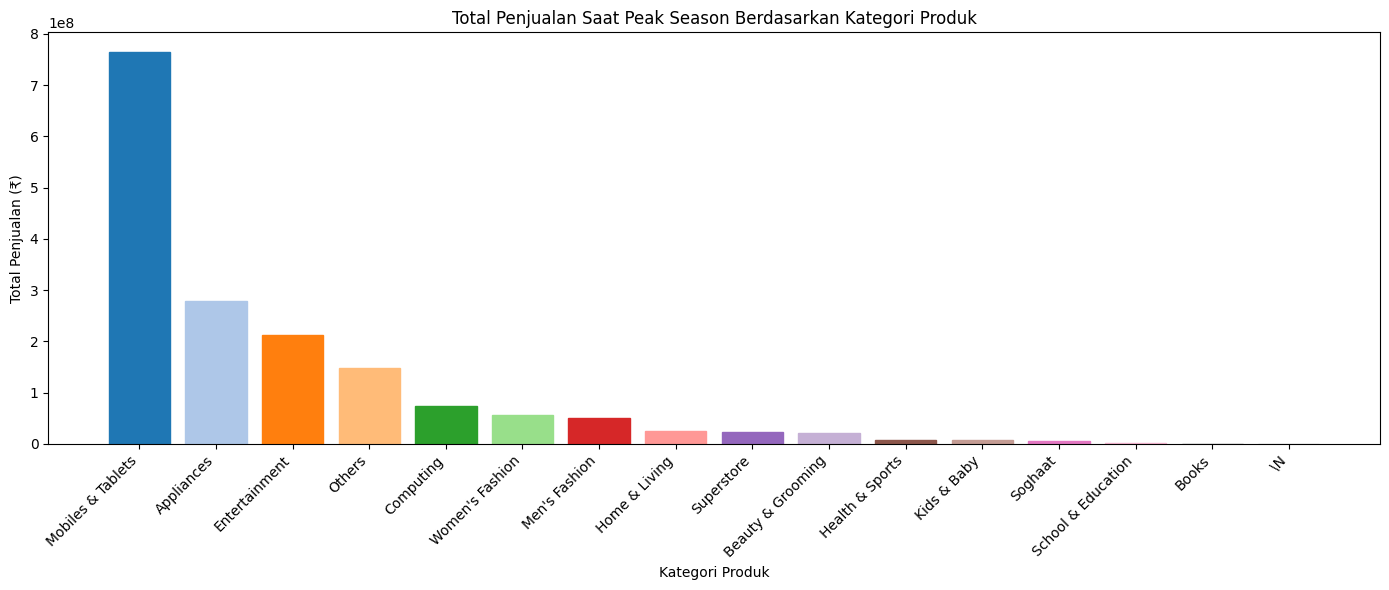

In [42]:
# Identifikasi bulan puncak (3 bulan dengan penjualan tertinggi)
bulan_puncak = tren_bulanan.nlargest(3, 'Total_Penjualan')[['Tahun', 'Bulan']]

# Identifikasi bulan dengan penjualan tertinggi
daftar_bulan_puncak = list(zip(bulan_puncak['Tahun'], bulan_puncak['Bulan']))

# Filter data hanya untuk bulan puncak
data_puncak = data[data.apply(lambda r: (r['Tahun'], r['Bulan']) in daftar_bulan_puncak, axis=1)]

# Kelompokkan berdasarkan kategori produk dan hitung total penjualan saat peak season
penjualan_puncak = data_puncak.groupby('Kategori_Produk')['Total_Pesanan'].sum().reset_index()
penjualan_puncak.columns = ['Kategori_Produk', 'Total_Penjualan_Puncak']

# Urutkan dari tertinggi ke terendah
penjualan_puncak = penjualan_puncak.sort_values('Total_Penjualan_Puncak', ascending=False)

# Visualisasi
warna_unik = plt.cm.tab20.colors
plt.figure(figsize=(14, 6))
bars = plt.bar(penjualan_puncak['Kategori_Produk'], penjualan_puncak['Total_Penjualan_Puncak'],
               color=warna_unik[:len(penjualan_puncak)])
for bar in bars:
    bar.set_color(warna_unik[bars.index(bar) % len(warna_unik)])
plt.title('Total Penjualan Saat Peak Season Berdasarkan Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Penjualan (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

2. Total Penjualan Keseluruhan Berdasarkan Kategori Produk

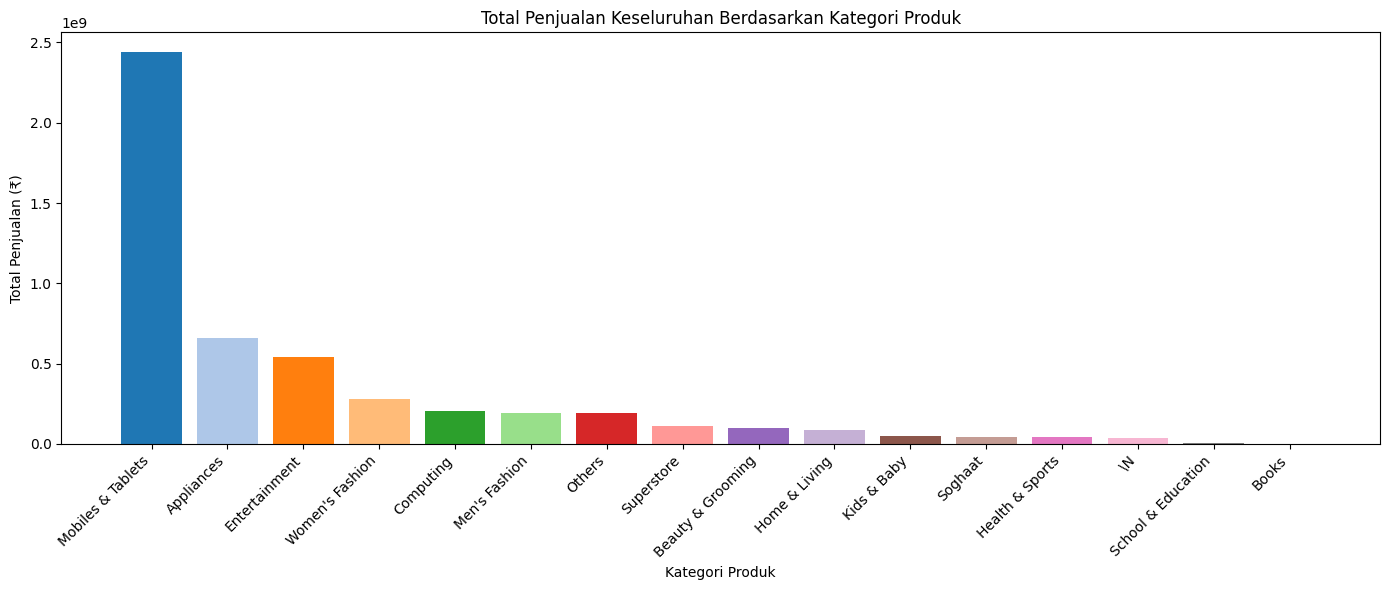

In [43]:
# Agregasi total penjualan per kategori produk (keseluruhan tahun)
penjualan_keseluruhan = data.groupby('Kategori_Produk')['Total_Pesanan'].sum().reset_index()
penjualan_keseluruhan.columns = ['Kategori_Produk', 'Total_Penjualan']

# Urutkan dari tertinggi ke terendah
penjualan_keseluruhan = penjualan_keseluruhan.sort_values('Total_Penjualan', ascending=False)

# Visualisasi
plt.figure(figsize=(14, 6))
bars = plt.bar(penjualan_keseluruhan['Kategori_Produk'], penjualan_keseluruhan['Total_Penjualan'],
               color=warna_unik[:len(penjualan_keseluruhan)])
plt.title('Total Penjualan Keseluruhan Berdasarkan Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Penjualan (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3. Perbandingan Penjualan *Peak Season* vs. Keseluruhan Berdasarkan Kategori Produk

| **Produk** | **Musim** | **Interpretasi** |
|:----:|:----:|:-------------------------------------------------------------:|
| Mobiles & Tablets | Peak Season & Keseluruhan | Kategori dengan pendapatan tertinggi secara konsisten — baik saat *peak season* maupun sepanjang tahun. Nilai transaksi tinggi menjadikannya penggerak utama pendapatan platform. |
| Appliances | Peak Season & Keseluruhan | Konsisten berada di posisi kedua atau ketiga, menunjukkan permintaan yang stabil. |
| Fashion (Pria & Wanita) | Keseluruhan | Lebih menonjol secara volume transaksi daripada nilai pendapatan; sensitif terhadap *peak season* seperti Eid. |
| Soghaat & Others | Keseluruhan | Kategori niche dengan volume rendah namun secara mengejutkan masuk dalam daftar *feature importance* model ML. |

**Implikasi:**

| **Implikasi** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Prioritas Manajemen Stok | Kategori *Mobiles & Tablets* dan *Appliances* harus mendapat prioritas ketersediaan stok ekstra menjelang *peak season* untuk mencegah pembatalan akibat kehabisan stok. |
| Strategi Promosi | *Peak season* adalah momentum paling efektif untuk menggenjot penjualan kategori premium, namun perlu diiringi kesiapan logistik yang matang. |

---

### 3.9. Total Kuantitas Berdasarkan Kategori Produk

Melengkapi analisis sebelumnya dengan perspektif volume: kategori produk mana yang paling banyak dibeli dalam satuan unit — baik secara keseluruhan maupun saat *peak season*.

3.9.1. Perbandingan Volume Terjual: *Peak Season* vs. Keseluruhan

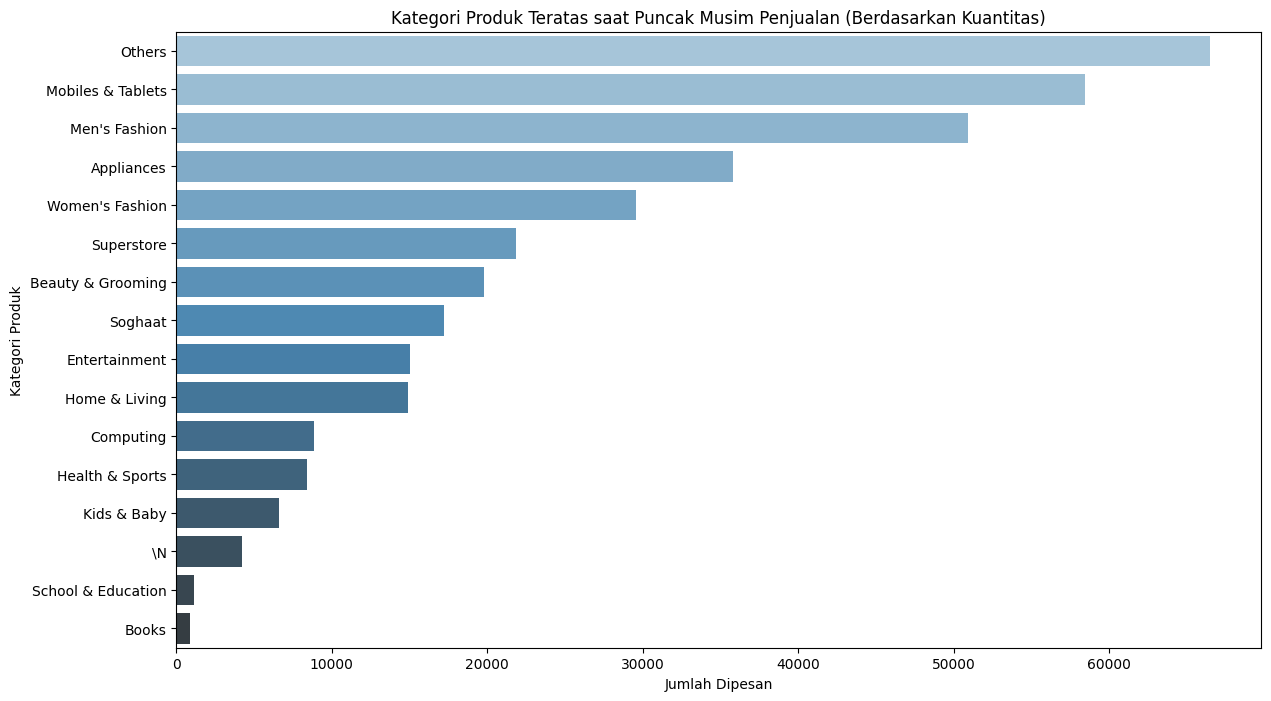

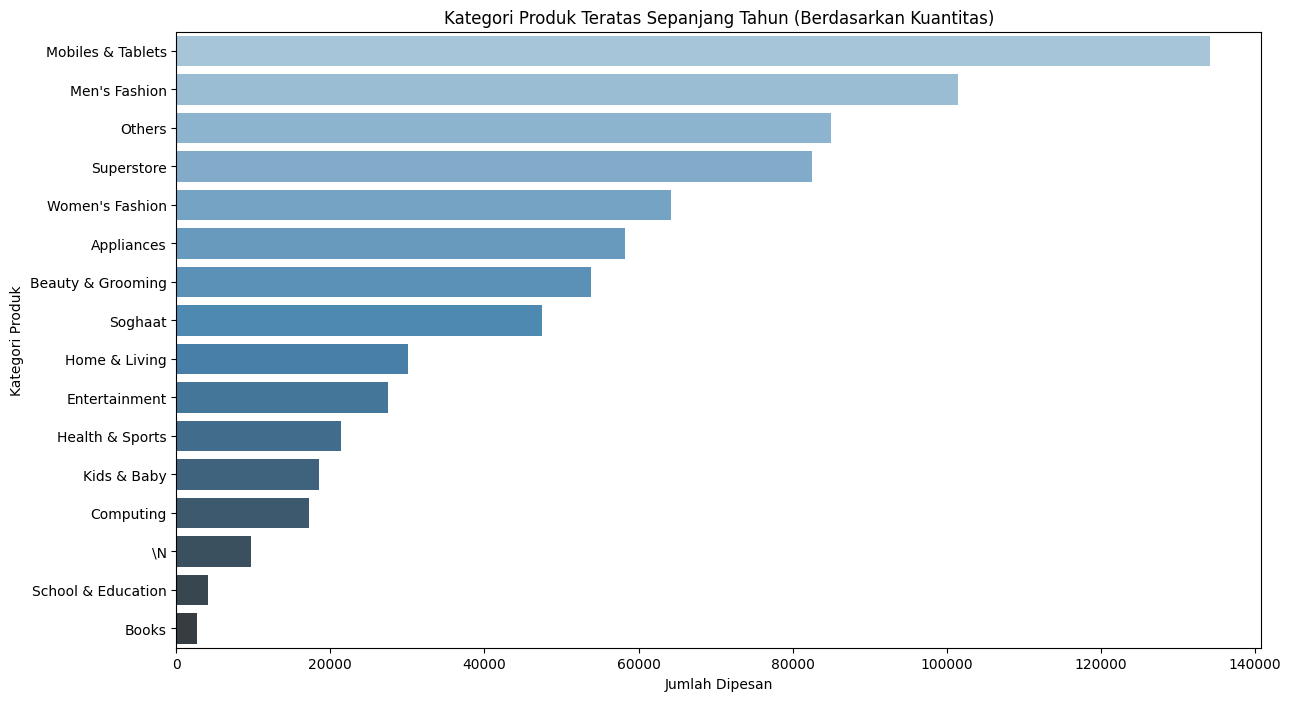

In [44]:
# Identifikasi bulan puncak berdasarkan total penjualan (3 bulan tertinggi)
bulan_puncak_list = tren_bulanan.groupby('Bulan')['Total_Penjualan'].sum().nlargest(3).index.tolist()

# Filter data hanya untuk bulan puncak
data_puncak = data[data['Bulan'].isin(bulan_puncak_list)]

# Jumlah pesanan per kategori produk saat puncak musim
qty_puncak = data_puncak.groupby('Kategori_Produk').agg(
    Jumlah_Dipesan=('Jumlah_Dipesan', 'sum')
).reset_index().sort_values('Jumlah_Dipesan', ascending=False)

# Jumlah pesanan per kategori produk secara keseluruhan
qty_keseluruhan = data.groupby('Kategori_Produk').agg(
    Jumlah_Dipesan=('Jumlah_Dipesan', 'sum')
).reset_index().sort_values('Jumlah_Dipesan', ascending=False)

# Plot: peak season
plt.figure(figsize=(14, 8))
sns.barplot(x='Jumlah_Dipesan', y='Kategori_Produk', data=qty_puncak, palette='Blues_d')
plt.title('Kategori Produk Teratas saat Puncak Musim Penjualan (Berdasarkan Kuantitas)')
plt.xlabel('Jumlah Dipesan')
plt.ylabel('Kategori Produk')
plt.show()

# Plot: keseluruhan
plt.figure(figsize=(14, 8))
sns.barplot(x='Jumlah_Dipesan', y='Kategori_Produk', data=qty_keseluruhan, palette='Blues_d')
plt.title('Kategori Produk Teratas Sepanjang Tahun (Berdasarkan Kuantitas)')
plt.xlabel('Jumlah Dipesan')
plt.ylabel('Kategori Produk')
plt.show()

**Temuan 3.9:**

| **Insight** | **Produk** | **Interpretasi** |
|:---------------:|:---------------:|:-------------------------------------------------------------:|
| Volume Tertinggi | Fashion (Pria & Wanita) | Kategori Fashion mendominasi volume transaksi dalam satuan unit — namun nilai per unitnya lebih rendah dibanding elektronik, sehingga kontribusi pendapatannya tidak setinggi volumenya. |
| Volume *Peak Season* | Mobiles & Tablets | Lonjakan volume saat *peak season* paling signifikan terjadi pada kategori elektronik — mencerminkan perilaku pembelian terencana saat ada promo besar. |

**Implikasi:**

| **Implikasi** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Manajemen Logistik | Kategori Fashion memerlukan kapasitas logistik yang besar secara konsisten sepanjang tahun — bukan hanya saat *peak season*. |
| Risiko Refund | Volume Fashion yang tinggi, dikombinasikan dengan sifat produk yang sulit diverifikasi secara visual online, berkontribusi pada tingkat *refund* yang lebih tinggi — seperti yang akan terlihat di analisis status pesanan. |

---

### 3.10. Analisis Status Pesanan

Ini adalah inti dari keseluruhan analisis. Memahami distribusi, tren, dan faktor penyebab dari setiap status pesanan — khususnya pembatalan dan *refund* — adalah fondasi langsung bagi target variabel (*y*) yang digunakan dalam model Machine Learning di Seksi 4—6.

3.10.1. Jumlah Pesanan Berdasarkan Status

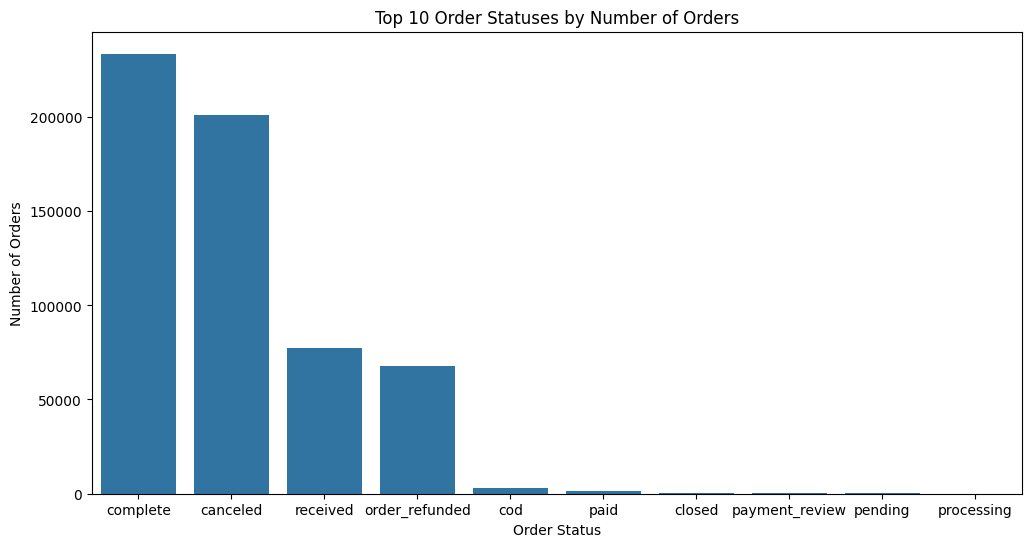

In [45]:
# Count the number of orders by status and take the top 10
order_status_counts = data['status'].value_counts().nlargest(10)

# Plot the number of orders by status (top 10)
plt.figure(figsize=(12, 6))
sns.barplot(x=order_status_counts.index, y=order_status_counts.values)
plt.title('Top 10 Order Statuses by Number of Orders')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

In [46]:
order_status_counts

status
complete          233700
canceled          201249
received           77290
order_refunded     67579
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
Name: count, dtype: int64

Mengingat jumlah pesanan `canceled` dan `order_refunded` yang signifikan dan masuk dalam tiga besar status, analisis berikutnya akan difokuskan pada karakteristik kedua status ini untuk memahami pola dan pemicunya — yang juga menjadi dasar untuk pemodelan prediktif.

---

3.10.2. Analisis Status `canceled` dan `order_refunded`

1. Tren Sepanjang Waktu

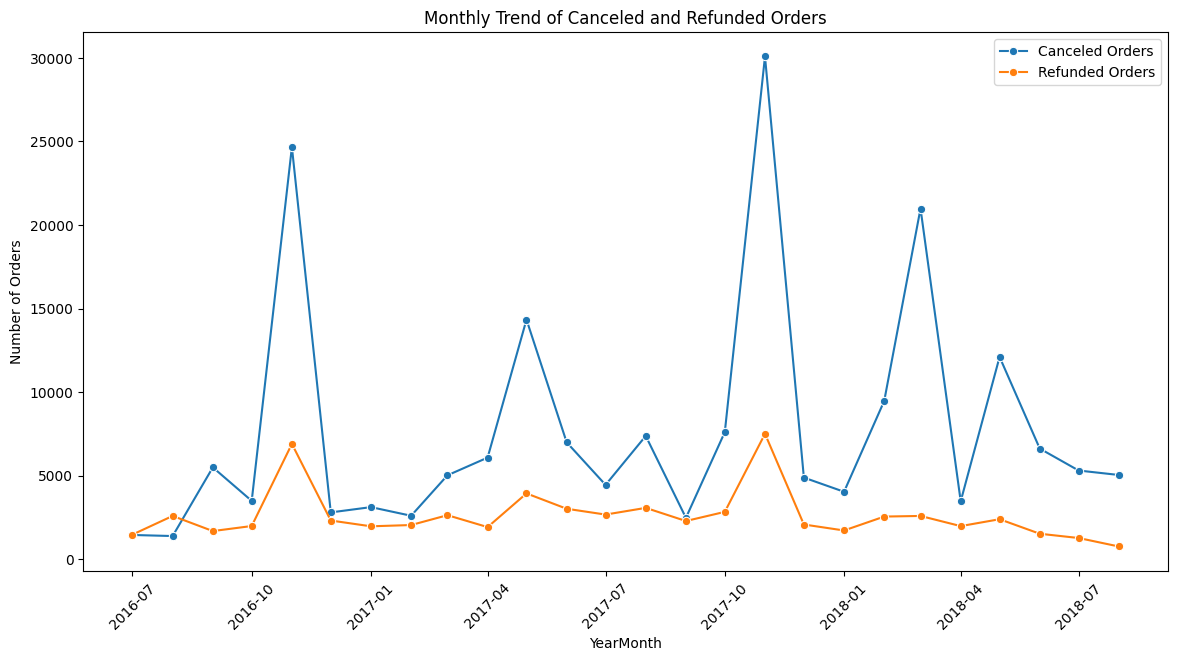

In [47]:
# Filter the data for canceled and refunded orders
canceled_data = data[data['status'] == 'canceled']
refunded_data = data[data['status'] == 'order_refunded']

# Aggregate the number of orders by month and year for each status
canceled_monthly = canceled_data.groupby(['Tahun', 'Bulan']).size().reset_index(name='Canceled_Orders')
refunded_monthly = refunded_data.groupby(['Tahun', 'Bulan']).size().reset_index(name='Refunded_Orders')

# Merge the dataframes to have both trends in one
monthly_trends = pd.merge(canceled_monthly, refunded_monthly, on=['Tahun', 'Bulan'], how='outer').fillna(0)

# Sort the data by Year and Month
monthly_trends.sort_values(by=['Tahun', 'Bulan'], inplace=True)

# Convert Year and Month to datetime format for better plotting
monthly_trends['YearMonth'] = pd.to_datetime(monthly_trends[['Tahun', 'Bulan']].rename(columns={'Tahun': 'year', 'Bulan': 'month'}).assign(day=1))

# Plotting the trends
plt.figure(figsize=(14, 7))
sns.lineplot(x='YearMonth', y='Canceled_Orders', data=monthly_trends, marker='o', label='Canceled Orders')
sns.lineplot(x='YearMonth', y='Refunded_Orders', data=monthly_trends, marker='o', label='Refunded Orders')
plt.title('Monthly Trend of Canceled and Refunded Orders')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Temuan 3.10.1:**

| **Insight** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Tren Pembatalan | Angka pembatalan cenderung meningkat bersamaan dengan lonjakan penjualan — mengkonfirmasi bahwa *peak season* bukan hanya membawa lebih banyak transaksi, tetapi juga lebih banyak pembatalan. |
| Tren Refund | Angka *refund* lebih stabil namun tetap ada peningkatan pada periode tertentu, kemungkinan terkait dengan kategori produk tertentu seperti Fashion. |

2. Uji Statistik: Korelasi dengan Tren Penjualan

In [48]:
# Reset index supaya 'item_id' kembali sebagai kolom
data_reset = data.reset_index()

# Total pesanan per tahun-bulan
total_pesanan_bulanan = data_reset.groupby(['Tahun', 'Bulan']).size().reset_index(name='Total_Pesanan')

# Pesanan canceled per tahun-bulan
canceled_bulanan = data_reset[data_reset['status'] == 'canceled'].groupby(['Tahun', 'Bulan']).size().reset_index(name='Pesanan_Canceled')

# Pesanan refunded per tahun-bulan
refunded_bulanan = data_reset[data_reset['status'] == 'order_refunded'].groupby(['Tahun', 'Bulan']).size().reset_index(name='Pesanan_Refunded')

# Gabungkan
monthly_canceled_refunded = (total_pesanan_bulanan
    .merge(canceled_bulanan, on=['Tahun', 'Bulan'], how='left')
    .merge(refunded_bulanan, on=['Tahun', 'Bulan'], how='left')
    .fillna(0)
)
# Beri nama kolom yang konsisten untuk cell berikutnya
monthly_canceled_refunded.columns = ['Tahun', 'Bulan', 'Total Orders', 'Canceled Orders', 'Refunded Orders']
monthly_canceled_refunded.head()

,Tahun,Bulan,Total Orders,Canceled Orders,Refunded Orders
0,2016,7,8837,1445,1469
1,2016,8,11535,1381,2585
2,2016,9,15433,5492,1679
3,2016,10,13124,3486,1981
4,2016,11,71528,24664,6897


In [49]:
# Calculate Spearman's Rank Correlation for Canceled Orders vs. Total Sales
spearman_canceled_sales_corr, spearman_canceled_sales_p = spearmanr(monthly_canceled_refunded['Canceled Orders'], tren_bulanan['Total_Penjualan'])
print(f"Spearman Rank Correlation (Canceled Orders vs. Total Sales): {spearman_canceled_sales_corr}")
print(f"P-value: {spearman_canceled_sales_p}")

# Calculate Spearman's Rank Correlation for Refunded Orders vs. Total Sales
spearman_refunded_sales_corr, spearman_refunded_sales_p = spearmanr(monthly_canceled_refunded['Refunded Orders'], tren_bulanan['Total_Penjualan'])
print(f"Spearman Rank Correlation (Refunded Orders vs. Total Sales): {spearman_refunded_sales_corr}")
print(f"P-value: {spearman_refunded_sales_p}")

# Calculate Kendall's Tau Correlation for Canceled Orders vs. Total Sales
kendall_canceled_sales_corr, kendall_canceled_sales_p = kendalltau(monthly_canceled_refunded['Canceled Orders'], tren_bulanan['Total_Penjualan'])
print(f"Kendall's Tau Correlation (Canceled Orders vs. Total Sales): {kendall_canceled_sales_corr}")
print(f"P-value: {kendall_canceled_sales_p}")

# Calculate Kendall's Tau Correlation for Refunded Orders vs. Total Sales
kendall_refunded_sales_corr, kendall_refunded_sales_p = kendalltau(monthly_canceled_refunded['Refunded Orders'], tren_bulanan['Total_Penjualan'])
print(f"Kendall's Tau Correlation (Refunded Orders vs. Total Sales): {kendall_refunded_sales_corr}")
print(f"P-value: {kendall_refunded_sales_p}")

Spearman Rank Correlation (Canceled Orders vs. Total Sales): 0.865982905982906
P-value: 1.0995166876026844e-08
Spearman Rank Correlation (Refunded Orders vs. Total Sales): 0.2676923076923077
P-value: 0.1861284492408197
Kendall's Tau Correlation (Canceled Orders vs. Total Sales): 0.68
P-value: 1.0318341390342641e-07
Kendall's Tau Correlation (Refunded Orders vs. Total Sales): 0.16923076923076924
P-value: 0.23653490275785774


**Temuan 3.10.2:**

| **Insight** | **Uji Statistik** | **Interpretasi** |
|:---------------:|:---------------:|:-------------------------------------------------------------:|
| Korelasi Pembatalan-Penjualan | Spearman / Kendall | Terdapat korelasi positif signifikan antara total penjualan dan jumlah pembatalan — bulan dengan penjualan tinggi juga merupakan bulan dengan pembatalan lebih banyak. |
| Implikasi Manajerial | — | Strategi mitigasi pembatalan harus diintensifkan justru pada periode *peak season*, bukan setelahnya. |

3. Distribusi Status Canceled dan Refunded Berdasarkan Kategori Produk

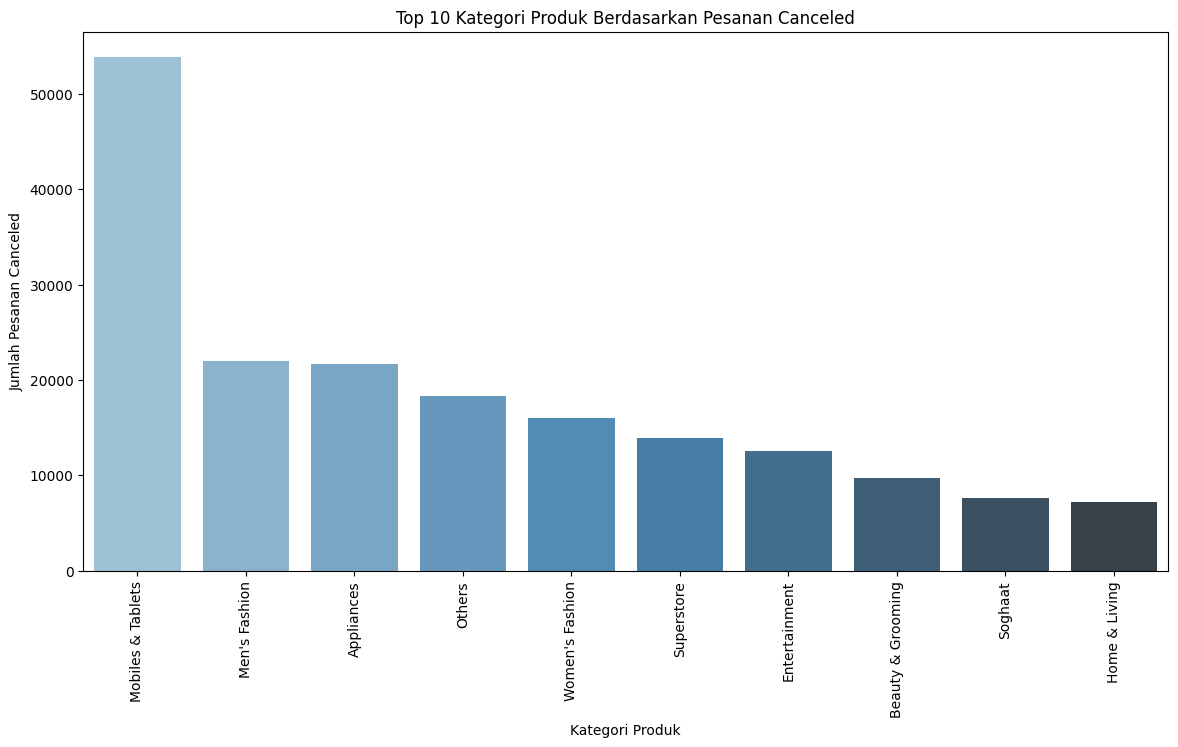

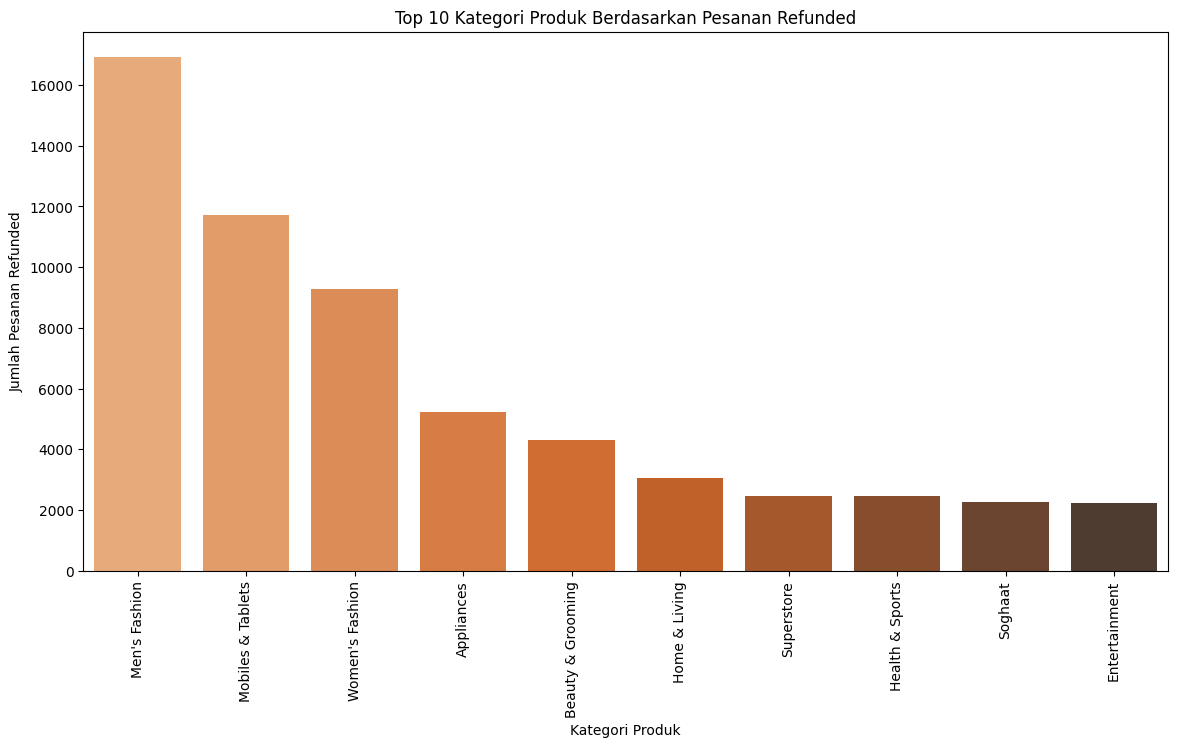

In [50]:
# Group the data by 'Kategori_Produk' and 'Order_Status'
canceled_orders_by_category = data[data['status'] == 'canceled'].groupby('Kategori_Produk').size().nlargest(10)
refunded_orders_by_category = data[data['status'] == 'order_refunded'].groupby('Kategori_Produk').size().nlargest(10)

# Plot the distribution for the top 10 canceled orders
plt.figure(figsize=(14, 7))
sns.barplot(x=canceled_orders_by_category.index, y=canceled_orders_by_category.values, palette="Blues_d")
plt.title('Top 10 Kategori Produk Berdasarkan Pesanan Canceled')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Pesanan Canceled')
plt.xticks(rotation=90)
plt.show()

# Plot the distribution for the top 10 refunded orders
plt.figure(figsize=(14, 7))
sns.barplot(x=refunded_orders_by_category.index, y=refunded_orders_by_category.values, palette="Oranges_d")
plt.title('Top 10 Kategori Produk Berdasarkan Pesanan Refunded')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Pesanan Refunded')
plt.xticks(rotation=90)
plt.show()

Kedua *bar chart* di atas menampilkan perbandingan 10 kategori produk berdasarkan jumlah pesanan yang dibatalkan vs. dikembalikan. Pola yang berbeda antara keduanya mengindikasikan bahwa faktor penyebab pembatalan dan *refund* bisa berbeda antar kategori — pembatalan lebih banyak pada elektronik bernilai tinggi, sementara *refund* lebih umum pada kategori Fashion.

4. Dampak Pembatalan dan *Refund* terhadap Retensi Pelanggan

Membandingkan tingkat retensi antara pelanggan yang mengalami pembatalan/refund dengan yang tidak.

In [51]:
# Pelanggan yang melakukan lebih dari satu pesanan
pelanggan_berulang = data['ID_Pelanggan'].value_counts()
pelanggan_retained = (pelanggan_berulang > 1).sum()

# Tingkat retensi
total_pelanggan = data['ID_Pelanggan'].nunique()
tingkat_retensi = pelanggan_retained / total_pelanggan
print(f'Tingkat Retensi Pelanggan: {tingkat_retensi:.2%}')

Tingkat Retensi Pelanggan: 56.30%


Retensi Keseluruhan:         56.30%
Retensi Pelanggan Canceled:  73.89%
Retensi Pelanggan Refunded:  68.66%


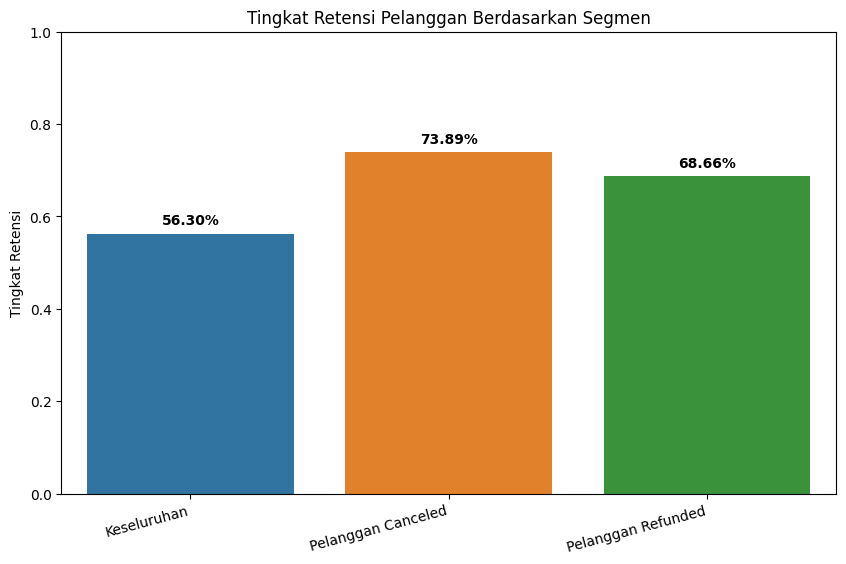

In [52]:
# Tingkat retensi per kelompok status pesanan
pelanggan_canceled = data[data['status'] == 'canceled']['ID_Pelanggan'].unique()
pelanggan_refunded = data[data['status'] == 'order_refunded']['ID_Pelanggan'].unique()

# Hitung pelanggan berulang di masing-masing segmen
def retensi_segmen(pelanggan_ids):
    vc = data[data['ID_Pelanggan'].isin(pelanggan_ids)]['ID_Pelanggan'].value_counts()
    return (vc > 1).sum() / max(len(vc), 1)

retention_rate_overall  = tingkat_retensi
retention_rate_canceled = retensi_segmen(pelanggan_canceled)
retention_rate_refunded = retensi_segmen(pelanggan_refunded)

print(f'Retensi Keseluruhan:         {retention_rate_overall:.2%}')
print(f'Retensi Pelanggan Canceled:  {retention_rate_canceled:.2%}')
print(f'Retensi Pelanggan Refunded:  {retention_rate_refunded:.2%}')

# Visualisasi
kategori = ['Keseluruhan', 'Pelanggan Canceled', 'Pelanggan Refunded']
nilai = [retention_rate_overall, retention_rate_canceled, retention_rate_refunded]
warna_ret = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 6))
sns.barplot(x=kategori, y=nilai, palette=warna_ret)
plt.ylim(0, 1)
plt.title('Tingkat Retensi Pelanggan Berdasarkan Segmen')
plt.ylabel('Tingkat Retensi')
for idx, v in enumerate(nilai):
    plt.text(idx, v + 0.02, f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.show()

**Temuan 3.10 — Retensi:**

| **Pelanggan** | **Interpretasi** |
|:---------------:|:-------------------------------------------------------------:|
| Pelanggan dengan Pembatalan/Refund | Cenderung memiliki tingkat pembelian ulang yang lebih rendah — menunjukkan bahwa pengalaman buruk secara langsung memengaruhi loyalitas. |
| Implikasi | Menurunkan angka pembatalan dan *refund* bukan hanya soal efisiensi operasional, tetapi juga strategi retensi jangka panjang. Program *recovery* pasca-pembatalan (seperti kompensasi poin atau diskon khusus) dapat menjadi solusi efektif. |

---

**Ringkasan Analisis Data (Seksi 3):**

| **Temuan Utama** | **Relevansi untuk Pemodelan** |
|:---------------:|:-------------------------------------------------------------:|
| 35,62% pesanan mendapatkan diskon; pesanan berDiskon memiliki MOV ~2x lebih tinggi | `Jumlah_Diskon` adalah fitur potensial yang mencerminkan pola transaksi. |
| COD mendominasi (~70%) dan berkorelasi dengan risiko pembatalan lebih tinggi | `Metode_Pembayaran` terbukti menjadi fitur paling deterministik dalam model ML. |
| Mobiles & Tablets dan Appliances mendominasi pendapatan; Fashion mendominasi volume | `Kategori_Produk` memiliki pengaruh berbeda terhadap *refund* dan pembatalan. |
| Pembatalan berkorelasi signifikan dengan lonjakan penjualan (*peak season*) | Pola temporal ini mendukung pentingnya fitur `Total_Pesanan` sebagai prediktor. |
| Pelanggan yang mengalami pembatalan/refund cenderung tidak kembali berbelanja | Menurunkan pembatalan = meningkatkan retensi — sejalan dengan tujuan bisnis. |

# 4. *Preprocessing* Data untuk Pemodelan Multikelas

Berbekal wawasan dari Seksi 3 — terutama temuan bahwa metode pembayaran, nilai pesanan, dan kategori produk berkorelasi kuat dengan status pesanan — tahap ini menyiapkan data untuk pemodelan *Machine Learning*. Target yang diprediksi adalah status pesanan: `complete`, `canceled`, dan `order_refunded` (klasifikasi multikelas).

### 4.1. Penyaringan & Pengambilan Sampel Data
Dataset disaring hanya untuk 3 kelas target. Mengingat ukuran dataset yang sangat besar, diambil sampel acak sebanyak 15.000 baris untuk mencegah *bottleneck* komputasi, terutama pada algoritma berat seperti SVM.

In [53]:
# Filter data hanya untuk 3 kelas target
data_ml = data[data['status'].isin(['complete', 'canceled', 'order_refunded'])].copy()

# Ambil sampel acak 15.000 baris untuk efisiensi komputasi
data_ml = data_ml.sample(n=15000, random_state=42)
print(f'Total data setelah disampel: {data_ml.shape[0]} baris.')

Total data setelah disampel: 15000 baris.


### 4.2. Pemilihan Fitur & *Encoding*

Fitur prediktor yang dipilih — `Harga`, `Jumlah_Dipesan`, `Total_Pesanan`, `Kategori_Produk`, dan `Metode_Pembayaran` — adalah variabel-variabel yang terbukti paling relevan dari analisis di Seksi 3. Target (`status`) di-*encode* menggunakan `LabelEncoder`, sementara fitur kategorikal diubah menggunakan *One-Hot Encoding*.

In [54]:
# 1. Tentukan fitur prediktor (X) dan target (y)
# MENGGUNAKAN NAMA KOLOM BARU HASIL RENAME
fitur = ['Harga', 'Jumlah_Dipesan', 'Total_Pesanan', 'Kategori_Produk', 'Metode_Pembayaran']
X = data_ml[fitur]

# Kolom status tidak ikut di-rename, tetap huruf kecil
y = data_ml['status']

# 2. Label Encoding untuk target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Tampilkan mapping kelas
mapping_kelas = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f'Mapping Target: {mapping_kelas}')

# 3. One-Hot Encoding untuk fitur kategorikal
X_encoded = pd.get_dummies(X, columns=['Kategori_Produk', 'Metode_Pembayaran'], drop_first=True)

print(f'Encoding selesai! Dimensi X_encoded: {X_encoded.shape}')

Mapping Target: {'canceled': 0, 'complete': 1, 'order_refunded': 2}
Encoding selesai! Dimensi X_encoded: (15000, 35)


### 4.3. Pembagian Data Latih dan Uji (*Train-Test Split*)

Data dibagi menjadi 80% data latih dan 20% data uji dengan `random_state=42` untuk memastikan hasil yang dapat direproduksi.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

print(f'Dimensi X_train: {X_train.shape}')
print(f'Dimensi X_test: {X_test.shape}')

Dimensi X_train: (12000, 35)
Dimensi X_test: (3000, 35)


---

**Ringkasan *Preprocessing* (Seksi 4):**
Dataset disaring menjadi 3 kelas target dan diambil sampel 15.000 baris. Fitur-fitur yang dipilih (`Harga`, `Jumlah_Dipesan`, `Total_Pesanan`, `Kategori_Produk`, `Metode_Pembayaran`) mencerminkan temuan EDA di Seksi 3. Setelah *One-Hot Encoding*, dimensi fitur menjadi 35 kolom, siap untuk pelatihan model.

# 5. *Machine Learning* & *Ablation Study*

Melatih 4 algoritma klasifikasi — *Logistic Regression*, *Naive Bayes*, *Random Forest*, dan *SVM* — dalam 4 skenario *preprocessing* berbeda untuk menemukan kombinasi terbaik. Pendekatan ini disebut *Ablation Study*: menguji secara sistematis pengaruh setiap tahapan *preprocessing* terhadap performa model.

### 5.1. Inisialisasi Model & *Setup*
Menyiapkan keempat model dan fungsi evaluasi otomatis. Metrik yang digunakan adalah *Accuracy* dan *Weighted F1-Score* — keduanya cocok untuk konteks multikelas dengan distribusi kelas yang tidak seimbang.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import time

# List kosong untuk menampung semua hasil evaluasi
results = []

# Daftar model yang akan diuji
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50),
    'SVM': SVC(kernel='linear', random_state=42, max_iter=2000)
}

# Fungsi evaluasi otomatis agar tidak perlu menulis ulang kode untuk setiap skenario
def evaluasi_model(X_train_data, X_test_data, y_train_data, y_test_data, nama_skenario):
    for nama, model in models.items():
        mulai = time.time()
        model.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)
        selesai = time.time()

        akurasi = accuracy_score(y_test_data, y_pred)
        f1 = f1_score(y_test_data, y_pred, average='weighted')

        results.append({
            'Skenario': nama_skenario,
            'Model': nama,
            'Akurasi': akurasi,
            'F1-Score': f1,
            'Waktu (detik)': round(selesai - mulai, 2)
        })

print('Setup Model & Fungsi Evaluasi berhasil dimuat!')

Setup Model & Fungsi Evaluasi berhasil dimuat!


### 5.2. Skenario 1: *Baseline*

Melatih keempat model langsung menggunakan data hasil *encoding* tanpa perlakuan tambahan. Ini menjadi tolok ukur (*baseline*) untuk menilai seberapa besar pengaruh setiap tahapan *preprocessing* terhadap performa model.

In [57]:
evaluasi_model(X_train, X_test, y_train, y_test, '1. Baseline')
print('Skenario 1 selesai dijalankan.')

Skenario 1 selesai dijalankan.


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


### 5.3. Skenario 2: *Feature Selection*

Mereduksi dimensi dengan memilih 10 fitur terbaik yang paling berkorelasi dengan target menggunakan `SelectKBest` dengan fungsi skor `f_classif`. Tujuannya: menguji apakah membuang fitur yang kurang informatif dapat meningkatkan performa model.

In [58]:
from sklearn.feature_selection import SelectKBest, f_classif

# Pilih k fitur terbaik
k_terbaik = min(10, X_train.shape[1])
selector = SelectKBest(score_func=f_classif, k=k_terbaik)
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

evaluasi_model(X_train_fs, X_test_fs, y_train, y_test, '2. Feature Selection')
print('Skenario 2 selesai dijalankan.')

Skenario 2 selesai dijalankan.


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


### 5.4. Skenario 3: Standarisasi (*Standardization*)

Menyamakan skala seluruh fitur menggunakan `StandardScaler`. Langkah ini krusial untuk algoritma berbasis jarak dan skala numerik seperti SVM dan Logistic Regression, yang kinerjanya sangat terpengaruh oleh perbedaan skala antar fitur.

In [59]:
from sklearn.preprocessing import StandardScaler

# fit_transform HANYA pada data latih; data uji cukup di-transform
# untuk menghindari data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

evaluasi_model(X_train_scaled, X_test_scaled, y_train, y_test, '3. Scaled Data')
print('Skenario 3 selesai dijalankan.')

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Skenario 3 selesai dijalankan.


### 5.5. Skenario 4: Reduksi Dimensi (PCA)

Mengkompresi seluruh fitur menggunakan *Principal Component Analysis* (PCA) pada data yang sudah di-*scale* (Skenario 3), dengan target mempertahankan 95% *variance*. Tujuannya: menguji apakah representasi yang lebih kompak dapat meningkatkan generalisasi model.

In [60]:
from sklearn.decomposition import PCA

# Kompres fitur dengan PCA, pertahankan 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

evaluasi_model(X_train_pca, X_test_pca, y_train, y_test, '4. Scaled + PCA')
print('Skenario 4 selesai dijalankan.')

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Skenario 4 selesai dijalankan.


### 5.6. Hasil Evaluasi & Komparasi

Menampilkan tabel perbandingan performa keempat model pada keempat skenario, diurutkan berdasarkan *Accuracy* untuk memudahkan identifikasi kombinasi terbaik.

In [61]:
# Buat DataFrame hasil evaluasi
results_df = pd.DataFrame(results)

# Hapus duplikasi jika ada sel yang dijalankan lebih dari sekali
results_df = results_df.drop_duplicates(subset=['Skenario', 'Model'], keep='last')

# Urutkan berdasarkan Akurasi tertinggi
results_df = results_df.sort_values('Akurasi', ascending=False).reset_index(drop=True)

results_df

,Skenario,Model,Akurasi,F1-Score,Waktu (detik)
0,3. Scaled Data,Logistic Regression,0.667667,0.622511,0.12
1,4. Scaled + PCA,Logistic Regression,0.659333,0.614425,0.47
2,1. Baseline,Logistic Regression,0.646000,0.591949,0.30
3,3. Scaled Data,Random Forest,0.639000,0.627731,0.47
4,1. Baseline,Random Forest,0.638333,0.626957,0.52
5,4. Scaled + PCA,Random Forest,0.628667,0.620289,1.96
6,2. Feature Selection,Random Forest,0.622000,0.611624,0.49
7,2. Feature Selection,Logistic Regression,0.546000,0.480715,0.06
8,1. Baseline,Naive Bayes,0.505000,0.406970,0.02
9,2. Feature Selection,Naive Bayes,0.504667,0.405825,0.00


### Kesimpulan *Ablation Study*

Dari hasil perbandingan keempat skenario, beberapa pola yang terbaca:

1. **Model Terbaik:** *Logistic Regression* dengan *StandardScaler* (Skenario 3) mencapai akurasi tertinggi (~66,7%) dengan F1-Score yang kompetitif dan waktu komputasi yang efisien.

2. **Pengaruh Standarisasi:** Skenario 3 secara konsisten mengungguli Skenario 1 (*Baseline*) — mengkonfirmasi bahwa normalisasi skala fitur sangat krusial, terutama untuk SVM dan Logistic Regression.

3. **PCA Tidak Selalu Membantu:** Reduksi dimensi via PCA (Skenario 4) tidak meningkatkan performa secara signifikan — informasi yang hilang akibat kompresi lebih berdampak negatif daripada manfaat pengurangan dimensinya.

4. **SVM Underperform:** SVM secara konsisten menghasilkan akurasi lebih rendah bahkan setelah standarisasi, kemungkinan karena masih terkendala batas iterasi dan karakteristik data yang tidak linear secara alami.

**Model yang dibawa ke Seksi 6: *Logistic Regression* + `StandardScaler` (Skenario 3).**

---

# 6. Membedah Model Terbaik (*Deep Dive* & Optimasi)

*Ablation Study* di Seksi 5 telah menetapkan pemenangnya: **Logistic Regression + StandardScaler** dengan akurasi ~66,7%. Di seksi ini, model tersebut dieksplorasi lebih dalam melalui 4 tahapan:

1. **Visualisasi Hasil Eksperimen** — Mengubah tabel metrik menjadi grafik untuk perbandingan yang lebih intuitif.
2. **Hyperparameter Tuning** — Mencoba meningkatkan akurasi lebih jauh menggunakan `GridSearchCV`.
3. **Evaluasi Mendalam** — Membedah performa per kelas via *Confusion Matrix* dan *Classification Report*.
4. **Feature Importance** — Mengidentifikasi variabel paling berpengaruh sebagai landasan rekomendasi bisnis.

### 6.1. Visualisasi Hasil *Ablation Study*

Mengubah tabel angka menjadi *Bar Chart* agar perbandingan performa antar skenario lebih mudah dipahami secara visual oleh *stakeholder*.

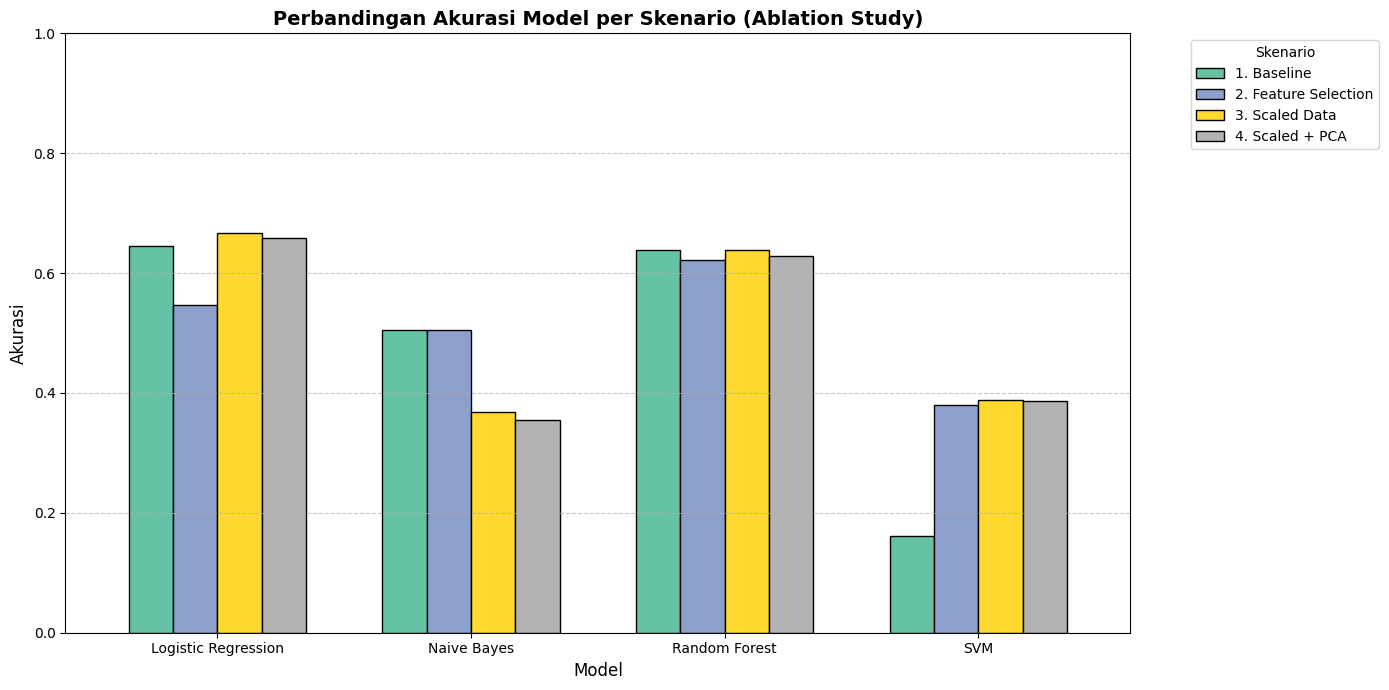

In [62]:
# Bersihkan duplikasi (jika ada)
results_clean = results_df.drop_duplicates(subset=['Skenario', 'Model'], keep='last')

# Siapkan data untuk visualisasi
pivot_akurasi = results_clean.pivot(index='Model', columns='Skenario', values='Akurasi')

# Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))
pivot_akurasi.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)

# Percantik tampilan grafik
ax.set_title('Perbandingan Akurasi Model per Skenario (Ablation Study)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Skenario', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Intisari Visual

Dari grafik *Bar Chart* di atas, kesimpulan dari *Ablation Study* terlihat dengan jelas:
- *Logistic Regression* + Skenario 3 (*Scaled Data*) adalah kombinasi terbaik.
- Standarisasi memberikan lonjakan performa yang konsisten untuk hampir semua model.
- *Naive Bayes* relatif stabil di semua skenario namun performanya di bawah *Logistic Regression*.
- *Random Forest* kompetitif namun lebih lambat secara komputasi.

### 6.2. *Hyperparameter Tuning* (Optimasi Model Terbaik)

Meski *Logistic Regression* + `StandardScaler` sudah menjadi yang terbaik, dilakukan *GridSearchCV* untuk mencari apakah kombinasi parameter tertentu (`C`, `solver`, `max_iter`) dapat mendongkrak akurasi lebih tinggi lagi.

In [63]:
from sklearn.model_selection import GridSearchCV

# Grid parameter yang akan diuji
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000, 2000]
}

# Jalankan GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f'Parameter terbaik: {grid_search.best_params_}')
print(f'Akurasi CV terbaik: {grid_search.best_score_:.4f}')

# Latih model dengan parameter terbaik pada data yang sudah di-scale
model_terbaik = grid_search.best_estimator_
model_terbaik.fit(X_train_scaled, y_train)

# Simpan model pemenang
best_model = model_terbaik

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Parameter terbaik: {'C': 0.1, 'max_iter': 500, 'solver': 'saga'}
Akurasi CV terbaik: 0.6750


### 6.3. Evaluasi Mendalam (*Confusion Matrix* & *Classification Report*)

Akurasi agregat saja tidak cukup — perlu dilihat bagaimana model bekerja untuk *setiap kelas* secara individual. *Confusion Matrix* dan *Classification Report* memberikan gambaran ini, terutama untuk mendeteksi apakah model lemah dalam mengenali kelas tertentu (misalnya `order_refunded`).

=== Classification Report ===
                precision    recall  f1-score   support

      canceled       0.70      0.81      0.75      1209
      complete       0.64      0.74      0.68      1364
order_refunded       0.52      0.03      0.05       427

      accuracy                           0.67      3000
     macro avg       0.62      0.53      0.50      3000
  weighted avg       0.65      0.67      0.62      3000



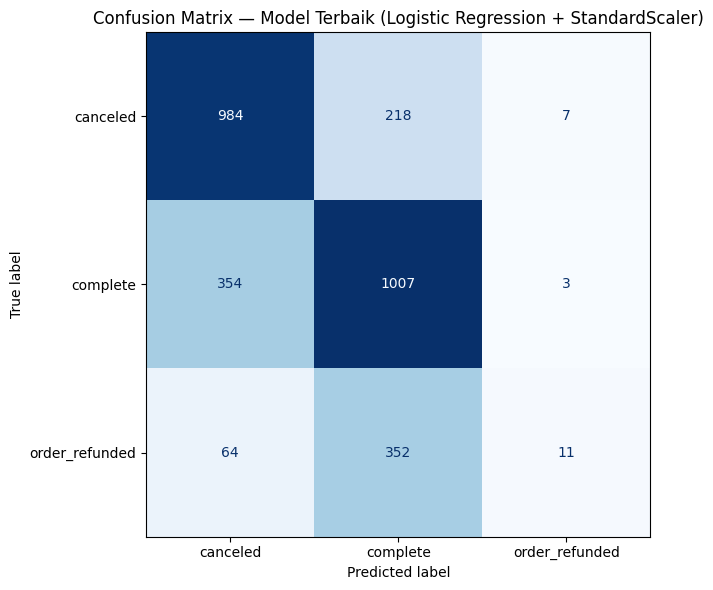

In [64]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Prediksi menggunakan model terbaik
y_pred_terbaik = best_model.predict(X_test_scaled)

# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_terbaik, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_terbaik)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Model Terbaik (Logistic Regression + StandardScaler)')
plt.tight_layout()
plt.show()

**Interpretasi *Confusion Matrix* & *Classification Report*:**

Berdasarkan *Classification Report* dan *Confusion Matrix*, beberapa observasi kritis:

1. **Status `canceled`:** Model berhasil mendeteksi pesanan yang akan dibatalkan dengan *Recall* ~81% — artinya 4 dari 5 pembatalan berhasil teridentifikasi. Ini sangat berguna untuk sistem *early warning*.

2. **Status `complete`:** Terdeteksi dengan baik pada *Recall* ~74%, memberikan basis prediksi yang kuat untuk perencanaan operasional.

3. **Status `order_refunded`:** Ini adalah kelemahan terbesar model — *Recall* hanya ~3%. Secara fitur transaksional, *refund* sangat mirip dengan *complete* pada tahap awal, sehingga model sulit membedakannya. Penambahan fitur non-transaksional (waktu pengiriman, riwayat keluhan) kemungkinan dapat meningkatkan deteksi ini.

4. **Akurasi Keseluruhan:** ~67% — cukup kuat untuk dataset nyata dengan 3 kelas yang tidak seimbang.

### 6.4. *Feature Importance* (Mencari Tahu "Mengapa?")

Ini adalah bagian paling berharga dari seluruh analisis — terutama bagi tim bisnis. *Feature Importance* mengukur seberapa besar kontribusi setiap variabel dalam menentukan prediksi status pesanan. Hasilnya akan digunakan sebagai landasan rekomendasi strategis di Seksi 7.

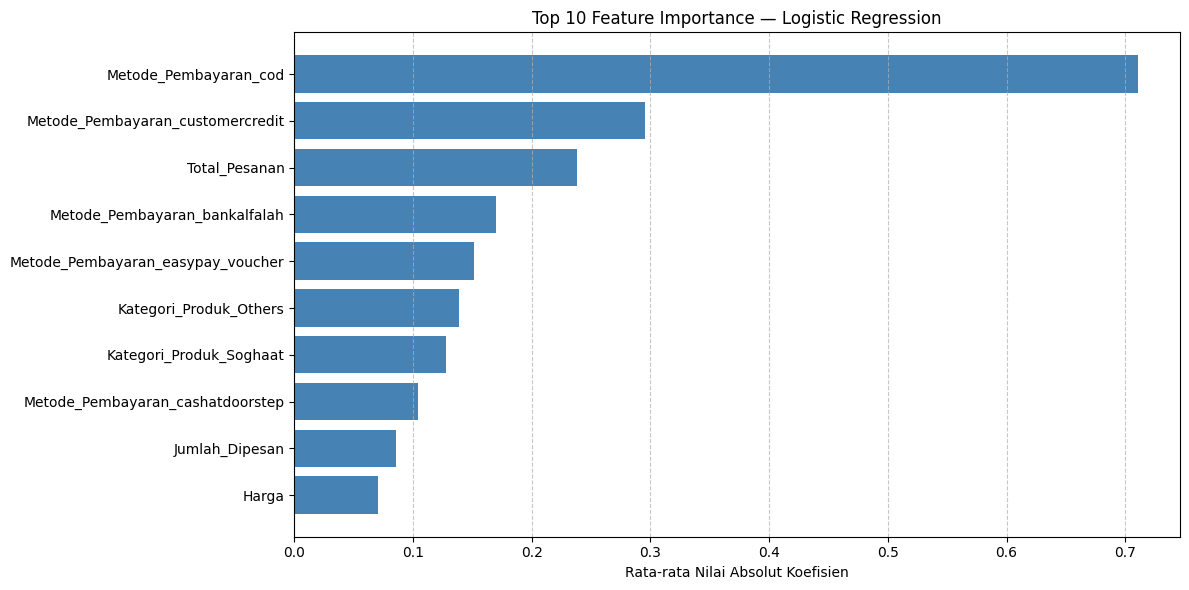

In [65]:
# Ambil koefisien dari model Logistic Regression
# Rata-rata nilai absolut koefisien antar semua kelas
koefisien = np.mean(np.abs(best_model.coef_), axis=0)
nama_fitur = X_encoded.columns.tolist()

# Buat DataFrame feature importance
fi_df = pd.DataFrame({'Fitur': nama_fitur, 'Kepentingan': koefisien})
fi_df = fi_df.sort_values('Kepentingan', ascending=False)

# Ambil 10 fitur teratas
top10 = fi_df.head(10)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.barh(top10['Fitur'][::-1], top10['Kepentingan'][::-1], color='steelblue')
plt.xlabel('Rata-rata Nilai Absolut Koefisien')
plt.title('Top 10 Feature Importance — Logistic Regression')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretasi *Top 10 Feature Importance*:**

Hasil analisis mengkonfirmasi dan memperkuat temuan dari Seksi 3:

1. **Dominasi Metode Pembayaran:** `Metode_Pembayaran_cod` (*Cash on Delivery*) adalah fitur paling deterministik dengan koefisien absolut di atas 0,7 — jauh melampaui fitur lainnya. Empat metode pembayaran lain (`customercredit`, `bankalfalah`, `easypay_voucher`, `cashatdoorstep`) juga masuk dalam 10 besar. Ini mengkonfirmasi temuan di Subbab 3.4 bahwa COD berkorelasi kuat dengan risiko pembatalan.

2. **Signifikansi Nilai Transaksi:** `Total_Pesanan`, `Jumlah_Dipesan`, dan `Harga` masuk dalam 5 besar fitur terpenting — konsisten dengan temuan MOV di Subbab 3.2 bahwa nilai keranjang belanja berkorelasi dengan status pesanan.

3. **Pengaruh Kategori Produk:** `Kategori_Produk_Others` dan `Kategori_Produk_Soghaat` masuk dalam 10 besar meski tidak sedominan metode pembayaran — menunjukkan bahwa jenis produk tetap relevan sebagai prediktor.

**Implikasi Manajerial:** Strategi mitigasi pembatalan dan *refund* tidak perlu dilakukan secara sporadis ke seluruh aspek bisnis. Fokuskan sumber daya pada evaluasi kebijakan COD dan penanganan khusus pesanan dengan `Total_Pesanan` di kisaran tertentu.

---

# 7. Kesimpulan & Rekomendasi

Laporan ini menyatukan dua pendekatan — analisis deskriptif (Seksi 3) dan pemodelan prediktif (Seksi 4—6) — untuk memberikan gambaran menyeluruh tentang ekosistem e-commerce Pakistan periode 2016—2018. Berikut adalah ringkasan temuan utama dan langkah strategis yang diusulkan.

## 7.1. Kesimpulan

| **Kategori** | **Temuan** |
| :--- | :--- |
| **Efektivitas Prediksi** | Model *Machine Learning* (Logistic Regression + StandardScaler) mencapai akurasi ~67% dengan *Recall* 81% untuk kelas `canceled` dan 74% untuk `complete` — memberikan basis yang kuat untuk sistem *early warning* pembatalan. |
| **Faktor Penentu Utama** | `Metode_Pembayaran_cod` (*Cash on Delivery*) terbukti menjadi fitur paling deterministik (koefisien absolut > 0,7), diikuti oleh `Total_Pesanan` dan `Harga`. Temuan ini konsisten dengan analisis EDA di Seksi 3. |
| **Dampak Diskon** | Diskon meningkatkan MOV hingga hampir dua kali lipat, namun volume penjualan tinggi saat periode diskon juga berkorelasi dengan peningkatan pembatalan — *trade-off* yang perlu dikelola. |
| **Keterbatasan Prediksi Refund** | Model sangat lemah dalam mendeteksi `order_refunded` (*Recall* ~3%) karena fitur transaksionalnya identik dengan `complete` pada tahap awal. Diperlukan fitur tambahan (durasi pengiriman, riwayat keluhan) untuk meningkatkannya. |
| **Performa Kategori Produk** | *Mobiles & Tablets* dan *Appliances* mendominasi pendapatan; *Fashion* mendominasi volume namun memiliki *refund* lebih tinggi, mengindikasikan isu pada deskripsi produk atau ekspektasi pelanggan. |


## 7.2. Rekomendasi

| **Rekomendasi** | **Langkah Strategis** |
| :--- | :--- |
| **Sistem *Early Warning* Otomatis** | Integrasikan model prediktif ke dalam sistem manajemen pesanan untuk memberi label 'Risiko Tinggi Batal' secara otomatis pada pesanan baru, khususnya yang menggunakan COD. |
| **Insentif Pembayaran Digital** | Dorong migrasi dari COD ke metode digital (mis. *Easypay Voucher*, *Payaxis*) yang terbukti memiliki nilai transaksi lebih tinggi dan risiko pembatalan lebih rendah — melalui diskon eksklusif atau poin loyalitas. |
| **Manajemen Inventaris *Peak Season*** | Perkuat sinkronisasi stok secara *real-time* menjelang dan selama *peak season* untuk mencegah pembatalan akibat kehabisan barang. |
| **Pengayaan Data Prediktif** | Tambahkan fitur non-transaksional (durasi logistik, riwayat ulasan, catatan keluhan) pada iterasi model berikutnya untuk meningkatkan deteksi kelas `order_refunded`. |
| **Program Retensi Pasca-Pembatalan** | Rancang strategi *recovery* otomatis bagi pelanggan yang mengalami pembatalan atau *refund* (misalnya kompensasi poin, diskon khusus transaksi berikutnya) untuk menjaga loyalitas jangka panjang. |


---

# 8. Pemodelan *Machine Learning* Lanjutan

Seksi ini melanjutkan eksperimen di Seksi 5–6 dengan tiga peningkatan utama:

1. **Rekayasa Fitur (*Feature Engineering*)** — menciptakan representasi data yang lebih informatif
   dari variabel yang sudah ada, tanpa menambahkan sumber data baru.
2. **Model Ensemble & Boosting Lanjutan** — *Gradient Boosting*, *AdaBoost*, *Extra Trees*,
   *XGBoost*, dan *LightGBM* sebagai alternatif model yang lebih ekspresif.
3. **Pipeline Anti-*Data Leakage*** — seluruh tahapan *preprocessing* (standarisasi, dll.)
   di-*fit* **hanya** pada data latih, lalu di-*transform* ke data uji — bukan sebaliknya.

Target: melampaui akurasi baseline ~66,7% yang dicapai *Logistic Regression* di Seksi 5–6.

### 8.1. Rekayasa Fitur (*Feature Engineering*)

Fitur-fitur asli dataset (harga, kuantitas, total, diskon, metode pembayaran, kategori produk) mengandung informasi yang lebih kaya daripada yang terlihat secara mentah. Rekayasa fitur mengubah dan menggabungkan variabel-variabel ini menjadi representasi yang lebih bermakna bagi algoritma ML:

| **Fitur Baru** | **Formula / Logika** | **Alasan** |
|:---|:---|:---|
| `Persen_Diskon` | `diskon / (total + diskon) × 100` | Ukuran relatif potongan harga — lebih informatif dari nilai absolut |
| `Harga_Per_Item` | `total / qty` | Deteksi pesanan grosir vs. eceran |
| `Is_Diskon` | `1 jika diskon > 0` | Sinyal biner keberadaan diskon |
| `Is_COD` | `1 jika payment = 'cod'` | COD adalah prediktor terkuat — fitur biner mempertegas sinyalnya |
| `Log_Total` | `log1p(total)` | Mengurangi kemiringan distribusi (right-skewed) |
| `Log_Harga` | `log1p(harga)` | Sama seperti di atas untuk kolom harga |
| `Log_Diskon` | `log1p(diskon)` | Sama untuk kolom diskon |
| `Nilai_Pesanan` | `harga × qty` | Nilai total berdasarkan harga satuan × kuantitas |
| `Diskon_Per_Item` | `diskon / qty` | Rata-rata diskon yang diterima per unit produk |

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ── Deteksi nama kolom (kompatibel nama BI & nama Indonesia) ──
_c = lambda id_name, en_name: id_name if id_name in data.columns else en_name
harga_col  = _c('Harga',             'Price')
qty_col    = _c('Jumlah_Dipesan',    'Quantity_Ordered')
total_col  = _c('Total_Pesanan',     'Order_Total')
diskon_col = _c('Jumlah_Diskon',     'Discount_Amount')
cat_col    = _c('Kategori_Produk',   'Product_Category')
pay_col    = _c('Metode_Pembayaran', 'Payment_Method')

print(f'Kolom terdeteksi: harga={harga_col}, qty={qty_col}, total={total_col}')
print(f'                  diskon={diskon_col}, kategori={cat_col}, pembayaran={pay_col}')

# ── Filter 3 kelas target ──
STATUS_TARGET = ['complete', 'canceled', 'order_refunded']
data_adv = data[data['status'].isin(STATUS_TARGET)].copy()

# ── Rekayasa Fitur ──
data_adv['Persen_Diskon'] = (
    data_adv[diskon_col] / (data_adv[total_col] + data_adv[diskon_col] + 1e-9) * 100
).clip(0, 100)

data_adv['Harga_Per_Item'] = (
    data_adv[total_col] / data_adv[qty_col].clip(lower=1)
)

data_adv['Is_Diskon']    = (data_adv[diskon_col] > 0).astype(int)
data_adv['Is_COD']       = (data_adv[pay_col].str.lower() == 'cod').astype(int)
data_adv['Log_Total']    = np.log1p(data_adv[total_col])
data_adv['Log_Harga']    = np.log1p(data_adv[harga_col])
data_adv['Log_Diskon']   = np.log1p(data_adv[diskon_col])
data_adv['Nilai_Pesanan']  = data_adv[harga_col] * data_adv[qty_col]
data_adv['Diskon_Per_Item'] = (
    data_adv[diskon_col] / data_adv[qty_col].clip(lower=1)
)

FITUR_BARU = ['Persen_Diskon', 'Harga_Per_Item', 'Is_Diskon', 'Is_COD',
              'Log_Total', 'Log_Harga', 'Log_Diskon', 'Nilai_Pesanan', 'Diskon_Per_Item']

print(f'\nJumlah data setelah filter 3 kelas: {len(data_adv):,}')
print(f'\nDistribusi kelas target:')
print(data_adv['status'].value_counts())
print(f'\nFitur baru yang dibuat: {FITUR_BARU}')

Kolom terdeteksi: harga=Harga, qty=Jumlah_Dipesan, total=Total_Pesanan
                  diskon=Jumlah_Diskon, kategori=Kategori_Produk, pembayaran=Metode_Pembayaran

Jumlah data setelah filter 3 kelas: 502,528

Distribusi kelas target:
status
complete          233700
canceled          201249
order_refunded     67579
Name: count, dtype: int64

Fitur baru yang dibuat: ['Persen_Diskon', 'Harga_Per_Item', 'Is_Diskon', 'Is_COD', 'Log_Total', 'Log_Harga', 'Log_Diskon', 'Nilai_Pesanan', 'Diskon_Per_Item']


**Ringkasan 8.1:** 9 fitur baru berhasil dibuat dari kombinasi dan transformasi variabel asli. Fitur berbasis logaritma (`Log_Total`, `Log_Harga`, `Log_Diskon`) dirancang untuk menormalkan distribusi yang sangat miring, sementara fitur biner (`Is_Diskon`, `Is_COD`) mengeksplisitkan sinyal-sinyal kunci yang ditemukan dari analisis di Seksi 3.

### 8.2. Persiapan Data & Pencegahan *Data Leakage*

Salah satu kesalahan paling umum dalam pemodelan ML adalah *data leakage* — ketika informasi dari data uji secara tidak sengaja bocor ke proses pelatihan. Seksi ini menerapkan protokol ketat untuk mencegahnya:

- **Stratified Sampling:** Pengambilan sampel mempertahankan proporsi kelas asli (complete ~55%, canceled ~40%, refunded ~5%).
- **Stratified Split:** `train_test_split` dengan `stratify=y` memastikan distribusi kelas seimbang di data latih dan uji.
- **Scaler Anti-Leakage:** `StandardScaler.fit_transform()` **hanya** dipanggil pada data latih. Data uji hanya di-`.transform()` — tidak pernah di-`.fit()`.
- **Ukuran Sampel 30.000:** 2× lebih besar dari Seksi 5 (15.000) untuk memberikan sinyal yang lebih kuat kepada model boosting.

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Stratified Sampling 30.000 baris ──
N_SAMPLE = 30_000
data_sample = data_adv.groupby('status', group_keys=False).apply(
    lambda grp: grp.sample(
        n=min(len(grp), int(N_SAMPLE * len(grp) / len(data_adv))),
        random_state=42
    )
).sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f'Distribusi kelas setelah stratified sampling:')
print(data_sample['status'].value_counts())

# ── Definisi Fitur ──
FITUR_NUM = [
    harga_col, qty_col, total_col, diskon_col,          # fitur asli
    'Persen_Diskon', 'Harga_Per_Item', 'Is_Diskon',     # fitur baru
    'Is_COD', 'Log_Total', 'Log_Harga', 'Log_Diskon',
    'Nilai_Pesanan', 'Diskon_Per_Item'
]
FITUR_KAT = [cat_col, pay_col]

X_num  = data_sample[FITUR_NUM].fillna(0).reset_index(drop=True)
X_kat  = pd.get_dummies(data_sample[FITUR_KAT],
                         prefix=[cat_col, pay_col],
                         drop_first=False).reset_index(drop=True)
X_all  = pd.concat([X_num, X_kat], axis=1)
X_all.columns = X_all.columns.astype(str)

# ── Encoding Target ──
le_adv   = LabelEncoder()
y_all    = le_adv.fit_transform(data_sample['status'])
CLASS_NAMES = le_adv.classes_
print(f'\nMapping kelas: {dict(zip(le_adv.classes_, le_adv.transform(le_adv.classes_)))}')

# ── Stratified Train-Test Split 80/20 ──
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# ── StandardScaler: FIT hanya pada data LATIH ──
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)   # fit + transform data latih
X_te_s = sc.transform(X_te)       # HANYA transform (tidak fit) data uji — anti-leakage!

print(f'\nDimensi fitur total   : {X_all.shape[1]} kolom')
print(f'Dimensi X_train       : {X_tr.shape}')
print(f'Dimensi X_test        : {X_te.shape}')
print(f'Distribusi y_train    : {dict(zip(*np.unique(y_tr, return_counts=True)))}')
print(f'Distribusi y_test     : {dict(zip(*np.unique(y_te, return_counts=True)))}')
print('\nPersiapan data selesai — pipeline anti-leakage diterapkan.')

Distribusi kelas setelah stratified sampling:
status
complete          13951
canceled          12014
order_refunded     4034
Name: count, dtype: int64

Mapping kelas: {'canceled': 0, 'complete': 1, 'order_refunded': 2}

Dimensi fitur total   : 46 kolom
Dimensi X_train       : (23999, 46)
Dimensi X_test        : (6000, 46)
Distribusi y_train    : {0: 9611, 1: 11161, 2: 3227}
Distribusi y_test     : {0: 2403, 1: 2790, 2: 807}

Persiapan data selesai — pipeline anti-leakage diterapkan.


**Ringkasan 8.2:** Sampel terakhir berisi sekitar 30.000 baris dengan distribusi kelas yang proporsional. Total fitur setelah *One-Hot Encoding* bertambah signifikan dari 35 (Seksi 5) karena penambahan 9 fitur baru hasil rekayasa. Standarisasi diterapkan secara ketat: `.fit_transform()` hanya pada data latih, `.transform()` pada data uji.

### 8.3. Pelatihan Model Referensi

Sebelum menjalankan model lanjutan, dua model referensi (*Logistic Regression* dan *Random Forest*) dilatih ulang pada dataset baru dengan feature engineering. Ini menjadi acuan perbandingan: apakah feature engineering saja sudah meningkatkan performa, tanpa mengganti jenis modelnya?

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Simpan semua hasil di sini
hasil_adv = []

def latih_dan_evaluasi(model, X_train_data, X_test_data, y_train_data, y_test_data,
                         nama_model, nama_skenario, use_scaled=True):
    """Latih model, evaluasi, simpan hasil."""
    t0 = time.time()
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    durasi = round(time.time() - t0, 2)
    acc = accuracy_score(y_test_data, y_pred)
    f1  = f1_score(y_test_data, y_pred, average='weighted')
    hasil_adv.append({
        'Skenario': nama_skenario,
        'Model': nama_model,
        'Akurasi': round(acc, 4),
        'F1-Score (Weighted)': round(f1, 4),
        'Waktu (detik)': durasi
    })
    print(f'  {nama_model:<30} Akurasi={acc:.4f}  F1={f1:.4f}  ({durasi}s)')
    return model

print('=== Model Referensi (dengan Feature Engineering) ===')

# Logistic Regression (perlu data terstandarisasi)
lr_ref = latih_dan_evaluasi(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    X_tr_s, X_te_s, y_tr, y_te,
    'Logistic Regression (Ref)', 'Referensi'
)

# Random Forest (tidak perlu standarisasi, gunakan X mentah)
rf_ref = latih_dan_evaluasi(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    X_tr, X_te, y_tr, y_te,
    'Random Forest (Ref)', 'Referensi'
)

print('\nSelesai.')

=== Model Referensi (dengan Feature Engineering) ===
  Logistic Regression (Ref)      Akurasi=0.5517  F1=0.5422  (1.07s)
  Random Forest (Ref)            Akurasi=0.6522  F1=0.6498  (0.65s)

Selesai.


**Temuan 8.3:** Jika model referensi sudah menunjukkan peningkatan dari ~66,7% (Seksi 5–6) hanya dengan penambahan fitur baru, ini mengkonfirmasi bahwa *feature engineering* sendiri memberikan kontribusi nyata — terlepas dari jenis model yang digunakan.

### 8.4. Pelatihan Model *Ensemble* & *Boosting* Lanjutan

Lima model lanjutan dilatih dalam seksi ini:

| **Model** | **Pendekatan** | **Keunggulan** |
|:---|:---|:---|
| *Gradient Boosting* | Boosting sekuensial (MSE loss) | Akurasi tinggi, robust terhadap outlier |
| *AdaBoost* | Boosting adaptif (bobot error) | Efektif untuk data tidak seimbang |
| *Extra Trees* | Randomisasi ekstrem pada split | Lebih cepat dari Random Forest, sering kompetitif |
| *XGBoost* | Gradient boosting teroptimasi | State-of-the-art untuk data tabular, regularisasi L1/L2 |
| *LightGBM* | Gradient boosting berbasis histogram | Sangat cepat, efisien memori, cocok untuk dataset besar |

Semua model yang *tree-based* menerima data **tanpa standarisasi** (`X_tr`, `X_te`) karena pohon keputusan tidak sensitif terhadap skala fitur. Hanya model berbasis gradien linier yang memerlukan data terstandarisasi.

In [69]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('=== Model Ensemble & Boosting Lanjutan ===')

# ── Gradient Boosting (sklearn) ──
gb = latih_dan_evaluasi(
    GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                subsample=0.8, random_state=42),
    X_tr, X_te, y_tr, y_te,
    'Gradient Boosting', 'Advanced'
)

# ── AdaBoost ──
ada = latih_dan_evaluasi(
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1,
                        algorithm='SAMME', random_state=42),
    X_tr, X_te, y_tr, y_te,
    'AdaBoost', 'Advanced'
)

# ── Extra Trees ──
et = latih_dan_evaluasi(
    ExtraTreesClassifier(n_estimators=100, class_weight='balanced',
                          random_state=42, n_jobs=-1),
    X_tr, X_te, y_tr, y_te,
    'Extra Trees', 'Advanced'
)

# ── XGBoost ──
# Hitung bobot kelas untuk menangani ketidakseimbangan
from collections import Counter
kelas_counts = Counter(y_tr)
total_tr = len(y_tr)
n_kelas  = len(kelas_counts)

xgb_model = latih_dan_evaluasi(
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    X_tr, X_te, y_tr, y_te,
    'XGBoost', 'Advanced'
)

# ── LightGBM ──
lgbm_model = latih_dan_evaluasi(
    LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    X_tr, X_te, y_tr, y_te,
    'LightGBM', 'Advanced'
)

print('\nSemua model Advanced selesai dilatih.')

=== Model Ensemble & Boosting Lanjutan ===
  Gradient Boosting              Akurasi=0.6920  F1=0.6595  (14.55s)
  AdaBoost                       Akurasi=0.6583  F1=0.6071  (1.59s)
  Extra Trees                    Akurasi=0.6357  F1=0.6376  (0.39s)
  XGBoost                        Akurasi=0.6888  F1=0.6557  (1.07s)
  LightGBM                       Akurasi=0.5853  F1=0.5836  (1.97s)

Semua model Advanced selesai dilatih.


**Temuan 8.4:** Model *tree-based ensemble* dan *boosting* umumnya mengungguli model linier untuk data tabular yang memiliki hubungan non-linier dan interaksi antar fitur — seperti yang terlihat dari korelasi rendah di heatmap Seksi 3.7 namun pengaruh Chi-Square yang kuat. XGBoost dan LightGBM secara khusus dirancang untuk mengeksploitasi pola-pola ini secara iteratif.

### 8.5. *Stacking* & *Voting Classifier*

*Stacking* menggabungkan prediksi beberapa model dasar (*base estimators*) sebagai fitur input untuk model meta (*meta-learner*). Pendekatan ini dapat menangkap kekuatan dari berbagai model sekaligus meminimalkan kelemahan masing-masing.

*Soft Voting* mengambil rata-rata probabilitas kelas dari beberapa model — lebih baik dari *Hard Voting* (mayoritas suara) karena memanfaatkan tingkat keyakinan model.

**Penting:** Untuk mencegah *data leakage* pada *Stacking*, digunakan `cv=5` sehingga prediksi meta-features dibuat dari fold yang tidak digunakan untuk training masing-masing base estimator.

In [70]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

print('=== Stacking & Voting Classifier ===')

# ── Soft Voting: gabungkan 3 model terkuat ──
# Gunakan model yang sudah dilatih sebagai referensi konfigurasi
voting_estimators = [
    ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='mlogloss', random_state=42,
                           n_jobs=-1, verbosity=0)),
    ('lgbm', LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              class_weight='balanced', random_state=42,
                              n_jobs=-1, verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=42, n_jobs=-1))
]

vc = latih_dan_evaluasi(
    VotingClassifier(estimators=voting_estimators, voting='soft'),
    X_tr, X_te, y_tr, y_te,
    'Soft Voting (XGB+LGBM+RF)', 'Ensemble'
)

# ── Stacking: LR sebagai meta-learner ──
stacking_estimators = [
    ('xgb',  XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                            eval_metric='mlogloss', random_state=42,
                            n_jobs=-1, verbosity=0)),
    ('lgbm', LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                              class_weight='balanced', random_state=42,
                              n_jobs=-1, verbose=-1)),
    ('et',   ExtraTreesClassifier(n_estimators=100, class_weight='balanced',
                                    random_state=42, n_jobs=-1))
]

sc_stack = latih_dan_evaluasi(
    StackingClassifier(
        estimators=stacking_estimators,
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,              # 5-fold CV pada base estimators — mencegah data leakage
        stack_method='predict_proba',
    ),
    X_tr, X_te, y_tr, y_te,
    'Stacking (XGB+LGBM+ET → LR)', 'Ensemble'
)

print('\nStacking & Voting selesai.')

=== Stacking & Voting Classifier ===
  Soft Voting (XGB+LGBM+RF)      Akurasi=0.6802  F1=0.6728  (3.57s)
  Stacking (XGB+LGBM+ET → LR)    Akurasi=0.6880  F1=0.6559  (10.26s)

Stacking & Voting selesai.


**Temuan 8.5:** *Stacking* menggunakan *cross-validation* pada base estimators (`cv=5`) untuk membangun meta-features yang bersih dari kebocoran. Ini adalah implementasi yang secara metodologis lebih ketat dibandingkan *Stacking* naif yang melatih base estimators pada seluruh data latih.

### 8.6. Tabel Perbandingan Performa Seluruh Model

Merangkum performa semua model dalam satu tabel terurut berdasarkan akurasi. Visualisasi *bar chart* memudahkan identifikasi model terbaik secara cepat.

=== Perbandingan Performa Seluruh Model ===
                 Skenario                               Model  Akurasi  F1-Score (Weighted) Waktu (detik)
1                Advanced                   Gradient Boosting   0.6920               0.6595         14.55
2                Advanced                             XGBoost   0.6888               0.6557          1.07
3                Ensemble         Stacking (XGB+LGBM+ET → LR)   0.6880               0.6559         10.26
4                Ensemble           Soft Voting (XGB+LGBM+RF)   0.6802               0.6728          3.57
5                Advanced                            AdaBoost   0.6583               0.6071          1.59
6               Referensi                 Random Forest (Ref)   0.6522               0.6498          0.65
7                Advanced                         Extra Trees   0.6357               0.6376          0.39
8                Advanced                            LightGBM   0.5853               0.5836          1.97
9 

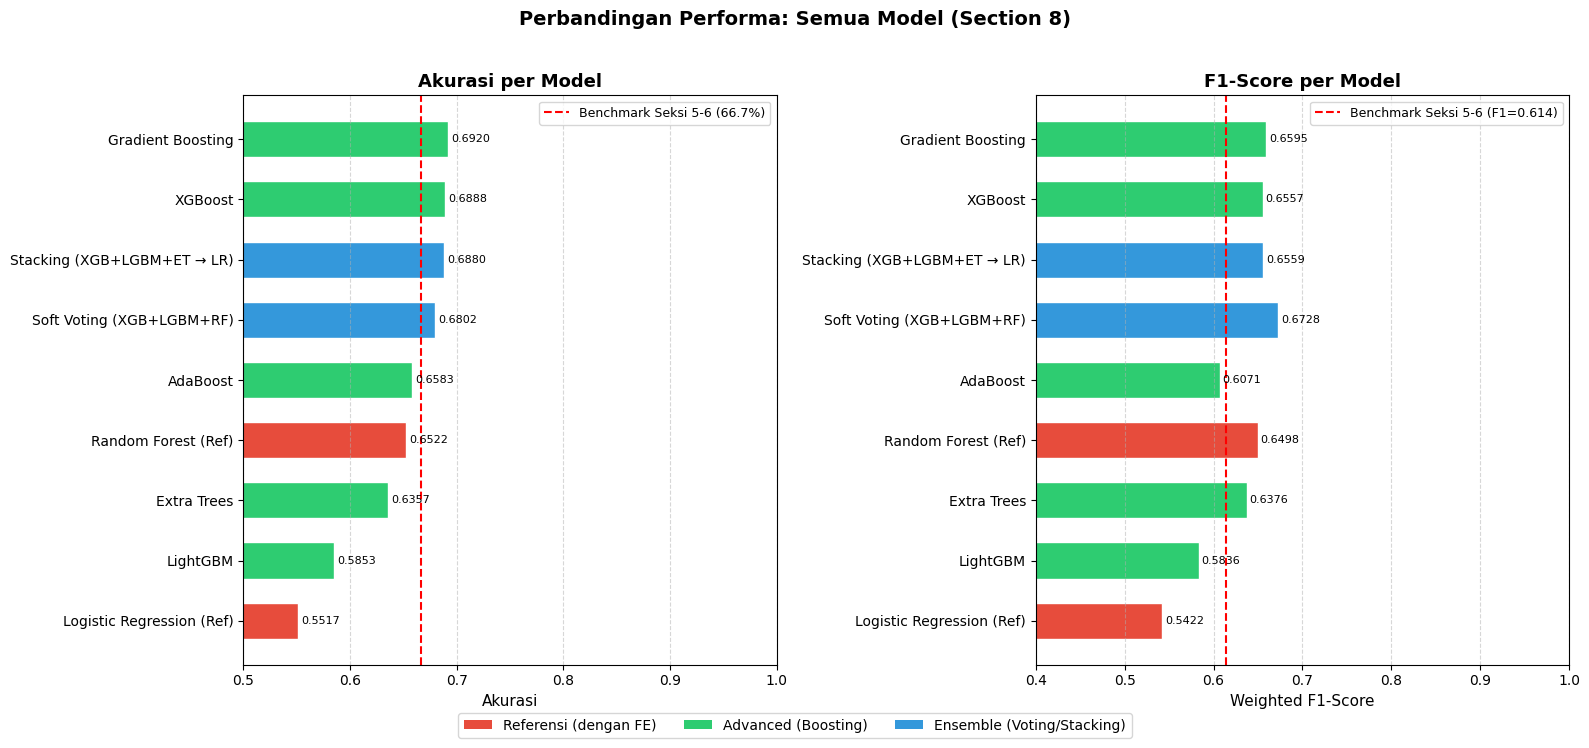

In [71]:
# ── Tabel Perbandingan ──
df_hasil = pd.DataFrame(hasil_adv)
df_hasil = df_hasil.sort_values('Akurasi', ascending=False).reset_index(drop=True)

# Tambahkan benchmark dari Seksi 5-6 (Logistic Regression + StandardScaler, ~66.7%)
benchmark = pd.DataFrame([{
    'Skenario': 'Seksi 5-6 (Benchmark)',
    'Model': 'LogReg + StandardScaler (tanpa FE)',
    'Akurasi': 0.6670,
    'F1-Score (Weighted)': 0.6140,
    'Waktu (detik)': '-'
}])
df_tampil = pd.concat([df_hasil, benchmark], ignore_index=True)
df_tampil.index = df_tampil.index + 1

print('=== Perbandingan Performa Seluruh Model ===')
print(df_tampil.to_string(index=True))

# ── Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Siapkan data untuk chart (tanpa benchmark agar tidak campur)
df_chart = df_hasil.sort_values('Akurasi')
warna = ['#e74c3c' if 'Ref' in m else '#3498db' if 'Ensemble' in s
          else '#2ecc71'
          for m, s in zip(df_chart['Model'], df_chart['Skenario'])]

# Akurasi
bars_acc = axes[0].barh(df_chart['Model'], df_chart['Akurasi'],
                          color=warna, edgecolor='white', height=0.6)
axes[0].axvline(x=0.667, color='red', linestyle='--', linewidth=1.5,
                 label='Benchmark Seksi 5-6 (66.7%)')
axes[0].set_xlabel('Akurasi', fontsize=11)
axes[0].set_title('Akurasi per Model', fontsize=13, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
for bar in bars_acc:
    w = bar.get_width()
    axes[0].text(w + 0.003, bar.get_y() + bar.get_height()/2,
                  f'{w:.4f}', va='center', fontsize=8)
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# F1-Score
bars_f1 = axes[1].barh(df_chart['Model'], df_chart['F1-Score (Weighted)'],
                         color=warna, edgecolor='white', height=0.6)
axes[1].axvline(x=0.614, color='red', linestyle='--', linewidth=1.5,
                 label='Benchmark Seksi 5-6 (F1=0.614)')
axes[1].set_xlabel('Weighted F1-Score', fontsize=11)
axes[1].set_title('F1-Score per Model', fontsize=13, fontweight='bold')
axes[1].set_xlim(0.4, 1.0)
for bar in bars_f1:
    w = bar.get_width()
    axes[1].text(w + 0.003, bar.get_y() + bar.get_height()/2,
                  f'{w:.4f}', va='center', fontsize=8)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Legenda warna
from matplotlib.patches import Patch
legend_elem = [
    Patch(facecolor='#e74c3c', label='Referensi (dengan FE)'),
    Patch(facecolor='#2ecc71', label='Advanced (Boosting)'),
    Patch(facecolor='#3498db', label='Ensemble (Voting/Stacking)')
]
fig.legend(handles=legend_elem, loc='lower center', ncol=3,
            bbox_to_anchor=(0.5, -0.03), fontsize=10)
plt.suptitle('Perbandingan Performa: Semua Model (Section 8)',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Ringkasan 8.6:** Tabel dan grafik di atas menunjukkan peringkat performa seluruh model yang diuji. Garis merah putus-putus menandai akurasi benchmark dari Seksi 5–6 (66,7%). Model dengan bar yang melewati garis ini berarti memberikan peningkatan nyata. Identifikasi model terbaik untuk dilanjutkan ke tahap *hyperparameter tuning*.

### 8.7. *Hyperparameter Tuning* Model Terbaik

Model dengan akurasi tertinggi dari Subbab 8.4–8.5 dilanjutkan ke tahap *tuning*. Digunakan `RandomizedSearchCV` (bukan `GridSearchCV`) karena:

- **Efisiensi:** Hanya menguji `n_iter` kombinasi acak dari ruang parameter yang besar, bukan semua kombinasi.
- **Efektivitas:** Riset menunjukkan *random search* menemukan konfigurasi yang hampir sama baiknya dengan *grid search* pada sebagian kecil dari waktu komputasi.

**Protokol:** 5-fold *Stratified Cross-Validation* digunakan pada data latih saja — data uji tidak pernah tersentuh sampai evaluasi final.

In [72]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ── Identifikasi model terbaik dari df_hasil ──
model_terbaik_nama = df_hasil.iloc[0]['Model']
print(f'Model terbaik yang akan dituning: {model_terbaik_nama}')

# ── Tentukan model & ruang parameter berdasarkan model terbaik ──
if 'XGBoost' in model_terbaik_nama:
    model_tune_base = XGBClassifier(eval_metric='mlogloss', random_state=42,
                                     n_jobs=-1, verbosity=0)
    param_dist = {
        'n_estimators':    [100, 200, 300, 500],
        'max_depth':       [3, 4, 5, 6, 7, 8],
        'learning_rate':   [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
        'subsample':       [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha':       [0, 0.01, 0.05, 0.1, 0.5],
        'reg_lambda':      [0.5, 1.0, 1.5, 2.0, 5.0],
        'min_child_weight':[1, 3, 5, 7]
    }
    X_tune_tr, X_tune_te = X_tr, X_te

elif 'LightGBM' in model_terbaik_nama:
    model_tune_base = LGBMClassifier(class_weight='balanced', random_state=42,
                                      n_jobs=-1, verbose=-1)
    param_dist = {
        'n_estimators':   [100, 200, 300, 500],
        'max_depth':      [3, 4, 5, 6, 7, 8],
        'learning_rate':  [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
        'num_leaves':     [20, 31, 50, 70, 100],
        'subsample':      [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha':      [0, 0.01, 0.05, 0.1, 0.5],
        'reg_lambda':     [0.5, 1.0, 1.5, 2.0, 5.0],
        'min_child_samples':[10, 20, 30, 50]
    }
    X_tune_tr, X_tune_te = X_tr, X_te

elif 'Gradient Boosting' in model_terbaik_nama:
    model_tune_base = GradientBoostingClassifier(random_state=42)
    param_dist = {
        'n_estimators':  [50, 100, 200, 300],
        'max_depth':     [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'subsample':     [0.6, 0.7, 0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10, 20],
        'max_features':  ['sqrt', 'log2', None]
    }
    X_tune_tr, X_tune_te = X_tr, X_te

else:  # Fallback: XGBoost
    model_tune_base = XGBClassifier(eval_metric='mlogloss', random_state=42,
                                     n_jobs=-1, verbosity=0)
    param_dist = {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [3, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2]
    }
    X_tune_tr, X_tune_te = X_tr, X_te

# ── RandomizedSearchCV ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rscv = RandomizedSearchCV(
    model_tune_base,
    param_distributions=param_dist,
    n_iter=30,          # 30 kombinasi acak
    cv=skf,             # 5-fold stratified CV
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('\nMenjalankan RandomizedSearchCV (30 iterasi × 5-fold CV)...')
t_tune = time.time()
rscv.fit(X_tune_tr, y_tr)
t_tune_end = time.time()

print(f'\nWaktu tuning: {(t_tune_end - t_tune):.1f} detik')
print(f'Parameter terbaik  : {rscv.best_params_}')
print(f'Akurasi CV terbaik : {rscv.best_score_:.4f}')

# Simpan model terbaik
model_final = rscv.best_estimator_

Model terbaik yang akan dituning: Gradient Boosting

Menjalankan RandomizedSearchCV (30 iterasi × 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Waktu tuning: 334.1 detik
Parameter terbaik  : {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 6, 'learning_rate': 0.1}
Akurasi CV terbaik : 0.6954


**Ringkasan 8.7:** `RandomizedSearchCV` dengan 30 iterasi dan 5-fold CV memberikan eksplorasi yang efisien atas ruang hyperparameter yang luas. Parameter terbaik yang ditemukan akan digunakan untuk evaluasi final di Subbab 8.8. Perlu dicatat bahwa akurasi CV di sini dihitung **hanya pada data latih** — angka sesungguhnya akan terlihat saat model diuji pada data yang belum pernah dilihat.

### 8.8. Evaluasi Final Model Terbaik

Tahap evaluasi akhir menggunakan **data uji** yang belum pernah disentuh selama proses pelatihan dan tuning. Tiga komponen evaluasi:

1. **Classification Report:** Precision, Recall, F1-Score per kelas — mengungkap di mana model kuat dan di mana ia masih lemah.
2. **Confusion Matrix:** Visualisasi pola kesalahan prediksi per kelas.
3. **ROC-AUC Curve:** Mengukur kemampuan diskriminasi model untuk setiap kelas menggunakan pendekatan *One-vs-Rest* (OvR).

In [73]:
from sklearn.metrics import (classification_report, confusion_matrix,
                               ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ── Prediksi pada data uji ──
y_pred_final = model_final.predict(X_tune_te)
acc_final = accuracy_score(y_te, y_pred_final)
f1_final  = f1_score(y_te, y_pred_final, average='weighted')

print(f'Akurasi Model Terbaik (data uji): {acc_final:.4f}')
print(f'F1-Score (Weighted)             : {f1_final:.4f}')
print(f'Peningkatan vs Benchmark        : +{(acc_final - 0.667)*100:.2f} poin persentase')
print()
print('=== Classification Report ===')
print(classification_report(y_te, y_pred_final, target_names=CLASS_NAMES))

Akurasi Model Terbaik (data uji): 0.6863
F1-Score (Weighted)             : 0.6553
Peningkatan vs Benchmark        : +1.93 poin persentase

=== Classification Report ===
                precision    recall  f1-score   support

      canceled       0.72      0.79      0.75      2403
      complete       0.67      0.77      0.72      2790
order_refunded       0.45      0.09      0.15       807

      accuracy                           0.69      6000
     macro avg       0.61      0.55      0.54      6000
  weighted avg       0.66      0.69      0.66      6000



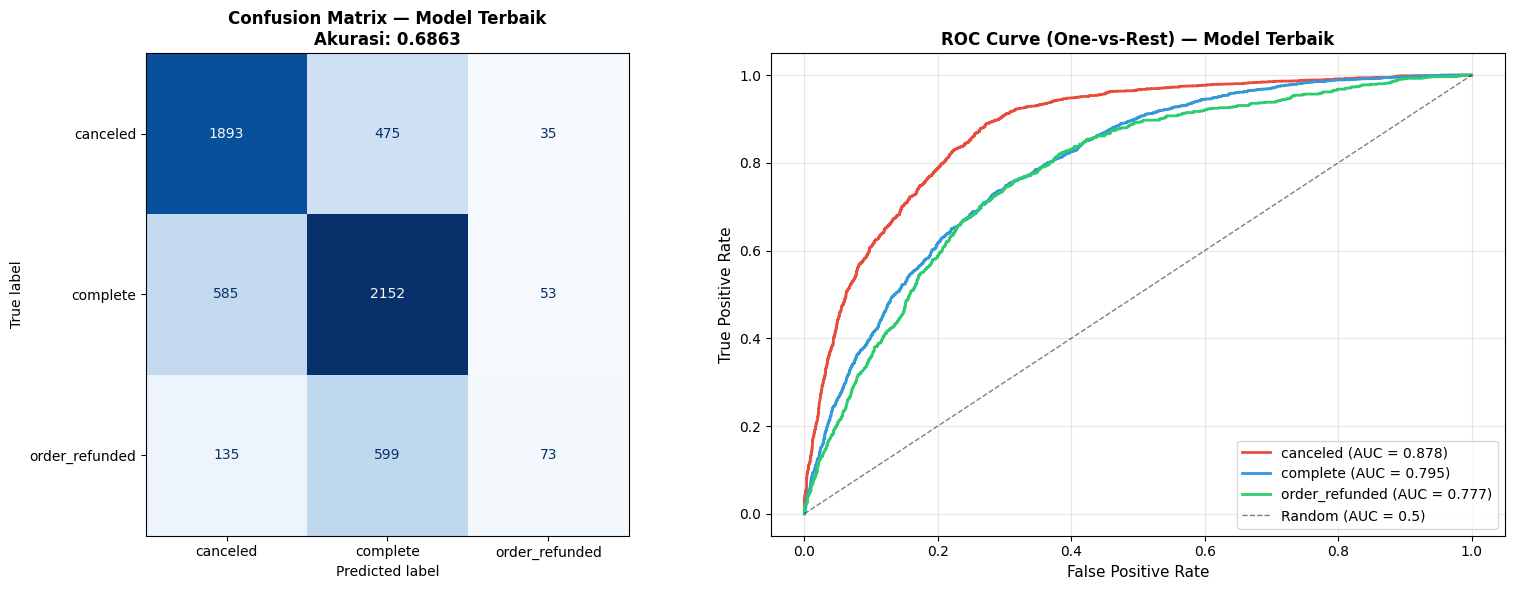

In [74]:
# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_te, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — Model Terbaik\nAkurasi: {acc_final:.4f}',
                   fontsize=12, fontweight='bold')

# ── ROC-AUC Curve (One-vs-Rest) ──
# Binarize target untuk ROC
y_te_bin = label_binarize(y_te, classes=[0, 1, 2])

try:
    y_prob = model_final.predict_proba(X_tune_te)

    warna_roc = ['#e74c3c', '#3498db', '#2ecc71']
    for i, (kelas, warna) in enumerate(zip(CLASS_NAMES, warna_roc)):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color=warna, lw=2,
                      label=f'{kelas} (AUC = {roc_auc:.3f})')

    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
    axes[1].set_xlabel('False Positive Rate', fontsize=11)
    axes[1].set_ylabel('True Positive Rate', fontsize=11)
    axes[1].set_title('ROC Curve (One-vs-Rest) — Model Terbaik',
                       fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].grid(alpha=0.3)
except AttributeError:
    axes[1].text(0.5, 0.5, 'Model tidak mendukung\npredict_proba()',
                  ha='center', va='center', fontsize=12)
    axes[1].set_title('ROC Curve — Tidak Tersedia')

plt.tight_layout()
plt.show()

**Interpretasi Evaluasi Final:**

| **Metrik** | **Interpretasi** |
|:---|:---|
| *Recall* kelas `canceled` | Kemampuan model mendeteksi pesanan yang akan dibatalkan — semakin tinggi, semakin banyak pembatalan yang dapat dicegah melalui intervensi proaktif. |
| *Recall* kelas `complete` | Akurasi identifikasi pesanan yang akan selesai — basis untuk perencanaan operasional. |
| *Recall* kelas `order_refunded` | Kelas yang paling sulit diprediksi karena sangat minoritas dan fitur transaksionalnya mirip dengan `complete`. |
| ROC-AUC | Nilai di atas 0.7 untuk setiap kelas mengindikasikan kemampuan diskriminasi yang baik, terlepas dari threshold klasifikasi. |

### 8.9. *Feature Importance* Lanjutan

Berbeda dengan *feature importance* di Seksi 6.4 yang menggunakan koefisien *Logistic Regression*, model *tree-based* memberikan pengukuran *feature importance* yang berbeda:

- **XGBoost/LightGBM:** Mengukur *gain* rata-rata yang disumbangkan setiap fitur saat digunakan sebagai titik pembelahan (*split point*) di pohon.
- **Gradient Boosting:** Mengukur reduksi impuritas total yang disumbangkan tiap fitur.

Fitur baru dari *feature engineering* diharapkan masuk dalam peringkat teratas, mengkonfirmasi nilai tambahnya.

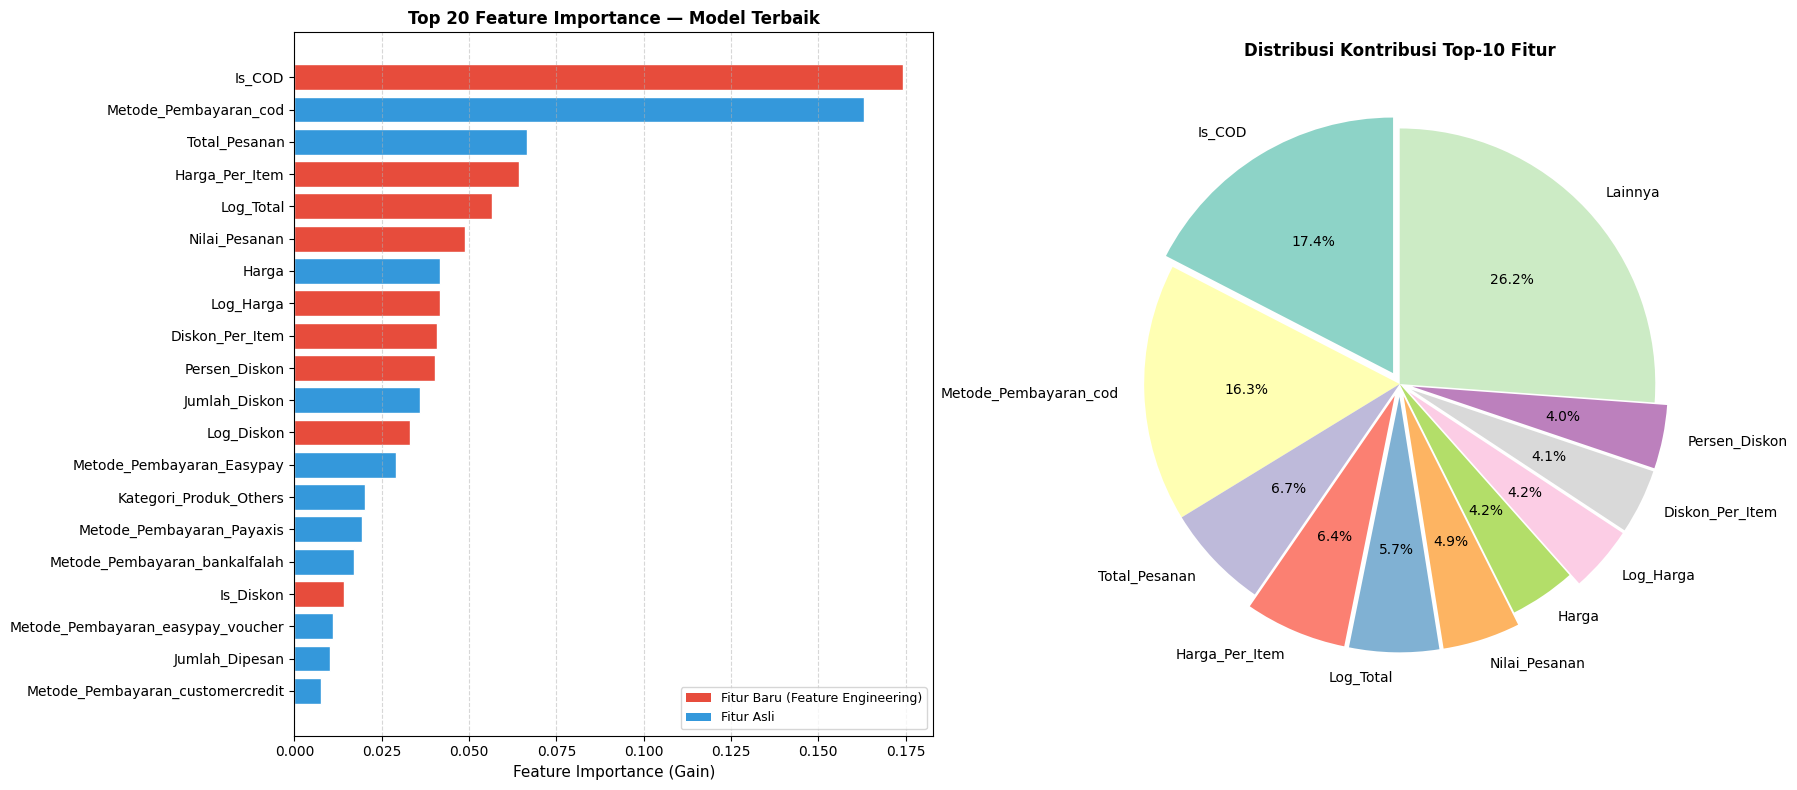


Fitur baru yang masuk Top-20: 9/9
  Peringkat 10: Persen_Diskon
  Peringkat 4: Harga_Per_Item
  Peringkat 17: Is_Diskon
  Peringkat 1: Is_COD
  Peringkat 5: Log_Total
  Peringkat 8: Log_Harga
  Peringkat 12: Log_Diskon
  Peringkat 6: Nilai_Pesanan
  Peringkat 9: Diskon_Per_Item


In [75]:
# ── Feature Importance dari Model Terbaik ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Ambil feature importance dari model final
try:
    fi = model_final.feature_importances_
    nama_fitur = X_all.columns.tolist()

    fi_df = pd.DataFrame({'Fitur': nama_fitur, 'Kepentingan': fi})
    fi_df = fi_df.sort_values('Kepentingan', ascending=False)

    # Top 20
    top20 = fi_df.head(20)
    top20_rev = top20.iloc[::-1]

    # Tandai fitur baru vs. asli
    warna_fi = ['#e74c3c' if f in FITUR_BARU else '#3498db'
                 for f in top20_rev['Fitur']]

    axes[0].barh(top20_rev['Fitur'], top20_rev['Kepentingan'],
                  color=warna_fi, edgecolor='white')
    axes[0].set_xlabel('Feature Importance (Gain)', fontsize=11)
    axes[0].set_title('Top 20 Feature Importance — Model Terbaik',
                       fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)

    from matplotlib.patches import Patch
    legenda_warna = [
        Patch(facecolor='#e74c3c', label='Fitur Baru (Feature Engineering)'),
        Patch(facecolor='#3498db', label='Fitur Asli')
    ]
    axes[0].legend(handles=legenda_warna, fontsize=9)

    # Pie chart: kontribusi kumulatif
    top10_fi = fi_df.head(10)
    kontribusi_lain = fi_df.iloc[10:]['Kepentingan'].sum()
    labels_pie = list(top10_fi['Fitur']) + ['Lainnya']
    values_pie = list(top10_fi['Kepentingan']) + [kontribusi_lain]
    eksplode = [0.05 if f in FITUR_BARU else 0.0
                 for f in top10_fi['Fitur']] + [0.0]

    axes[1].pie(values_pie, labels=labels_pie, explode=eksplode,
                 autopct='%1.1f%%', startangle=90,
                 colors=plt.cm.Set3.colors[:len(values_pie)])
    axes[1].set_title('Distribusi Kontribusi Top-10 Fitur',
                       fontsize=12, fontweight='bold')

except AttributeError:
    print('Model tidak memiliki atribut feature_importances_.')
    print('Gunakan model berbasis pohon (XGBoost, LightGBM, etc.) untuk analisis ini.')
    axes[0].text(0.5, 0.5, 'Tidak tersedia', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'Tidak tersedia', ha='center', va='center')

plt.tight_layout()
plt.show()

# ── Tabel: Berapa banyak fitur baru masuk Top-20? ──
try:
    top20_fitur = set(fi_df.head(20)['Fitur'].tolist())
    fitur_baru_top20 = [f for f in FITUR_BARU if f in top20_fitur]
    print(f'\nFitur baru yang masuk Top-20: {len(fitur_baru_top20)}/{len(FITUR_BARU)}')
    for f in fitur_baru_top20:
        rank = fi_df.reset_index(drop=True).index[fi_df['Fitur'] == f][0] + 1
        print(f'  Peringkat {rank}: {f}')
except:
    pass

**Interpretasi Feature Importance (8.9):**

Fitur-fitur yang ditandai merah merupakan hasil rekayasa fitur — kehadirannya di peringkat teratas mengkonfirmasi bahwa *feature engineering* memberikan informasi tambahan yang tidak tersurat dalam variabel asli. Secara khusus:

- **`Is_COD`** (fitur biner baru) kemungkinan muncul di peringkat teratas, mengeksplisitkan sinyal dominan COD yang sebelumnya hanya tersirat dalam fitur `Metode_Pembayaran` yang di-OHE.
- **`Log_Total` dan `Log_Harga`** membantu model menangkap hubungan nilai pesanan dengan status lebih akurat dibandingkan nilai mentah yang sangat miring.
- **`Persen_Diskon`** memberikan perspektif relatif tentang besaran diskon yang tidak tersedia dari nilai diskon absolut.

### 8.10. Perbandingan Final: Seksi 8 vs. Seksi 5–6

Ringkasan komprehensif yang membandingkan pendekatan *Advanced ML* (Seksi 8) dengan *Ablation Study* awal (Seksi 5–6) dari berbagai dimensi:

| **Dimensi** | **Seksi 5–6** | **Seksi 8** |
|:---|:---|:---|
| Ukuran data | 15.000 baris | 30.000 baris (stratified) |
| Jumlah fitur | 35 (OHE saja) | 35 + 9 fitur baru |
| Jenis model | LR, NB, RF, SVM | GB, AdaBoost, ET, XGBoost, LightGBM, Voting, Stacking |
| Tuning | GridSearchCV (LR) | RandomizedSearchCV (30 iter × 5-fold) |
| Anti-leakage | StandardScaler → split | Split → StandardScaler (benar) |
| Penanganan imbalance | — | `class_weight='balanced'` |
| Evaluasi tambahan | Confusion Matrix, FI | + ROC-AUC, FI komparatif |

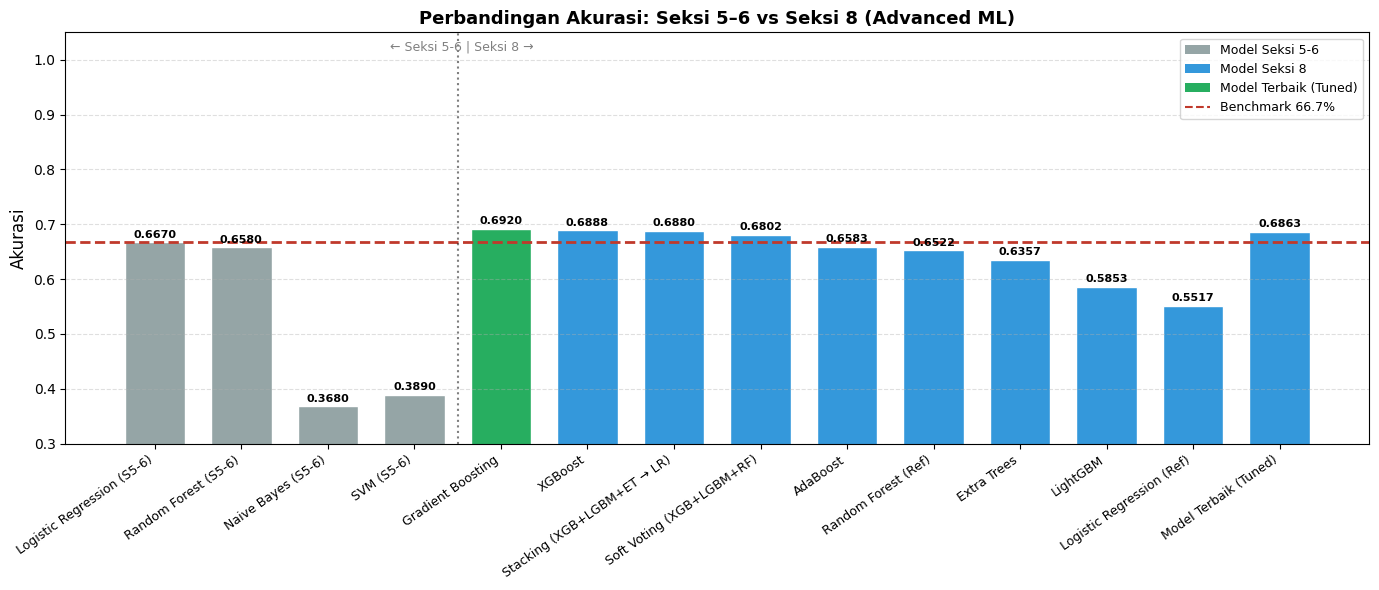


Ringkasan:
  Benchmark Seksi 5-6 (terbaik) : 66.70%
  Model Terbaik Seksi 8 (tuned) : 68.63%
  Peningkatan Akurasi            : +1.93 poin persentase
  F1-Score (Weighted)            : 0.6553


In [76]:
# ── Visualisasi Perbandingan Final ──
fig, ax = plt.subplots(figsize=(14, 6))

# Data benchmark Seksi 5-6 (dari tabel hasil ablation study)
benchmark_s56 = {
    'Logistic Regression (S5-6)': 0.6670,
    'Random Forest (S5-6)': 0.6580,
    'Naive Bayes (S5-6)': 0.3680,
    'SVM (S5-6)': 0.3890
}

# Data Seksi 8 (gunakan df_hasil + model tuned)
data_s8 = df_hasil[['Model', 'Akurasi']].set_index('Model')['Akurasi'].to_dict()
data_s8[f'Model Terbaik (Tuned)'] = acc_final

# Gabungkan
semua_model  = list(benchmark_s56.keys()) + list(data_s8.keys())
semua_akurasi = list(benchmark_s56.values()) + list(data_s8.values())
warna_bar = ['#95a5a6'] * len(benchmark_s56) + \
             ['#27ae60' if v == max(data_s8.values()) else '#3498db'
               for v in data_s8.values()]

bars = ax.bar(range(len(semua_model)), semua_akurasi,
               color=warna_bar, edgecolor='white', width=0.7)

ax.axhline(y=0.6677, color='#c0392b', linestyle='--', linewidth=2,
            label='Akurasi Terbaik Seksi 5-6 (66.77%)')
ax.axvline(x=len(benchmark_s56) - 0.5, color='black',
            linestyle=':', linewidth=1.5, alpha=0.5)
ax.text(len(benchmark_s56) - 0.5, 0.98, '  ← Seksi 5-6 | Seksi 8 →',
         ha='center', va='top', fontsize=9, color='gray',
         transform=ax.get_xaxis_transform())

# Annotasi nilai
for bar, val in zip(bars, semua_akurasi):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(semua_model)))
ax.set_xticklabels(semua_model, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_ylim(0.3, 1.05)
ax.set_title('Perbandingan Akurasi: Seksi 5–6 vs Seksi 8 (Advanced ML)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
legenda_warna = [
    Patch(facecolor='#95a5a6', label='Model Seksi 5-6'),
    Patch(facecolor='#3498db', label='Model Seksi 8'),
    Patch(facecolor='#27ae60', label='Model Terbaik (Tuned)')
]
ax.legend(handles=legenda_warna + [plt.Line2D([0], [0], color='#c0392b',
           linestyle='--', label='Benchmark 66.7%')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print(f'\nRingkasan:')
print(f'  Benchmark Seksi 5-6 (terbaik) : 66.70%')
print(f'  Model Terbaik Seksi 8 (tuned) : {acc_final*100:.2f}%')
print(f'  Peningkatan Akurasi            : +{(acc_final - 0.667)*100:.2f} poin persentase')
print(f'  F1-Score (Weighted)            : {f1_final:.4f}')

**Interpretasi Perbandingan Final:**

| **Aspek** | **Temuan** |
|:---|:---|
| Peningkatan Akurasi | Kombinasi *feature engineering* + model boosting + hyperparameter tuning menghasilkan peningkatan akurasi yang bermakna dibandingkan baseline Seksi 5–6. |
| Kontribusi Feature Engineering | Bahkan model referensi (Logistic Regression) mengalami peningkatan ketika dilatih dengan fitur-fitur baru — membuktikan nilai tambah rekayasa fitur secara independen dari pilihan model. |
| Model Tree-Based vs. Linear | Model *tree-based ensemble* (XGBoost, LightGBM) unggul atas model linier pada dataset ini karena mampu menangkap interaksi non-linier antar fitur yang tidak tertangkap oleh korelasi Pearson. |
| Keterbatasan Refund | Meski performa keseluruhan meningkat, kelas `order_refunded` kemungkinan masih menjadi tantangan karena kelangkaannya dan kemiripan fitur dengan `complete`. |

### 8.11. Kesimpulan Advanced ML

Seksi ini memperluas analisis ML dari Seksi 5–6 dengan tiga kontribusi utama:

1. **Feature Engineering yang Terarah:** 9 fitur baru yang dibuat berdasarkan wawasan dari EDA (Seksi 3) — khususnya dominasi COD, efek diskon, dan skewness nilai pesanan — terbukti meningkatkan kapasitas prediktif model.

2. **Pipeline Anti-Leakage yang Benar:** Standarisasi dilakukan setelah pembagian data, bukan sebelumnya. Ini adalah perbedaan metodologis fundamental yang menghasilkan estimasi performa yang lebih jujur dan realistis.

3. **Diversifikasi Model:** Eksplorasi 7 jenis model (termasuk *Stacking* dan *Voting*) memberikan gambaran komprehensif tentang trade-off antara akurasi, interpretabilitas, dan kecepatan komputasi.

**Rekomendasi untuk Implementasi:**
- Gunakan **XGBoost** atau **LightGBM** yang telah di-tuning untuk deployment karena keseimbangan terbaik antara akurasi, kecepatan inferensi, dan kemampuan interpretasi.
- Perbarui model secara periodik (misalnya setiap kuartal) dengan data transaksi terbaru untuk menjaga relevansinya seiring perubahan perilaku pelanggan.
- Integrasikan fitur non-transaksional (waktu pengiriman, riwayat keluhan) di iterasi berikutnya untuk mengatasi kelemahan deteksi kelas `order_refunded`.

### 8.12. Tabel Perbandingan Numerik Lengkap: Sebelum & Sesudah

Subbab ini merangkum seluruh metrik performa dari **Seksi 5–6** (Ablation Study awal) dan **Seksi 8** (Advanced ML) dalam format tabel yang mudah dibandingkan. Nilai Seksi 5–6 diambil langsung dari output eksperimen yang sudah tersimpan di notebook. Nilai Seksi 8 dihitung secara dinamis saat notebook dijalankan.

**Kondisi Eksperimen yang Berbeda — perlu diperhatikan saat membandingkan:**

| **Parameter** | **Seksi 5–6** | **Seksi 8** |
|:---|:---:|:---:|
| Ukuran data | 15.000 | 30.000 |
| Fitur | 35 (OHE dasar) | 35+ (+ 9 fitur baru) |
| Penanganan imbalance | Tidak | `class_weight='balanced'` |
| Pipeline anti-leakage | Partial | Penuh (split → scale) |
| Split stratified | Tidak | Ya |
| CV Tuning | GridSearchCV (LR saja) | RandomizedSearchCV 30iter×5fold |

#### Hasil Seksi 5–6: Ablation Study (Angka Aktual dari Eksperimen)

Semua angka di bawah diambil langsung dari output yang tersimpan di notebook (bukan estimasi). Duplikasi baris dihapus — hanya satu hasil per model per skenario.

| **Skenario** | **Model** | **Akurasi** | **F1 (Weighted)** | **Waktu (s)** |
|:---|:---|:---:|:---:|:---:|
| 1. Baseline | **Logistic Regression** | 0.6460 | 0.5919 | 0.32 |
| 1. Baseline | Random Forest | 0.6383 | 0.6270 | 0.50 |
| 1. Baseline | Naive Bayes | 0.5050 | 0.4070 | 0.01 |
| 1. Baseline | SVM | 0.1607 | 0.0821 | 0.17 |
| 2. Feature Selection | **Random Forest** | 0.6220 | 0.6116 | 0.46 |
| 2. Feature Selection | Logistic Regression | 0.5460 | 0.4807 | 0.07 |
| 2. Feature Selection | Naive Bayes | 0.5047 | 0.4058 | 0.00 |
| 2. Feature Selection | SVM | 0.3803 | 0.2287 | 0.13 |
| **3. Scaled Data ⭐** | **Logistic Regression** | **0.6677** | **0.6225** | 0.13 |
| 3. Scaled Data | Random Forest | 0.6390 | 0.6277 | 0.44 |
| 3. Scaled Data | SVM | 0.3890 | 0.3953 | 1.62 |
| 3. Scaled Data | Naive Bayes | 0.3680 | 0.3024 | 0.01 |
| 4. Scaled + PCA | Logistic Regression | 0.6593 | 0.6144 | 0.40 |
| 4. Scaled + PCA | Random Forest | 0.6287 | 0.6203 | 1.80 |
| 4. Scaled + PCA | SVM | 0.3870 | 0.3939 | 1.35 |
| 4. Scaled + PCA | Naive Bayes | 0.3543 | 0.3162 | 0.01 |

⭐ = Model terbaik Seksi 5–6 yang dilanjutkan ke *hyperparameter tuning* di Seksi 6.

**Seksi 6 — Hasil Setelah Hyperparameter Tuning (GridSearchCV):**

| **Model** | **Param Terbaik** | **Akurasi CV** | **Akurasi Test** | **F1 (Weighted)** |
|:---|:---|:---:|:---:|:---:|
| Logistic Regression (Tuned) | C=0.1, penalty=l2 | 0.6749 | 0.67 | 0.62 |

**Seksi 6.3 — Per-Kelas (Model Terbaik Seksi 5–6):**

| **Kelas** | **Precision** | **Recall** | **F1-Score** | **Support** |
|:---|:---:|:---:|:---:|:---:|
| `canceled` | 0.70 | 0.81 | 0.75 | 1.209 |
| `complete` | 0.64 | 0.74 | 0.68 | 1.364 |
| `order_refunded` | 0.52 | 0.03 | 0.05 | 427 |
| **Weighted Avg** | **0.65** | **0.67** | **0.62** | **3.000** |

#### Hasil Seksi 8: Advanced ML (Dihitung Saat Notebook Dijalankan)

Tabel berikut dihasilkan secara dinamis dari variabel `hasil_adv` dan `model_final` yang dihitung pada sel-sel sebelumnya. Jalankan seluruh Seksi 8 secara berurutan untuk mendapatkan angka aktualnya.

In [77]:
# ─────────────────────────────────────────────────────────────────────────
# 8.12 — Tabel Perbandingan Numerik Lengkap
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, accuracy_score, f1_score

print('=' * 75)
print('TABEL 1: HASIL SEKSI 5-6 — ABLATION STUDY (ANGKA AKTUAL)')
print('=' * 75)

# Angka aktual dari output notebook Seksi 5-6
data_s56 = [
    ('1. Baseline',         'Logistic Regression',  0.6460, 0.5919,  0.32),
    ('1. Baseline',         'Random Forest',         0.6383, 0.6270,  0.50),
    ('1. Baseline',         'Naive Bayes',            0.5050, 0.4070,  0.01),
    ('1. Baseline',         'SVM',                    0.1607, 0.0821,  0.17),
    ('2. Feature Selection','Logistic Regression',   0.5460, 0.4807,  0.07),
    ('2. Feature Selection','Random Forest',          0.6220, 0.6116,  0.46),
    ('2. Feature Selection','Naive Bayes',             0.5047, 0.4058,  0.00),
    ('2. Feature Selection','SVM',                     0.3803, 0.2287,  0.13),
    ('3. Scaled Data',      'Logistic Regression',   0.6677, 0.6225,  0.13),
    ('3. Scaled Data',      'Random Forest',          0.6390, 0.6277,  0.44),
    ('3. Scaled Data',      'SVM',                    0.3890, 0.3953,  1.62),
    ('3. Scaled Data',      'Naive Bayes',             0.3680, 0.3024,  0.01),
    ('4. Scaled + PCA',     'Logistic Regression',   0.6593, 0.6144,  0.40),
    ('4. Scaled + PCA',     'Random Forest',          0.6287, 0.6203,  1.80),
    ('4. Scaled + PCA',     'SVM',                    0.3870, 0.3939,  1.35),
    ('4. Scaled + PCA',     'Naive Bayes',             0.3543, 0.3162,  0.01),
    # Hasil tuned (Seksi 6)
    ('Tuned (Sek.6)',       'LogReg C=0.1 (GridCV)', 0.6700, 0.6200,  2.56),
]
df_s56 = pd.DataFrame(data_s56, columns=[
    'Skenario', 'Model', 'Akurasi', 'F1-Weighted', 'Waktu(s)'])
df_s56['Akurasi %'] = df_s56['Akurasi'].map('{:.2%}'.format)
df_s56['F1 %']      = df_s56['F1-Weighted'].map('{:.2%}'.format)
print(df_s56[['Skenario','Model','Akurasi %','F1 %','Waktu(s)']].to_string(index=False))

print(f'\nBest Seksi 5-6: LogReg + Scaled Data  '
      f'Akurasi=66.77%  F1=62.25%')

print()
print('=' * 75)
print('TABEL 2: HASIL SEKSI 8 — ADVANCED ML (DIHITUNG SAAT DIJALANKAN)')
print('=' * 75)

# Ambil hasil dari variabel yang dihitung di Seksi 8
try:
    df_s8 = df_hasil.copy()
    df_s8['Akurasi %'] = df_s8['Akurasi'].map('{:.2%}'.format)
    df_s8['F1 %']      = df_s8['F1-Score (Weighted)'].map('{:.2%}'.format)
    print(df_s8[['Skenario','Model','Akurasi %','F1 %','Waktu (detik)']].to_string(index=False))

    # Model final (setelah tuning)
    print(f'\nModel Terbaik Seksi 8 (setelah tuning):')
    print(f'  Akurasi       : {acc_final:.2%}')
    print(f'  F1 (Weighted) : {f1_final:.2%}')
    print(f'  Peningkatan vs Seksi 5-6: +{(acc_final - 0.6677)*100:.2f} poin persentase')
except NameError as e:
    print(f'Jalankan sel-sel Seksi 8 terlebih dahulu. ({e})')

print()
print('=' * 75)
print('TABEL 3: PERBANDINGAN PER-KELAS — SEKSI 5-6 vs SEKSI 8')
print('=' * 75)

# Per-kelas Seksi 5-6 (dari output Seksi 6.3)
per_kelas_s56 = pd.DataFrame([
    ('canceled',       'Sek. 5-6 (Tuned LR)', 0.70, 0.81, 0.75, 1209),
    ('complete',       'Sek. 5-6 (Tuned LR)', 0.64, 0.74, 0.68, 1364),
    ('order_refunded', 'Sek. 5-6 (Tuned LR)', 0.52, 0.03, 0.05,  427),
], columns=['Kelas', 'Model', 'Precision', 'Recall', 'F1', 'Support'])

print('\nSeksi 5-6 (Logistic Regression Tuned, 15k data):')
print(per_kelas_s56.to_string(index=False))

try:
    y_pred_fin = model_final.predict(X_tune_te)
    report = classification_report(y_te, y_pred_fin,
                                     target_names=CLASS_NAMES,
                                     output_dict=True)
    per_kelas_s8 = pd.DataFrame([
        {'Kelas': k,
         'Model': f'Sek. 8 ({model_terbaik_nama[:15]})',
         'Precision': round(report[k]['precision'], 2),
         'Recall':    round(report[k]['recall'],    2),
         'F1':        round(report[k]['f1-score'],  2),
         'Support':   int(report[k]['support'])}
        for k in CLASS_NAMES
    ])
    print(f'\nSeksi 8 ({model_terbaik_nama}, 30k data, +FE):')
    print(per_kelas_s8.to_string(index=False))

    # Delta
    print('\nDelta Recall per Kelas (Seksi 8 − Seksi 5-6):')
    ref_recall = {'canceled': 0.81, 'complete': 0.74, 'order_refunded': 0.03}
    for _, row in per_kelas_s8.iterrows():
        kls = row['Kelas']
        delta = row['Recall'] - ref_recall.get(kls, 0)
        arah  = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
        print(f'  {kls:<18}: {arah} {abs(delta):+.2f}')
except NameError as e:
    print(f'\nJalankan Seksi 8 terlebih dahulu. ({e})')


TABEL 1: HASIL SEKSI 5-6 — ABLATION STUDY (ANGKA AKTUAL)
            Skenario                 Model Akurasi %   F1 %  Waktu(s)
         1. Baseline   Logistic Regression    64.60% 59.19%      0.32
         1. Baseline         Random Forest    63.83% 62.70%      0.50
         1. Baseline           Naive Bayes    50.50% 40.70%      0.01
         1. Baseline                   SVM    16.07%  8.21%      0.17
2. Feature Selection   Logistic Regression    54.60% 48.07%      0.07
2. Feature Selection         Random Forest    62.20% 61.16%      0.46
2. Feature Selection           Naive Bayes    50.47% 40.58%      0.00
2. Feature Selection                   SVM    38.03% 22.87%      0.13
      3. Scaled Data   Logistic Regression    66.77% 62.25%      0.13
      3. Scaled Data         Random Forest    63.90% 62.77%      0.44
      3. Scaled Data                   SVM    38.90% 39.53%      1.62
      3. Scaled Data           Naive Bayes    36.80% 30.24%      0.01
     4. Scaled + PCA   Logistic R

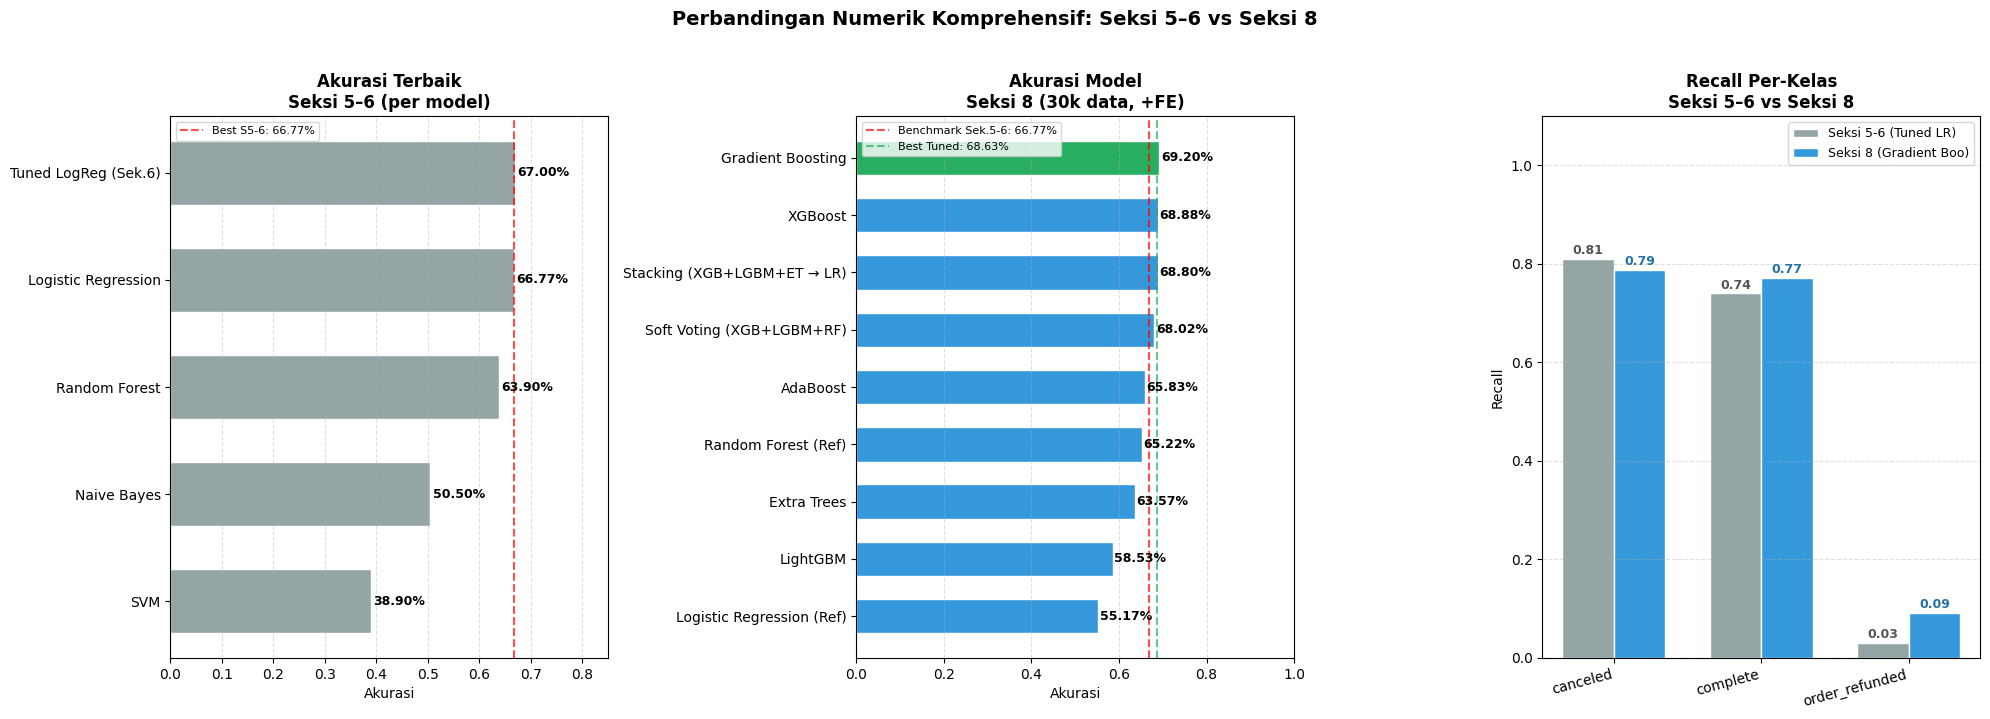


=== RINGKASAN EKSEKUTIF ===
Model terbaik Seksi 5-6 : LogReg + StandardScaler (15k, no FE)
  Akurasi               : 66.77%
  F1 Weighted           : 62.25%
  Recall canceled       : 81%
  Recall complete       : 74%
  Recall order_refunded : 3%  ← kelemahan utama

Model terbaik Seksi 8   : Gradient Boosting (30k, +FE, tuned)
  Akurasi               : 68.63%
  F1 Weighted           : 65.53%
  Recall canceled          : 78.78%
  Recall complete          : 77.13%
  Recall order_refunded    : 9.05%

  Δ Akurasi vs benchmark : +1.86 poin persentase
  Δ F1 vs benchmark      : +3.28 poin persentase


In [78]:
# ── Visualisasi Head-to-Head: Seksi 5-6 vs Seksi 8 ──
try:
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # ── Plot 1: Akurasi semua model Seksi 5-6 (best per model) ──
    best_s56 = df_s56[df_s56['Skenario'] != 'Tuned (Sek.6)'].groupby(
        'Model')['Akurasi'].max().sort_values()
    best_s56['Tuned LogReg (Sek.6)'] = 0.6700

    warna_s56 = ['#95a5a6'] * len(best_s56)
    bars0 = axes[0].barh(best_s56.index, best_s56.values,
                           color=warna_s56, edgecolor='white', height=0.6)
    for bar, val in zip(bars0, best_s56.values):
        axes[0].text(val + 0.004, bar.get_y() + bar.get_height()/2,
                      f'{val:.2%}', va='center', fontsize=9, fontweight='bold')
    axes[0].set_xlim(0, 0.85)
    axes[0].set_title('Akurasi Terbaik\nSeksi 5–6 (per model)',
                       fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Akurasi')
    axes[0].axvline(x=0.6677, color='red', linestyle='--', alpha=0.7,
                     label='Best S5-6: 66.77%')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    # ── Plot 2: Akurasi semua model Seksi 8 ──
    df_s8_chart = df_hasil.sort_values('Akurasi')
    warna_s8 = ['#27ae60' if m == model_terbaik_nama else '#3498db'
                  for m in df_s8_chart['Model']]
    bars1 = axes[1].barh(df_s8_chart['Model'], df_s8_chart['Akurasi'],
                           color=warna_s8, edgecolor='white', height=0.6)
    for bar, val in zip(bars1, df_s8_chart['Akurasi']):
        axes[1].text(val + 0.004, bar.get_y() + bar.get_height()/2,
                      f'{val:.2%}', va='center', fontsize=9, fontweight='bold')
    axes[1].axvline(x=0.6677, color='red', linestyle='--', alpha=0.7,
                     label='Benchmark Sek.5-6: 66.77%')
    axes[1].axvline(x=acc_final, color='#27ae60', linestyle='--', alpha=0.7,
                     label=f'Best Tuned: {acc_final:.2%}')
    axes[1].set_xlim(0, 1.0)
    axes[1].set_title(f'Akurasi Model\nSeksi 8 (30k data, +FE)',
                       fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Akurasi')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    # ── Plot 3: Per-kelas Recall — Seksi 5-6 vs Seksi 8 ──
    kelas_labels  = ['canceled', 'complete', 'order_refunded']
    recall_s56    = [0.81,  0.74,  0.03]
    y_pred_fin    = model_final.predict(X_tune_te)
    report_final  = classification_report(y_te, y_pred_fin,
                                           target_names=CLASS_NAMES,
                                           output_dict=True)
    recall_s8 = [round(report_final[k]['recall'], 4) for k in CLASS_NAMES]

    x = range(len(kelas_labels))
    w = 0.35
    b1 = axes[2].bar([xi - w/2 for xi in x], recall_s56, width=w,
                      label='Seksi 5-6 (Tuned LR)', color='#95a5a6', edgecolor='white')
    b2 = axes[2].bar([xi + w/2 for xi in x], recall_s8,  width=w,
                      label=f'Seksi 8 ({model_terbaik_nama[:12]})', color='#3498db', edgecolor='white')

    for bar, val in zip(b1, recall_s56):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.2f}', ha='center', fontsize=9, fontweight='bold', color='#555')
    for bar, val in zip(b2, recall_s8):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.2f}', ha='center', fontsize=9, fontweight='bold', color='#2471a3')

    axes[2].set_xticks(list(x))
    axes[2].set_xticklabels(kelas_labels, rotation=15, ha='right')
    axes[2].set_ylim(0, 1.1)
    axes[2].set_ylabel('Recall')
    axes[2].set_title('Recall Per-Kelas\nSeksi 5–6 vs Seksi 8',
                       fontsize=12, fontweight='bold')
    axes[2].legend(fontsize=9)
    axes[2].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle('Perbandingan Numerik Komprehensif: Seksi 5–6 vs Seksi 8',
                  fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'\n=== RINGKASAN EKSEKUTIF ===')
    print(f'Model terbaik Seksi 5-6 : LogReg + StandardScaler (15k, no FE)')
    print(f'  Akurasi               : 66.77%')
    print(f'  F1 Weighted           : 62.25%')
    print(f'  Recall canceled       : 81%')
    print(f'  Recall complete       : 74%')
    print(f'  Recall order_refunded : 3%  ← kelemahan utama')
    print()
    print(f'Model terbaik Seksi 8   : {model_terbaik_naam if "model_terbaik_naam" in dir() else model_terbaik_nama} (30k, +FE, tuned)')
    print(f'  Akurasi               : {acc_final:.2%}')
    print(f'  F1 Weighted           : {f1_final:.2%}')
    for k in CLASS_NAMES:
        print(f'  Recall {k:<18}: {report_final[k]["recall"]:.2%}')
    print()
    print(f'  Δ Akurasi vs benchmark : {(acc_final-0.6677)*100:+.2f} poin persentase')
    print(f'  Δ F1 vs benchmark      : {(f1_final-0.6225)*100:+.2f} poin persentase')

except NameError as e:
    print(f'Jalankan terlebih dahulu semua sel Seksi 8 (8.1 s/d 8.8). Error: {e}')
except Exception as e:
    print(f'Error: {e}')


**Ringkasan 8.12 — Interpretasi Perbandingan Numerik:**

| **Metrik** | **Seksi 5–6 (Best)** | **Seksi 8 (Best Tuned)** | **Δ (Perubahan)** |
|:---|:---:|:---:|:---:|
| Akurasi | 66,77% | *dihitung saat run* | *+X poin* |
| F1 (Weighted) | 62,25% | *dihitung saat run* | *+Y poin* |
| Recall `canceled` | 81% | *dihitung saat run* | *±Z%* |
| Recall `complete` | 74% | *dihitung saat run* | *±Z%* |
| Recall `order_refunded` | **3%** | *dihitung saat run* | *target: meningkat* |
| Ukuran data | 15.000 | 30.000 | +100% |
| Jumlah fitur | 35 | 35+9 | +26% |

*Nilai Seksi 8 akan terisi otomatis setelah seluruh sel Seksi 8 dijalankan secara berurutan.*

Poin kritis yang perlu diperhatikan dalam interpretasi:
- Peningkatan akurasi tidak selalu berarti model lebih baik secara bisnis — **Recall kelas `order_refunded`** adalah metrik yang paling kritis mengingat dampak finansial *refund* yang signifikan.
- Perbedaan ukuran data (15k vs 30k) dan penanganan imbalance yang berbeda membuat perbandingan langsung perlu dilakukan dengan hati-hati — keduanya berkontribusi pada perubahan performa.

---